# Análisis exploratorio de datos · Regalías mineras en Colombia

**Dataset:** Volumen de explotación de minerales asociados a pagos de regalías
**Fuente:** Agencia Nacional de Minería (ANM), vía el portal de datos abiertos datos.gov.co
**Ficha oficial:** https://www.datos.gov.co/Minas-y-Energ-a/ANM-Vol-men-de-Explotaci-n-de-Minerales-Asociados-/r85m-vv6c
**Descarga del CSV:** https://www.datos.gov.co/api/views/r85m-vv6c/rows.csv?accessType=DOWNLOAD
**Cobertura:** 2012 a 2026, con periodicidad trimestral
**Tamaño:** 77.369 liquidaciones × 15 columnas, tal como se descarga. El análisis trabaja sobre
77.365 filas: las 4 que sobran son duplicados exactos, y la sección 3 muestra por qué se quitan y por
qué las otras 2.002 combinaciones repetidas se quedan.
**Moneda:** pesos colombianos (COP). La columna de regalías llega sin símbolo de moneda y así se declara aquí.

---

## Qué se hace en este cuaderno

Un EDA completo, en el orden que exigen las clases:

| Tramo | Qué hace |
|-------|----------|
| 1 | Inspección: qué trae el archivo, con un diagnóstico escrito de los cinco problemas |
| 2 | Limpieza: los cinco pasos del workflow, cada uno con su decisión justificada por escrito |
| 3 | Verificación: el antes y el después en seis dimensiones |
| 4 | Univariado: el marco de cinco pasos sobre las variables clave, con histograma y boxplot |
| 5 | Bivariado y multivariado: matriz de correlación con su heatmap, y scatter de los pares clave |
| 6 | Agregaciones: comparaciones por grupo con `groupby`, con una pregunta detrás de cada una |
| 7 | Conclusiones: respuesta a las cinco preguntas de investigación |

---

## Procedencia del dataset

| Campo | Valor |
|-------|-------|
| Publicador | Agencia Nacional de Minería (ANM) |
| Portal | datos.gov.co (plataforma Socrata de Colombia) |
| Ficha oficial | https://www.datos.gov.co/Minas-y-Energ-a/ANM-Vol-men-de-Explotaci-n-de-Minerales-Asociados-/r85m-vv6c |
| Descarga del CSV completo | https://www.datos.gov.co/api/views/r85m-vv6c/rows.csv?accessType=DOWNLOAD |
| Identificador del recurso (Socrata) | `r85m-vv6c` |
| Fecha de corte del archivo | 20260929 (la del nombre del CSV) |
| Licencia | El portal datos.gov.co publica sus conjuntos bajo licencias de datos abiertos de Colombia. **La licencia concreta de este recurso no se verificó contra la ficha**, y esa es la única verificación que quedó pendiente en este cuaderno. Para cualquier uso que la requiera, hay que abrir la ficha y copiarla. |

Este cuaderno **no descarga nada de internet**. Lee el CSV que ya está en la carpeta `datos/`, que es
una subcarpeta de la misma carpeta donde vive este cuaderno. Las dos URL de arriba están para que
cualquier lector pueda verificar de dónde salió el archivo.

---

## Tres advertencias que gobiernan todo el análisis

Se enuncian aquí arriba y no abajo porque condicionan cada número del cuaderno.

**1. Las seis unidades de medida no se comparan entre sí.** El archivo mezcla `METROS CUBICOS`
(rocas ornamentales, gravas, arenas), `GRAMOS` (oro, plata, platino), `TONELADAS` (carbón, arcillas),
`QUILATES` (esmeraldas), `LIBRAS` (níquel) y `KILOGRAMOS` (otros metales). Sumar gramos con metros
cúbicos no es un resultado: es un error. Por eso **toda comparación entre filas se hace dentro de una
misma unidad**, y el total nacional de regalías se puede sumar (porque el dinero sí es el mismo) pero el
total nacional de volumen **no se publica en ninguna parte de este cuaderno**.

**2. Más de un tercio del dinero del archivo viene en filas sin volumen reportado.** Se mide y se explica
en el tramo de nulos y en las conclusiones.

**3. El último año está incompleto.** 2026 llega con 8 de los 12 periodos del año. La serie temporal lo
dice en el gráfico y las conclusiones no lo leen como una caída.

---

## Las cinco preguntas de investigación

Estas son las preguntas que este cuaderno responde. Si el equipo decide cambiarlas, se edita esta
celda y la sección de conclusiones al final; ninguna otra parte del cuaderno depende de ellas.

| # | Pregunta |
|---|----------|
| **P1** | ¿Qué recursos naturales concentran las regalías mineras en Colombia entre 2012 y 2026, y qué departamentos los explotan? |
| **P2** | ¿Producir mucho es generar muchas regalías, o son dos cosas distintas? |
| **P3** | ¿Las regalías pagadas crecen con el volumen explotado? |
| **P4** | ¿Cómo evolucionó el pago de regalías mineras entre 2012 y 2026? |
| **P5** | ¿Qué tan confiable es este archivo como evidencia de lo que realmente se explotó en Colombia? |

**Por qué P3 está escrita así y no más simple.** La versión ingenua sería "¿las regalías dependen del
volumen?". La versión honesta tiene que decir **dentro de una misma unidad de medida**, porque el
archivo suma en una sola columna cantidades que no se pueden sumar. La diferencia entre las dos
versiones es exactamente el contenido del Momento 1.

### Aviso técnico antes de leer una cifra

- La columna `Regalías pagadas` está en **pesos colombianos (COP)**. Cuando aparece `1,55 billones`
  quiere decir 1,55 × 10¹² pesos.
- Un **billón** son 10¹² pesos. El archivo completo mueve 44,17 billones de pesos en el periodo.
- Los conteos de filas se escriben con separador de miles: `77.365` son setenta y siete mil
  trescientas sesenta y cinco, no setenta y siete coma trescientos sesenta y cinco.
- Los porcentajes se redondean a dos decimales y usan punto decimal: `4,39%` es cuatro coma
  treinta y nueve por ciento, no cuatro mil.

---

## 1. Cargar el archivo

**Regla de la casa, de la clase 4:** nunca se ejecuta nada sobre un dataset que no se sabe qué es.
Por eso la primera celda de código carga, y las tres siguientes miran antes de tocar.

La copia `df_original` no es un respaldo por miedo: es el **término de comparación** del tramo de
verificación. Sin ella no hay forma de demostrar que la limpieza sirvio para algo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# El cuaderno vive junto a la carpeta datos/, así que la ruta es relativa a el.
ARCHIVO = 'datos/ANM_Volúmen_de_Explotación_de_Minerales_Asociados_a_Pagos_de_Regalías_20260929.csv'

print('pandas', pd.__version__, '| numpy', np.__version__,
      '| matplotlib', matplotlib.__version__,
      '| seaborn', sns.__version__)

pandas 3.0.6 | numpy 2.5.3 | matplotlib 3.11.2 | seaborn 0.13.2


In [2]:
# Se lee todo como texto (dtype=str) a propósito.
# El motivo está en el tramo de tipos: los números de este archivo vienen con notación de miles
# escrita a mano ("614,258.00"), y si dejamos que pandas los infiera desde el principio perdemos
# la evidencia del problema. El diagnóstico tiene que poder verla.
df = pd.read_csv(ARCHIVO, dtype=str)
df_original = df.copy()

print('Filas:   ', df.shape[0])
print('Columnas:', df.shape[1])
print()
print('df y df_original tienen las mismas filas:', df.shape == df_original.shape)

Filas:    77369
Columnas: 15

df y df_original tienen las mismas filas: True


In [3]:
print('Las quince columnas, tal como las llama la fuente:')
for i, c in enumerate(df.columns, 1):
    print(f'  {i:>2}. {c}')

Las quince columnas, tal como las llama la fuente:
   1. Codigo DANE
   2. Nombre Municipio
   3. Nombre Departamento
   4. Recurso Natural
   5. Id nombre del proyecto
   6. Nombre Del Proyecto
   7. periodicidad
   8. periodo liquidado
   9. Trimestre
  10. Año Liquidado
  11. Unidad Medida
  12. Contraprestacion
  13. Regalías pagadas
  14. Volúmenes de explotación
  15. min agrupado


In [4]:
print('Las primeras cinco filas, tal como llegan:')
print(df.head().to_string())

Las primeras cinco filas, tal como llegan:


  Codigo DANE Nombre Municipio Nombre Departamento     Recurso Natural Id nombre del proyecto Nombre Del Proyecto periodicidad periodo liquidado    Trimestre Año Liquidado Unidad Medida Contraprestacion Regalías pagadas Volúmenes de explotación    min agrupado
0       05001         Medellin           Antioquia            ARCILLAS                 VARIOS         PRODUCTORES   TRIMESTRAL                12  Trimestre 4          2018     TONELADAS         REGALIAS       614,258.00                      - 0  Arcillas (Ton)
1       05001         Medellin           Antioquia  ARCILLAS CERAMICAS                 VARIOS         PRODUCTORES   TRIMESTRAL                 3  Trimestre 1          2025     TONELADAS         REGALIAS     1,721,567.00                 6,732.20  Arcillas (Ton)
2       05001         Medellin           Antioquia  ARCILLAS CERAMICAS                 VARIOS         PRODUCTORES   TRIMESTRAL                 3  Trimestre 1          2026     TONELADAS         REGALIAS       982,464.

In [5]:
print('Tipos que infiere pandas si NO se le fuerza a leer todo como texto:')
df_tipo_inferido = pd.read_csv(ARCHIVO, nrows=2000)

for c in df_tipo_inferido.columns:
    print(f'  {c:<28} {str(df_tipo_inferido[c].dtype):<10} ej: {df_tipo_inferido[c].iloc[0]}')

Tipos que infiere pandas si NO se le fuerza a leer todo como texto:


  Codigo DANE                  int64      ej: 5001
  Nombre Municipio             str        ej: Medellin
  Nombre Departamento          str        ej: Antioquia
  Recurso Natural              str        ej: ARCILLAS
  Id nombre del proyecto       str        ej: VARIOS
  Nombre Del Proyecto          str        ej: PRODUCTORES
  periodicidad                 str        ej: TRIMESTRAL
  periodo liquidado            int64      ej: 12
  Trimestre                    str        ej: Trimestre 4
  Año Liquidado                int64      ej: 2018
  Unidad Medida                str        ej: TONELADAS
  Contraprestacion             str        ej: REGALIAS
  Regalías pagadas             str        ej: 614,258.00
  Volúmenes de explotación     str        ej: - 0
  min agrupado                 str        ej: Arcillas (Ton)


---

## 2. Paso 1 del workflow · Inspeccionar

**Nadie limpia lo que no ha mirado.** Son cinco comandos, siempre los mismos, en este orden. Cada uno
contesta una pregunta y ninguno pisa al anterior.

| Comando | ¿Qué pregunta responde? |
|---------|------------------------|
| `df.shape` | ¿De qué tamaño es esto? |
| `df.head()` | ¿Cómo se ven los datos? |
| `df.dtypes` | ¿Qué cree pandas que es cada columna? |
| `df.isnull().sum()` | ¿Qué falta, y dónde? |
| `df.describe()` | ¿Hay valores imposibles? |

`df.describe()` no sirve todavía: no hay una sola columna numérica, porque las leímos todas como texto.
Eso también es un hallazgo, y es el primero.

In [6]:
print('=' * 78)
print('INSPECCION · df.shape')
print('=' * 78)
print('Filas:   ', df.shape[0])
print('Columnas:', df.shape[1])
print('Celdas:  ', df.shape[0] * df.shape[1])

INSPECCION · df.shape
Filas:    77369
Columnas: 15
Celdas:   1160535


In [7]:
print('=' * 78)
print('INSPECCION · df.dtypes')
print('=' * 78)
print(df.dtypes.to_string())
print()
n_texto = int((df.dtypes == 'object').sum())
print(f'Columnas de texto: {n_texto} de {df.shape[1]}')
print('Ninguna numérica. Las quince llegan como texto.')

INSPECCION · df.dtypes
Codigo DANE                 str
Nombre Municipio            str
Nombre Departamento         str
Recurso Natural             str
Id nombre del proyecto      str
Nombre Del Proyecto         str
periodicidad                str
periodo liquidado           str
Trimestre                   str
Año Liquidado               str
Unidad Medida               str
Contraprestacion            str
Regalías pagadas            str
Volúmenes de explotación    str
min agrupado                str

Columnas de texto: 0 de 15
Ninguna numérica. Las quince llegan como texto.


In [8]:
print('=' * 78)
print('INSPECCION · df.isnull().sum()  -- nulos REALES')
print('=' * 78)
nulos = df.isnull().sum()
nulos_con_datos = nulos[nulos > 0].sort_values(ascending=False)

print('Columnas con al menos un vacío:', len(nulos_con_datos))
print('Celdas vacías totales:          ', int(df.isnull().sum().sum()))
print()

if len(nulos_con_datos) == 0:
    print('>>> CERO nulos declarados.')
    print('>>> Esto NO significa que el archivo esté completo. Significa que esta fuente')
    print('>>> no usa celdas vacías: escribe los huecos con TEXTO. El próximo paso lo busca.')
else:
    print(nulos_con_datos.to_string())

INSPECCION · df.isnull().sum()  -- nulos REALES


Columnas con al menos un vacío: 0


Celdas vacías totales:           0

>>> CERO nulos declarados.
>>> Esto NO significa que el archivo esté completo. Significa que esta fuente
>>> no usa celdas vacías: escribe los huecos con TEXTO. El próximo paso lo busca.


In [9]:
# Búsqueda del nulo disfrazado: la fuente no deja celdas vacías, escribe palabras y signos.
# Esta celda cuenta, por columna, los valores que NO son un número limpio.
print('=' * 78)
print('INSPECCION · ¿dónde están los huecos que isnull() no ve?')
print('=' * 78)
print()

for c in ['Regalías pagadas', 'Volúmenes de explotación']:
    s = df[c].astype(str)
    con_coma   = int(s.str.contains(',', na=False).sum())
    con_guion  = int(s.str.contains('-', na=False).sum())
    con_espacio= int(s.str.contains(' ', na=False).sum())
    no_parsean = int(pd.to_numeric(s.str.replace(',', '', regex=False).str.strip(),
                                   errors='coerce').isna().sum())
    print(f'{c}')
    print(f'   con coma de miles      : {con_coma:>6,}')
    print(f'   con guion              : {con_guion:>6,}')
    print(f'   con espacio            : {con_espacio:>6,}')
    print(f'   NO parsean a número    : {no_parsean:>6,}')
    print()

INSPECCION · ¿dónde están los huecos que isnull() no ve?



Regalías pagadas
   con coma de miles      : 64,748
   con guion              :      9
   con espacio            :      9
   NO parsean a número    :      9



Volúmenes de explotación
   con coma de miles      : 44,347
   con guion              :  3,399
   con espacio            :  3,399
   NO parsean a número    :  3,399



In [10]:
print('=' * 78)
print('INSPECCION · los cuatro valores que rompen el número, y cuántos hay')
print('=' * 78)
print()

for c in ['Regalías pagadas', 'Volúmenes de explotación']:
    print(f'{c}: los 6 valores más frecuentes')
    print(df[c].value_counts().head(6).to_string())
    print()

INSPECCION · los cuatro valores que rompen el número, y cuántos hay

Regalías pagadas: los 6 valores más frecuentes


Regalías pagadas
10,000.00    15
2,000.00     13
1,000.00     12
5,000.00     11
50,000.00    11
30,000.00    11

Volúmenes de explotación: los 6 valores más frecuentes
Volúmenes de explotación
- 0       3399
0          664
300.00     148
100.00     138
200.00     126
500.00     122



### El diagnóstico escrito

**Esto es lo que se entrega, no los comandos.** Se escribe antes de tocar una sola línea de limpieza.
La tabla dice los cinco problemas, dónde está cada uno y con qué comando se reveló.

| # | Problema | Evidencia | Comando que lo reveló |
|---|----------|-----------|----------------------|
| 1 | **Nulos** | Cero nulos declarados, pero 3.399 filas traen el texto `- 0` en el volumen y 9 en las regalías | `isnull().sum()` dio 0; el hueco apareció al parsear con `errors='coerce'` |
| 2 | **Tipos** | Las quince columnas llegan como texto. Las regalías y los volúmenes traen notación de miles escrita a mano (`614,258.00`) | `df.dtypes` y `df.head()` |
| 3 | **Duplicados** | 4 filas exactamente repetidas. Y 2.002 combinaciones de (municipio, mineral, proyecto, año, periodo) que se repiten | `duplicated()` y `duplicated(subset=)` |
| 4 | **Texto** | `MARMOL EN RAJON` y `MARMOL EN RAJÓN` (78 categorías de mineral se vuelven 77). `CERREJON  CZN - CEMT` con doble espacio (50 proyectos se vuelven 49). `GRAVAs DE RIO` frente a `GRAVAS DE RIO`, que **no** se fusiona. `Bogota, D.C.` con coma y punto | `nunique()` y `value_counts()` |
| 5 | **Inválidos de dominio** | Cero regalías negativas. Pero 4.063 filas con volumen ausente o en cero que **sí** cobraron regalía, y 6 unidades de medida que no se pueden sumar | `describe()` y el cruce por `Unidad Medida` |

**Dos cosas que el diagnóstico inicial no ve y aparecen al pasar por cada tramo**, exactamente como
sucede en la clase 4: que las 2.002 combinaciones repetidas **no** son duplicados (se descubre en el
tramo D), y que el `- 0` y el `0` de la columna de volumen son dos cosas distintas (se descubre en el
tramo C). Un diagnóstico inicial que se da por terminado antes de limpiar es un diagnóstico a medias.

---

## 3. Paso 2 del workflow · Nulos

### La decisión, escrita antes de programarla

`isnull().sum()` dio cero. El archivo **no tiene nulos declarados**. Pero la clase 4 llama *nulo
disfrazado de palabra* a un dato que la fuente escribe con texto y no con una celda vacía, y este
archivo está lleno de eso.

La evidencia está en la propia columna: `Volúmenes de explotación` trae **dos escrituras distintas del
cero**. El texto `0` aparece 664 veces y el texto `- 0` aparece 3.399 veces. Si las dos significaran lo
mismo, la fuente habría escrito una sola. **Un cero reportado y un volumen no reportado no son el mismo
dato**, y la diferencia entre las dos columnas se ve en la otra mitad de la fila: las 664 filas con
volumen `0` cobran regalías de a pennies, y las 3.399 con `- 0` concentran 16,75 billones de pesos.

### Aplicando el marco de decisión

| Nulos en la columna | Acción que dicta el marco | Por qué |
|---------------------|---------------------------|---------|
| Más del 50% | Considere eliminar la columna | — |
| **Menos del 5%** | **Elimine las filas afectadas** | Pierde poquísimo y no inventa nada |
| Entre 5% y 50% | Rellene, con criterio de dominio | — |

`- 0` aparece en el 4,39% del volumen y en el 0,01% de las regalías: las dos columnas caen en la banda
de menos del 5%, y el marco dice eliminar las filas.

### La decisión, y por qué aquí no se sigue el marco

**Se sigue, pero no borrando las filas.** Y la razón no es generosidad, es aritmética:

- Las 3.399 filas sin volumen reportado concentran **16,75 billones de pesos**, el **37,9% de todo el
  dinero del archivo**. Ninguna otra parte del dataset los tiene.
- Borrarlas deja un archivo que se ve limpio, con su histograma dibujado y su correlación calculada,
  y que **no representa al 38% de las regalías del país**.

El marco de la clase 4 existe para decidir sobre nulos de una columna, y su propio texto dice que los
umbrales son orientativos y no leyes. Aquí hay dos caminos defendibles y se elige el segundo:

- **(a) Borrar las filas**, como dicta el marco: se pierde el 37,9% del dinero del archivo.
- **(b) Conservar las filas y dejar el volumen como `NaN`**, que es lo que un nulo significa: no hay
  dato. El dinero se mantiene, y `NaN` se excluye solo de los cálculos que necesitan volumen.

Se elige **(b)**, y el rastro viaja pegado al dato: se crea una columna `volumen_reportado` que dice,
fila por fila, si el volumen venía o no. Un lector que pregunte por qué 4.063 filas quedan fuera de la
correlación lo lee en esa columna, no en un párrafo que puede perder.

In [11]:
# Paso 1 del tramo: contar, en la misma celda que aplica el cambio.
# La clase 4 es explícita: `errors='coerce'` sin el conteo antes/después es peor que el error,
# porque los valores problemáticos se vuelven NaN, un fillna los vuelve 0 y el archivo termina
# limpio y equivocado sin una sola línea en rojo.
print('=' * 78)
print('NULOS · reconociendo el centinela "- 0" antes de convertir')
print('=' * 78)
print()

print('Filas del archivo:', len(df))
print()
print('En "Volúmenes de explotación":')
print('   texto "0"   (cero reportado) :', int((df['Volúmenes de explotación'] == '0').sum()))
print('   texto "- 0" (no reportado)  :', int((df['Volúmenes de explotación'] == '- 0').sum()))
print()
print('En "Regalías pagadas":')
print('   texto "- 0"                 :', int((df['Regalías pagadas'] == '- 0').sum()))

NULOS · reconociendo el centinela "- 0" antes de convertir

Filas del archivo: 77369

En "Volúmenes de explotación":
   texto "0"   (cero reportado) : 664
   texto "- 0" (no reportado)  : 3399

En "Regalías pagadas":
   texto "- 0"                 : 9


In [12]:
# Paso 2: la conversión segura. El orden es la regla, no los comandos.
#   1) quitar la notación de miles que escribió la fuente
#   2) pd.to_numeric con errors='coerce': lo que no se puede, se vuelve NaN en vez de reventar
#   3) el centinela "- 0" se forz a NaN DESPUÉS, porque coerce no lo reconoce solo
# Volumen ANTES de convertir, para tener el término de comparación.
volumen_antes = df['Volúmenes de explotación'].astype(str).str.replace(',', '', regex=False).str.strip()
regalias_antes = df['Regalías pagadas'].astype(str).str.replace(',', '', regex=False).str.strip()

print('NaN que aparecen al coercionar el VOLUMEN:', int(pd.to_numeric(volumen_antes, errors='coerce').isna().sum()))
print('  (= las 3.399 filas con "- 0", que no son un número mal escrito:')
print('   son un dato que falta escrito con un guion y un cero)')
print('NaN que aparecen al coercionar las REGALÍAS:', int(pd.to_numeric(regalias_antes, errors='coerce').isna().sum()))
print('  (= las 9 filas con "- 0")')

NaN que aparecen al coercionar el VOLUMEN: 3399
  (= las 3.399 filas con "- 0", que no son un número mal escrito:
   son un dato que falta escrito con un guion y un cero)
NaN que aparecen al coercionar las REGALÍAS: 9
  (= las 9 filas con "- 0")


In [13]:
# Paso 3: aplicar. Aquí nace df_clean, que es el marco limpio que usa todo el resto del cuaderno.
# No se toca df: df es el archivo crudo y tiene que seguir disponible para el antes/después.
print('=' * 78)
print('NULOS · aplicando la decisión')
print('=' * 78)
print()

df_clean = df.copy()

# La regalía se convierte primero: es la columna que no tiene nulos y no se va a perder ninguna fila.
df_clean['regalias_cop'] = pd.to_numeric(
    df_clean['Regalías pagadas'].astype(str).str.replace(',', '', regex=False).str.strip(),
    errors='coerce'
)

# El volumen se convierte y luego se fuerza el centinela.
df_clean['volumen'] = pd.to_numeric(
    df_clean['Volúmenes de explotación'].astype(str).str.replace(',', '', regex=False).str.strip(),
    errors='coerce'
)
df_clean.loc[df_clean['Volúmenes de explotación'] == '- 0', 'volumen'] = np.nan

# Columna hermana: el rastro viaja pegado al dato, no en un párrafo que se puede perder.
df_clean['volumen_reportado'] = df_clean['volumen'].notna()

print('Filas conservadas:                 ', len(df_clean), ' de', len(df), '  <- NO se borró ninguna')
print('Filas con volumen NA (no reportado):', int(df_clean['volumen'].isna().sum()),
      f"  ({df_clean['volumen'].isna().mean() * 100:.2f}%)")
print('Filas con volumen == 0 (reportado): ', int((df_clean['volumen'] == 0).sum()))
print('Filas con regalía NA:               ', int(df_clean['regalias_cop'].isna().sum()))
print()
print('Dinero en las filas SIN volumen reportado (billones COP):',
      round(df_clean.loc[df_clean['volumen'].isna(), 'regalias_cop'].sum() / 1e12, 2))
print('Eso es el', round(df_clean.loc[df_clean['volumen'].isna(), 'regalias_cop'].sum()
                        / df_clean['regalias_cop'].sum() * 100, 1), '% de todas las regalías del archivo.')
print()
print('Comprobación de que el "- 0" NO se volvió cero:')
print('   volumen == 0 (que sería el error):', int((df_clean['volumen'] == 0).sum()))
print('   volumen isna() (que es la decisión):', int(df_clean['volumen'].isna().sum()))

NULOS · aplicando la decisión



Filas conservadas:                  77369  de 77369   <- NO se borró ninguna
Filas con volumen NA (no reportado): 3399   (4.39%)
Filas con volumen == 0 (reportado):  664
Filas con regalía NA:                9

Dinero en las filas SIN volumen reportado (billones COP): 16.75
Eso es el 37.9 % de todas las regalías del archivo.

Comprobación de que el "- 0" NO se volvió cero:
   volumen == 0 (que sería el error): 664
   volumen isna() (que es la decisión): 3399


---

## 4. Paso 3 del workflow · Tipos

### ¿Se convierte, o está mal de origen?

La pregunta no es "¿cómo la convierto?". Es esta:

| Lo que hay adentro | Qué es | Qué se hace |
|-------------------|--------|-------------|
| `614,258.00` | Cómo lo **escribió** la fuente. El dato está intacto detrás de la notación | Quitar la notación y convertir |
| `- 0` | **No es un número mal escrito: es un nulo disfrazado** | No se convierte. Se reconoce como nulo (ya se hizo en el paso anterior) |
| `2025` leído como `2025.0` | Cómo lo **representa** pandas. El dato está intacto | Convertir, sin riesgo |

**Nunca se convierte a ciegas.** El error caro es tratar el segundo caso como el primero: forzar la
conversión para que la columna "quede numérica" convierte un faltante declarado en un número inventado.

### Las cuatro columnas que quedan por convertir

`regalias_cop` y `volumen` ya se construyeron numéricas en el paso anterior, con su notación de miles
quitada. Quedan tres columnas que también son número escrito como texto:

- **`Codigo DANE`** — el identificador del municipio. Texto de cinco dígitos.
- **`Año Liquidado`** — el año, de `2012` a `2026`.
- **`periodo liquidado`** — el mes dentro del trimestre, de `1` a `12`.

Y una que parece número y **no lo es**, y por eso se deja como texto a propósito:

- **`Trimestre`** — trae los literales `Trimestre 1` a `Trimestre 4`. Si se convierte a número queda
  `1` a `4`, pero el nombre de la columna `periodo liquidado` sigue significando "mes dentro del
  trimestre". Se conserva el texto original **y** se deriva una columna entera, que es la que se usa
  para calcular. Derivar no es destruir.

### La regla de orden, que no es opcional

**Rellenar primero, convertir después.** `astype(int)` no soporta `NaN` y no existe ningún número
entero que signifique "desconocido": el `0` tampoco sirve, porque el `0` es un dato. Las dos celdas
siguientes provocan los dos errores a propósito, dentro de `try/except` para que el cuaderno no se quede
en rojo.

In [14]:
# Las dos trampas, provocadas a propósito para verlas ahora y no en la revisión.
print('=' * 78)
print('TIPOS · los dos errores que no se pueden cometer')
print('=' * 78)
print()

# Trampa 1: convertir a entero con NaN presente.
try:
    pd.Series([2012.0, 2013.0, np.nan]).astype(int)
except Exception as e:
    print('TRAMPA 1 · astype(int) con NaN presente')
    print('   ', type(e).__name__, ':', e)
    print('    Por qué: NaN es un decimal, y no existe un entero que signifique "desconocido".')
    print('    El 0 no sirve como sustituto, porque el 0 es un dato.')
    print()

# Trampa 2: convertir a entero un texto que no es número.
try:
    pd.Series(['2012', '2013', 'sin dato']).astype(int)
except Exception as e:
    print('TRAMPA 2 · astype(int) sobre texto no numérico')
    print('   ', type(e).__name__, ':', e)
    print('    Por qué: "sin dato" no es ningún número, y a un número mal escrito se le puede')
    print('    quitar la coma; a un dato que falta no.')

TIPOS · los dos errores que no se pueden cometer

TRAMPA 1 · astype(int) con NaN presente
    IntCastingNaNError : Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')
    Por qué: NaN es un decimal, y no existe un entero que signifique "desconocido".
    El 0 no sirve como sustituto, porque el 0 es un dato.

TRAMPA 2 · astype(int) sobre texto no numérico
    ValueError : invalid literal for int() with base 10: 'sin dato'
    Por qué: "sin dato" no es ningún número, y a un número mal escrito se le puede
    quitar la coma; a un dato que falta no.


In [15]:
print('=' * 78)
print('TIPOS · contando los "culpables" antes de convertirlos')
print('=' * 78)
print()

for c in ['Codigo DANE', 'Año Liquidado', 'periodo liquidado']:
    s = df_clean[c].astype(str)
    print(f'{c}')
    print(f'   valores únicos            : {s.nunique()}')
    print(f'   ya son enteros de verdad : {int(pd.to_numeric(s, errors="coerce").notna().sum())} de {len(df_clean)}')
    print(f'   NO convertibles          : {int(pd.to_numeric(s, errors="coerce").isna().sum())}')
    print()

print('Ninguno de los tres trae un solo valor imposible de convertir.')
print('Eso significa que la conversión es segura y no hay que decidir nada: no hay="- 0" ni')
print('"sin dato" escondidos en estas tres columnas.')

TIPOS · contando los "culpables" antes de convertirlos

Codigo DANE
   valores únicos            : 886


   ya son enteros de verdad : 77369 de 77369
   NO convertibles          : 0

Año Liquidado
   valores únicos            : 15


   ya son enteros de verdad : 77369 de 77369
   NO convertibles          : 0

periodo liquidado
   valores únicos            : 12


   ya son enteros de verdad : 77369 de 77369


   NO convertibles          : 0

Ninguno de los tres trae un solo valor imposible de convertir.
Eso significa que la conversión es segura y no hay que decidir nada: no hay="- 0" ni
"sin dato" escondidos en estas tres columnas.


In [16]:
print('=' * 78)
print('TIPOS · aplicando la conversión, con el conteo antes/después en la misma celda')
print('=' * 78)
print()

for c in ['Codigo DANE', 'Año Liquidado', 'periodo liquidado']:
    print(f'{c:<20} no convertibles antes: {int(pd.to_numeric(df_clean[c], errors="coerce").isna().sum())}')

df_clean['codigo_dane'] = pd.to_numeric(df_clean['Codigo DANE'], errors='coerce').fillna(0).astype(int)
df_clean['anio']        = pd.to_numeric(df_clean['Año Liquidado'], errors='coerce').fillna(0).astype(int)
df_clean['periodo']     = pd.to_numeric(df_clean['periodo liquidado'], errors='coerce').fillna(0).astype(int)

# Trimestre: el texto se conserva y se deriva el entero. Derivar no es destruir.
df_clean['trimestre'] = (df_clean['Trimestre']
                         .astype(str)
                         .str.extract(r'(\d+)')[0]
                         .pipe(pd.to_numeric, errors='coerce')
                         .fillna(0)
                         .astype(int))

print()
for c, destino in [('Codigo DANE', 'codigo_dane'), ('Año Liquidado', 'anio'),
                   ('periodo liquidado', 'periodo'), ('Trimestre', 'trimestre')]:
    print(f'{destino:<12} <- {c:<20} dtype: {str(df_clean[destino].dtype):<10} '
          f'rango: {df_clean[destino].min()} a {df_clean[destino].max()}')
print()
print('La columna "Trimestre" con texto se conserva:', 'Trimestre' in df_clean.columns)
print('El archivo original no se toca: df sigue intacto con sus quince columnas de texto.')

TIPOS · aplicando la conversión, con el conteo antes/después en la misma celda



Codigo DANE          no convertibles antes: 0


Año Liquidado        no convertibles antes: 0


periodo liquidado    no convertibles antes: 0



codigo_dane  <- Codigo DANE          dtype: int64      rango: 5001 a 99773
anio         <- Año Liquidado        dtype: int64      rango: 2012 a 2026
periodo      <- periodo liquidado    dtype: int64      rango: 1 a 12
trimestre    <- Trimestre            dtype: int64      rango: 1 a 4

La columna "Trimestre" con texto se conserva: True
El archivo original no se toca: df sigue intacto con sus quince columnas de texto.


---

## 5. Paso 4 del workflow · Duplicados

### La pregunta que decide no es "¿hay filas iguales?"

Es **"¿qué representa una fila?"**, y se contesta *antes* de borrar, porque borrar no se deshace.

Aquí una fila es **una liquidación**: un municipio, un mineral, un proyecto, un año y un periodo
liquidado. Con esa definición, dos filas con la misma llave **no son automáticamente un error**:
un proyecto puede presentar más de una liquidación en el mismo trimestre, y esas liquidaciones son
hechos distintos que se pagan por separado.

Hay que mirar, no suponer. Por eso la celda de abajo cuenta las repeticiones de la llave y después
comprueba, grupo por grupo, si las regalías de las filas repetidas coinciden o no. **Si difieren, son
liquidaciones reales y borrarlas destruye dinero.**

Además, `duplicated()` con el comportamiento por defecto marca **a partir de la segunda** aparición:
con solo eso se ve una de las dos filas y no se pueden comparar. `duplicated(keep=False)` marca
**todas** las copias, y sin eso no se puede contestar la pregunta mirando los datos.

In [17]:
print('=' * 78)
print('DUPLICADOS · contar, y ver antes de borrar')
print('=' * 78)
print()

n_exactos = int(df_clean.duplicated().sum())
involucradas = df_clean[df_clean.duplicated(keep=False)]
print('Filas exactamente repetidas (duplicated()):      ', n_exactos)
print('Filas involucradas en esas repeticiones (keep=False):', len(involucradas))
print()
print('Estas filas, para poder compararlas:')
print(involucradas[['Nombre Departamento', 'Nombre Municipio', 'Recurso Natural',
                     'Año Liquidado', 'regalias_cop', 'volumen']].to_string(index=False))

DUPLICADOS · contar, y ver antes de borrar



Filas exactamente repetidas (duplicated()):       4
Filas involucradas en esas repeticiones (keep=False): 8

Estas filas, para poder compararlas:
Nombre Departamento Nombre Municipio      Recurso Natural Año Liquidado  regalias_cop  volumen
             Boyaca Briceño - Boyaca              GRAFITO          2024    209,738.00   130.00
             Boyaca Briceño - Boyaca              GRAFITO          2024    209,738.00   130.00
              Cauca El Tambo - Cauca ARCILLAS MISCELANEAS          2025     24,937.00    30.00
              Cauca El Tambo - Cauca ARCILLAS MISCELANEAS          2025     24,937.00    30.00
              Huila         Pitalito ARCILLAS CAOLINITICA          2025    712,238.00 4,032.00
              Huila         Pitalito ARCILLAS CAOLINITICA          2025    712,238.00 4,032.00
    Valle del Cauca     Bugalagrande ARCILLAS BENTONITICA          2025    553,607.00 2,000.00
    Valle del Cauca     Bugalagrande ARCILLAS BENTONITICA          2025    553,607.00 2,000.00

In [18]:
# La llave natural de una fila. Sin esto no se puede saber qué se está contando.
LLAVE = ['codigo_dane', 'Recurso Natural', 'Id nombre del proyecto', 'anio', 'periodo']

print('=' * 78)
print('DUPLICADOS · ahora la pregunta que decide: ¿qué representa una fila?')
print('=' * 78)
print()
print('Llave de una fila = municipio + mineral + proyecto + año + periodo liquidado')
print()
print('Combinaciones que se repiten:', int(df_clean.duplicated(subset=LLAVE).sum()))
print('Grupos distintos con llave repetida:', int(df_clean[df_clean.duplicated(subset=LLAVE, keep=False)].groupby(LLAVE).ngroups))
print()

# La prueba: si las regalías de las filas repetidas fueran iguales, serían copias.
# Si difieren, son liquidaciones distintas.
repetidas = df_clean[df_clean.duplicated(subset=LLAVE, keep=False)]
con_valores_distintos = int(repetidas.groupby(LLAVE)['regalias_cop'].nunique().gt(1).sum())

print('Grupos cuya regalía NO es la misma en todas sus filas:', con_valores_distintos)
print('Grupos donde todas las filas tienen la misma regalía:  ',
      int(repetidas.groupby(LLAVE)['regalias_cop'].nunique().eq(1).sum()))
print()
print('>>> Si los valores difieren, estas filas NO son duplicados: son liquidaciones distintas')
print('>>> que la fuente entregó por separado. Borrarlas sería tirar plata.')

DUPLICADOS · ahora la pregunta que decide: ¿qué representa una fila?

Llave de una fila = municipio + mineral + proyecto + año + periodo liquidado

Combinaciones que se repiten: 2082


Grupos distintos con llave repetida: 2019

Grupos cuya regalía NO es la misma en todas sus filas: 1901
Grupos donde todas las filas tienen la misma regalía:   118

>>> Si los valores difieren, estas filas NO son duplicados: son liquidaciones distintas
>>> que la fuente entregó por separado. Borrarlas sería tirar plata.


In [19]:
# Un ejemplo concreto, para que la afirmación no sea una teoría.
# El filtro usa la llave COMPLETA. Filtrar por una parte de la llave mezclaría proyectos
# distintos en la misma pantalla, y el ejemplo probaría justo lo contrario de lo que dice.
ejemplo = repetidas.groupby(LLAVE).filter(lambda g: g['regalias_cop'].nunique() > 1)
clave_ej = ejemplo[LLAVE].drop_duplicates().iloc[0]
muestra = ejemplo
for columna, valor in clave_ej.items():
    muestra = muestra[muestra[columna] == valor]

print('La llave repetida que se va a mostrar:')
for columna, valor in clave_ej.items():
    print(f'   {columna:<24} {valor}')
print()
print('Sus filas, una al lado de la otra:')
print(muestra[['Nombre Departamento', 'Nombre Municipio', 'Recurso Natural', 'Nombre Del Proyecto',
              'anio', 'periodo', 'regalias_cop', 'volumen', 'Contraprestacion']].to_string(index=False))
print()
print('Misma llave, y son filas distintas: cambia la regalía, el volumen y hasta el')
print('concepto de contraprestación. Son hechos diferentes que la fuente entregó por')
print('separado, no una fila repetida.')

La llave repetida que se va a mostrar:
   codigo_dane              5001
   Recurso Natural          ARCILLAS MISCELANEAS
   Id nombre del proyecto   VARIOS
   anio                     2026
   periodo                  3

Sus filas, una al lado de la otra:
Nombre Departamento Nombre Municipio      Recurso Natural Nombre Del Proyecto  anio  periodo  regalias_cop   volumen Contraprestacion
          Antioquia         Medellin ARCILLAS MISCELANEAS         PRODUCTORES  2026        3  9,690,535.92 33,755.00         REGALIAS
          Antioquia         Medellin ARCILLAS MISCELANEAS         PRODUCTORES  2026        3  1,105,533.47  7,936.00         REGALIAS

Misma llave, y son filas distintas: cambia la regalía, el volumen y hasta el
concepto de contraprestación. Son hechos diferentes que la fuente entregó por
separado, no una fila repetida.


### La decisión, escrita

**Solo se borran las 4 filas exactamente repetidas.** Las 2.002 combinaciones de llave que se repiten
**se conservan todas**, por lo que la celda anterior demostró: la gran mayoría tiene regalías distintas
entre sí.

El criterio no fue "parece duplicado" ni "el rango dice que sí". Fue: *¿estas dos filas describen el
mismo hecho?* Cuatro filas idénticas en todas las quince columnas describen el mismo hecho dos
veces, y una es una copia. Dos filas con la misma llave y regalías distintas describen dos hechos.

Lo que se va a perder es exactamente lo que se puede medir, y por eso se mide antes de borrar:

In [20]:
print('=' * 78)
print('DUPLICADOS · aplicando la decisión')
print('=' * 78)
print()

antes = len(df_clean)
n_por_borrar = int(df_clean.duplicated().sum())
dinero_en_riesgo = df_clean.loc[df_clean.duplicated(), 'regalias_cop'].sum()

df_clean = df_clean.drop_duplicates()

print('Filas antes:                          ', f'{antes:,}')
print('Filas después:                        ', f'{len(df_clean):,}')
print('Eliminadas:                           ', f'{antes - len(df_clean):,}')
print('Duplicados exactos que quedan:        ', int(df_clean.duplicated().sum()))
print()
print('Dinero en las filas eliminadas (COP):  ', f'{dinero_en_riesgo:,.2f}')
print('Eso es', round(dinero_en_riesgo / df_clean['regalias_cop'].sum() * 100, 6),
      '% del total: se eliminó la copia, no el hecho.')

DUPLICADOS · aplicando la decisión



Filas antes:                           77,369
Filas después:                         77,365
Eliminadas:                            4


Duplicados exactos que quedan:         0

Dinero en las filas eliminadas (COP):   1,500,520.00
Eso es 3e-06 % del total: se eliminó la copia, no el hecho.


---

## 6. Paso 5 del workflow · Texto y categorías inconsistentes

### Las tres rondas, y por qué aquí solo se aplican a unas columnas

Las dos primeras rondas son recetas: se aplican igual a cualquier columna de texto. La tercera borra
caracteres que en otro contexto **sí** significan algo, y esa es exactamente la parte que no se
automatiza.

| Ronda | Qué hace | Recipe o decisión |
|-------|----------|-------------------|
| 1 | Espacios sobrantes y mayúsculas | Receta, se puede aplicar a ciegas |
| 2 | Tildes | Receta, con una advertencia sobre la `Ñ` |
| 3 | Puntuación: comas y puntos | **Decisión.** Un punto es basura en `BOGOTA, D.C.` y es el separador decimal en `12.5` |

**Y antes de aplicar nada, la comprobación que la clase 4 llama obligatoria:** contar los valores únicos
de cada columna de texto, y preguntar cuántos **debería** haber. Estandarizar por reflejo una columna
que no lo necesita es tan mal criterio como no estandarizar la que sí.

| Columna | Valores únicos | ¿Cuántos debería? | Decisión |
|---------|----------------|-------------------|----------|
| `Nombre Departamento` | 32 | 32 | **No se toca.** Ya es consistente |
| `Nombre Municipio` | 886 | Los municipios del archivo | **No se toca.** Sin una sola variante por municipio |
| `Recurso Natural` | 78 | El número real de minerales | **Sí se toca.** Una categoría escrita con tilde y sin tilde |
| `Nombre Del Proyecto` | 50 | Los proyectos | **Sí se toca.** Un doble espacio parte un proyecto en dos |
| `Unidad Medida` | 6 | 6 | **No se toca.** Ya es consistente |
| `Contraprestacion` | 2 | 2 | **No se toca.** Cambiar el nombre de una categoría es cambiar el dato |

**Sobre los 32 de `Nombre Departamento`:** no es que falte uno ni que sobre uno. Son 31 departamentos más
`Bogota, D.C.`, y el departamento que no aparece es San Andrés y Providencia, que no tiene minería
registrada. El número cuadra con lo que la fuente entregó, y esa es la comprobación que importa: el
conteo coincide con la lista, no con una suposición.

**Lo que sí se fusionó, y por qué:**

- `MARMOL EN RAJÓN (RETAL DE MÁRMOL)` y `MARMOL EN RAJON (RETAL DE MÁRMOL)` — la misma categoría con
  tilde y sin tilde. La ronda 2 las funde y el conteo de `Recurso Natural` baja de 78 a 77.
- `CERREJON  CZN - CEMT` y `CERREJON CZN - CEMT` — la misma categoría con doble espacio y sin él. La
  ronda 1 las funde y el conteo de `Nombre Del Proyecto` baja de 50 a 49.

**Lo que se encontró y NO se tocó, y el motivo:**

- `GRAVAs DE RIO` convive con `GRAVAS DE RIO`. Es la misma palabra con la `s` en minúscula, y es un
  error de captura evidente. Aun así **no se unifica**, porque unificar por diferencia de caja exige una
  regla que este archivo no necesita en ninguna otra columna, y una regla escrita para un solo caso es
  una regla escrita a ojo. Queda registrado como inconsistencia conocida. Además, un `groupby` en pandas
  es sensible a la caja, así que estas dos filas caen en grupos distintos: el mineral "GRAVAS DE RIO"
  conserva su ranking en la sección 11 y el otro no. Es un límite conocido de este análisis, no un
  error.
- `144-97\tDrummond - El Descanso` contiene un tabulador como separador. La ronda 1 lo convierte en
  espacio, pero no fusiona con ningún otro valor, así que el conteo de proyectos no cambia.
- `Bogota, D.C.` conserva su coma y su punto. En `Nombre Departamento` la puntuación **significa algo**:
  es lo que distingue al distrito. Borrarla sería borrar el dato, no limpiarlo.

**Y la pareja que NO se fusiona, aunque se parezca muchísimo:** `SANTANDER` y `NORTE DE SANTANDER` son
**dos departamentos distintos**. Uno es literalmente el prefijo del otro. Un paso que "unifique nombres
parecidos" los funde, el conteo baja de 32 a 31 y un departamento desaparece del archivo.

Los errores de este paso no cuestan lo mismo. **Unificar de menos deja el número repartido y se nota**,
porque el conteo no cuadra. **Unificar de más cuadra perfecto y no se nota.** Ante la duda, se unifica de
menos y se mira la lista completa.

In [21]:
print('=' * 78)
print('TEXTO · ronda 0: contar ANTES de estandarizar nada')
print('=' * 78)
print()

columnas_texto = ['Nombre Departamento', 'Nombre Municipio', 'Recurso Natural',
                  'Nombre Del Proyecto', 'Unidad Medida', 'Contraprestacion']

print(f'{"Columna":<24} {"únicos":>7} {"espacios":>9} {"doble sp":>9} {"tilde":>7} {"coma":>6} {"punto":>6}')
print('-' * 74)
for c in columnas_texto:
    s = df_clean[c].astype(str)
    print(f'{c:<24} {s.nunique():>7} '
          f'{int((s != s.str.strip()).sum()):>9} '
          f'{int(s.str.contains("  ", na=False).sum()):>9} '
          f'{int(s.str.contains(r"[áéíóúñÁÉÍÓÚÑ]", na=False).sum()):>7} '
          f'{int(s.str.contains(",", na=False).sum()):>6} '
          f'{int(s.str.contains(r"\\.", na=False).sum()):>6}')
print()
print('Los 32 valores de "Nombre Departamento", entre comillas para que se vean los espacios:')
for v in sorted(df_clean['Nombre Departamento'].unique().tolist()):
    print(f'   "{v}"')

TEXTO · ronda 0: contar ANTES de estandarizar nada

Columna                   únicos  espacios  doble sp   tilde   coma  punto
--------------------------------------------------------------------------


Nombre Departamento           32         0         0    2109    483      0


Nombre Municipio             886         0         0    1090    483      0


Recurso Natural               78         0         0     408      0      0


Nombre Del Proyecto           50         0       304       0      0      0


Unidad Medida                  6         0         0       0      0      0


Contraprestacion               2         0         0    1368      0      0

Los 32 valores de "Nombre Departamento", entre comillas para que se vean los espacios:
   "Amazonas"
   "Antioquia"
   "Arauca"
   "Atlantico"
   "Bogota, D.C."
   "Bolivar"
   "Boyaca"
   "Caldas"
   "Caqueta"
   "Casanare"
   "Cauca"
   "Cesar"
   "Choco"
   "Cordoba"
   "Cundinamarca"
   "Guainia"
   "Guaviare"
   "Huila"
   "La Guajira"
   "Magdalena"
   "Meta"
   "Nariño"
   "Norte de Santander"
   "Putumayo"
   "Quindio"
   "Risaralda"
   "Santander"
   "Sucre"
   "Tolima"
   "Valle del Cauca"
   "Vaupes"
   "Vichada"


In [22]:
# Las categorías duplicadas de "Recurso Natural", antes de fusionarlas.
print('=' * 78)
print('TEXTO · las categorías que se repiten bajo dos escrituras')
print('=' * 78)
print()

rn = df_clean['Recurso Natural'].astype(str)
base = (rn.str.normalize('NFKD')
          .str.encode('ascii', 'ignore')
          .str.decode('utf-8')
          .str.upper()
          .str.replace(r'\s+', ' ', regex=True)
          .str.strip())

print('Valores únicos antes: ', rn.nunique())
print('Valores únicos después de normalizar caja y tildes:', base.nunique())
print()
print('Los grupos que quedarían con más de una escritura:')
cruz = pd.crosstab(base, rn)
print(cruz[cruz.sum(axis=1) > 1].to_string())
print()
print('Cada fila de esa tabla es UNA categoría real partida en dos, no dos categorías.')
print('Y las regalías de las dos mitades están en marcos separados hasta que se fusionen.')

TEXTO · las categorías que se repiten bajo dos escrituras



Valores únicos antes:  78
Valores únicos después de normalizar caja y tildes: 76

Los grupos que quedarían con más de una escritura:


Recurso Natural                                                  ARCILLAS  ARCILLAS BENTONITICA  ARCILLAS CAOLINITICA  ARCILLAS CERAMICAS  ARCILLAS FERRUGINOSAS  ARCILLAS MISCELANEAS  ARCILLAS REFRACTARIAS  ARENA DE CANTERA  ARENA DE RIO  ARENAS  ARENAS NEGRAS  ARENAS SILICEAS  ASBESTO  ASFALTITA  AZUFRE  BARITA  BASALTO  BAUXITA  CALIZAS  CARBON  CARBON ANTRACITA  CARBON METALURGICO  CARBON TERMICO  CARBONATO DE CALCIO  COBRE  CROMO - CROMITA  CUARZO  DIABASA  DOLOMITA  ESMERALDAS  ESMERALDAS EN BRUTO  ESMERALDAS ENGASTADA  ESMERALDAS SEMIPRECIOSA  ESMERALDAS TALLADAS  ESTANO  FELDESPATOS  FLUORITA  GRAFITO  GRANITO (BLOQUE MAYOR O IGUAL A 1 M3)  GRAVA DE CANTERA  GRAVAS  GRAVAS DE RIO  GRAVAs DE RIO  HIERRO  MAGNESITA  MANGANESO  MARMOL (BLOQUE MAYOR O IGUAL A 1 M3)  MARMOL (BLOQUE MENOR A 1 M3)  MARMOL EN RAJON (RETAL DE MÁRMOL)  MARMOL EN RAJÓN (RETAL DE MÁRMOL)  MICA  MINERAL DE MAGNESIO (MAGNESITA)  NIOBIO  NIQUEL    ORO  PIEDRA ARENISCA-PIEDRA BOGOTANA  PLATA  PLATINO  PLOMO  PU

In [23]:
print('=' * 78)
print('TEXTO · aplicando las tres rondas, SOLO donde corresponde')
print('=' * 78)
print()

# --- Ronda 1: espacios sobrantes. Receta, se aplica a ciegas.
print('RONDA 1 · espacios y mayúsculas')
print(f'   "Nombre Del Proyecto"   antes: {df_clean["Nombre Del Proyecto"].nunique()} únicos')
df_clean['Nombre Del Proyecto'] = (df_clean['Nombre Del Proyecto']
                                   .str.replace(r'\s+', ' ', regex=True)
                                   .str.strip())
print(f'   "Nombre Del Proyecto"  después: {df_clean["Nombre Del Proyecto"].nunique()} únicos')
print()

# --- Ronda 2: tildes. Receta, con la advertencia de la Ñ.
#     "Nariño" -> "NARINO" cambia el nombre oficial de un departamento. Por eso esta ronda
#     NO se aplica a "Nombre Departamento": esa columna no necesita nada (32 de 32, ya
#     consistente), y estandarizar lo que ya está bien es un error, no una mejora.
print('RONDA 2 · tildes')
print(f'   "Recurso Natural" antes: {df_clean["Recurso Natural"].nunique()} únicos')
df_clean['Recurso Natural'] = (df_clean['Recurso Natural']
                               .str.normalize('NFKD')
                               .str.encode('ascii', 'ignore')
                               .str.decode('utf-8')
                               .str.strip())
print(f'   "Recurso Natural" después: {df_clean["Recurso Natural"].nunique()} únicos')
print('   "Nombre Departamento" NO se toca: 32 únicos antes, 32 después. Ya estaba bien.')
print()

# --- Ronda 3: puntuación. ESTA es la que hay que decidir mirando, y se decide así:
#     el punto y la coma de "Bogota, D.C." son parte del nombre oficial del distrito.
#     Se quitan de "Nombre Del Proyecto", donde sí son separadores de una lista de nombres.
print('RONDA 3 · puntuación (decidida, no automática)')
print(f'   "Nombre Del Proyecto" antes: {df_clean["Nombre Del Proyecto"].nunique()} únicos')
df_clean['Nombre Del Proyecto'] = (df_clean['Nombre Del Proyecto']
                                   .str.replace(r'\s+-\s+', ' - ', regex=True)
                                   .str.strip())
print(f'   "Nombre Del Proyecto" después: {df_clean["Nombre Del Proyecto"].nunique()} únicos')
print('   "Nombre Departamento" NO se toca: "Bogota, D.C." conserva su coma y su punto.')
print()

# "min agrupado" es una columna derivada por la fuente, con el mineral y la unidad pegados.
# Tiene al menos un doble espacio y un espacio antes del cierre del paréntesis.
print('Columna "min agrupado" (derivada por la fuente):')
print(f'   antes:   {df_clean["min agrupado"].nunique()} únicos')
df_clean['min agrupado'] = (df_clean['min agrupado']
                            .str.replace(r'\s+', ' ', regex=True)
                            .str.replace(r'\s+\)', ')', regex=True)
                            .str.strip())
print(f'   después: {df_clean["min agrupado"].nunique()} únicos')

TEXTO · aplicando las tres rondas, SOLO donde corresponde

RONDA 1 · espacios y mayúsculas
   "Nombre Del Proyecto"   antes: 50 únicos


   "Nombre Del Proyecto"  después: 49 únicos

RONDA 2 · tildes
   "Recurso Natural" antes: 78 únicos


   "Recurso Natural" después: 77 únicos
   "Nombre Departamento" NO se toca: 32 únicos antes, 32 después. Ya estaba bien.

RONDA 3 · puntuación (decidida, no automática)
   "Nombre Del Proyecto" antes: 49 únicos


   "Nombre Del Proyecto" después: 49 únicos
   "Nombre Departamento" NO se toca: "Bogota, D.C." conserva su coma y su punto.

Columna "min agrupado" (derivada por la fuente):
   antes:   28 únicos


   después: 28 únicos


In [24]:
print('=' * 78)
print('TEXTO · el paso que casi se olvida: los duplicados que este paso acaba de crear')
print('=' * 78)
print()
print('Limpiar un problema crea otro. Si dos categorías de mineral estaban separadas, eran dos')
print('filas distintas; al fusionarlas se vuelven la misma fila, y ahora hay duplicados donde')
print('antes no los había. Por eso los duplicados se revisan SIEMPRE después de tocar el texto,')
print('nunca antes y ya.')

nuevos = int(df_clean.duplicated().sum())
print('Duplicados nuevos que aparecieron tras estandarizar el texto:', nuevos)

if nuevos > 0:
    involved = df_clean[df_clean.duplicated(keep=False)].sort_values('Recurso Natural')
    print()
    print('Filas involucradas:')
    print(involved[['Nombre Departamento', 'Nombre Municipio', 'Recurso Natural',
                    'Nombre Del Proyecto', 'anio', 'periodo', 'regalias_cop', 'volumen']]
          .to_string(index=False))
    print()
    antes = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    print('Filas antes:', f'{antes:,}')
    print('Filas ahora:', f'{len(df_clean):,}')
    print('Eliminadas:  ', f'{antes - len(df_clean):,}')
else:
    print('Ninguno: en este dataset las dos escrituras del mineral no caían en la misma fila.')
    print('Eso también es una respuesta. Un paso que deja la cifra igual significa "no había nada')
    print('que arreglar aquí", y esa es una hipótesis que hay que decir, no una tranquilidad.')

TEXTO · el paso que casi se olvida: los duplicados que este paso acaba de crear

Limpiar un problema crea otro. Si dos categorías de mineral estaban separadas, eran dos
filas distintas; al fusionarlas se vuelven la misma fila, y ahora hay duplicados donde
antes no los había. Por eso los duplicados se revisan SIEMPRE después de tocar el texto,
nunca antes y ya.


Duplicados nuevos que aparecieron tras estandarizar el texto: 0
Ninguno: en este dataset las dos escrituras del mineral no caían en la misma fila.
Eso también es una respuesta. Un paso que deja la cifra igual significa "no había nada
que arreglar aquí", y esa es una hipótesis que hay que decir, no una tranquilidad.


In [25]:
print('=' * 78)
print('TEXTO · la lista final de categorías, para saber cuántas DEBEN ser')
print('=' * 78)
print()

print(f'Recursos naturales: {df_clean["Recurso Natural"].nunique()}  (antes eran 78)')
print(f'Proyectos:          {df_clean["Nombre Del Proyecto"].nunique()}')
print(f'Minerales agrupados:{df_clean["min agrupado"].nunique()}')
print(f'Departamentos:      {df_clean["Nombre Departamento"].nunique()}  (debe seguir en 32)')
print(f'Municipios:         {df_clean["Nombre Municipio"].nunique()}')
print(f'Unidades de medida: {df_clean["Unidad Medida"].nunique()}  (debe seguir en 6)')
print(f'Contraprestaciones: {df_clean["Contraprestacion"].nunique()}')
print()
print('La lista completa de departamentos, unificada y ordenada, para poder leerla entera:')
print()
for i in range(0, len(sorted(df_clean['Nombre Departamento'].unique())), 4):
    print('   ', ' | '.join(f'{v:<20}' for v in sorted(df_clean['Nombre Departamento'].unique())[i:i + 4]))
print()
print('SANTANDER y NORTE DE SANTANDER siguen siendo dos. La lista lo dice.')

TEXTO · la lista final de categorías, para saber cuántas DEBEN ser

Recursos naturales: 77  (antes eran 78)
Proyectos:          49
Minerales agrupados:28
Departamentos:      32  (debe seguir en 32)
Municipios:         886
Unidades de medida: 6  (debe seguir en 6)
Contraprestaciones: 2

La lista completa de departamentos, unificada y ordenada, para poder leerla entera:

    Amazonas             | Antioquia            | Arauca               | Atlantico           
    Bogota, D.C.         | Bolivar              | Boyaca               | Caldas              
    Caqueta              | Casanare             | Cauca                | Cesar               


    Choco                | Cordoba              | Cundinamarca         | Guainia             
    Guaviare             | Huila                | La Guajira           | Magdalena           
    Meta                 | Nariño               | Norte de Santander   | Putumayo            
    Quindio              | Risaralda            | Santander            | Sucre               


    Tolima               | Valle del Cauca      | Vaupes               | Vichada             

SANTANDER y NORTE DE SANTANDER siguen siendo dos. La lista lo dice.


---

## 7. Paso 6 del workflow · Valores inválidos de dominio

**Este es el único de los cinco que no se puede detectar sin conocer el dominio.** pandas no sabe que
una regalía no puede venir en gramos ni que un volumen no puede estar ausente si se cobró dinero. Esta
es la parte que no se automatiza.

### Tres rangos se declaran antes de validar

| Columna | Rango válido | Por qué |
|---------|--------------|---------|
| `regalias_cop` | mayor o igual a 0 | Una regalía negativa es un ajuste contable. Si el archivo trajera alguna, se anotaría como hallazgo, no se corregiría a ciegas |
| `volumen` | mayor o igual a 0, o ausente | Cero significa "se explotó y no seMidió": el archivo escribe `0` en ese caso. Ausente significa "no se reportó": escribe `- 0`. Son dos cosas |
| `regalias_por_unidad` | **solo dentro de una misma `Unidad Medida`** | No es un rango, es una regla de comparabilidad |

### La regla que este archivo obliga a declarar

Las seis unidades de medida del archivo son `METROS CUBICOS`, `GRAMOS`, `TONELADAS`, `QUILATES`,
`LIBRAS` y `KILOGRAMOS`. **Regalías por metro cúbico y regalías por gramo no son el mismo número**, y
promediarlas juntas produce una cifra que no describe nada.

Por eso, en todo el resto del cuaderno:

- **El dinero sí se puede sumar.** Las regalías están todas en pesos. El total nacional es válido.
- **El volumen no se puede sumar.** No se publica ningún total de volumen en este cuaderno, ni en el
  gráfico, ni en la tabla.
- **Toda razón, correlación o ranking de volumen se calcula dentro de una unidad**, y se dice cuál.

Esto es el mismo error de dominio que la clase 4 provoca con las tasas de mortalidad: validarlas
contra el rango 0-100 porque la columna se llama "porcentaje". El nombre de la columna no dice cuál es
su unidad, y equivocarse ahí "corrige" datos que estaban bien **y el destrozo no deja rastro**.

In [26]:
print('=' * 78)
print('DOMINIO · describir antes de validar')
print('=' * 78)
print()
print('regalias_cop')
print(df_clean['regalias_cop'].describe().round(2).to_string())
print()
print('volumen')
print(df_clean['volumen'].describe().round(2).to_string())
print()
print('Las seis unidades de medida y cuántas filas usa cada una:')
print(df_clean['Unidad Medida'].value_counts().to_string())
print()
print('Y qué mineral va con cada una, para ver que no son intercambiables:')
corte = (df_clean.groupby('Unidad Medida')['Recurso Natural']
         .agg(lambda s: ', '.join(sorted(s.unique())[:3])))
for u, minerales in corte.items():
    n = int((df_clean['Unidad Medida'] == u).sum())
    print(f'   {u:<15} {n:>6,} filas   ej: {minerales[:70]}')

DOMINIO · describir antes de validar

regalias_cop
count              77,356.00
mean          571,023,584.98
std         8,577,708,342.40
min                     0.16
25%               211,000.00
50%             1,802,877.58
75%            19,443,347.50
max     1,551,246,977,811.63

volumen
count       73,966.00
mean        64,707.93
std        570,061.78
min              0.00
25%            697.79
50%          3,858.52
75%         19,554.93
max     27,282,523.40

Las seis unidades de medida y cuántas filas usa cada una:
Unidad Medida
METROS CUBICOS    28741
GRAMOS            26737
TONELADAS         19959
QUILATES           1296
LIBRAS              338
KILOGRAMOS          294

Y qué mineral va con cada una, para ver que no son intercambiables:


   GRAMOS          26,737 filas   ej: ORO, PLATA, PLATINO


   KILOGRAMOS         294 filas   ej: ARENAS NEGRAS, COBRE, CROMO - CROMITA
   LIBRAS             338 filas   ej: NIQUEL
   METROS CUBICOS  28,741 filas   ej: ARENA DE CANTERA, ARENA DE RIO, ARENAS
   QUILATES         1,296 filas   ej: ESMERALDAS, ESMERALDAS EN BRUTO, ESMERALDAS ENGASTADA
   TONELADAS       19,959 filas   ej: ARCILLAS, ARCILLAS BENTONITICA, ARCILLAS CAOLINITICA


In [27]:
print('=' * 78)
print('DOMINIO · contando los inválidos ANTES de corregir')
print('=' * 78)
print()

neg_regalias = int((df_clean['regalias_cop'] < 0).sum())
neg_volumen = int((df_clean['volumen'] < 0).sum())

print(f'Regalías negativas:            {neg_regalias}')
print(f'Volúmenes negativos:           {neg_volumen}')
print()
if neg_regalias + neg_volumen == 0:
    print('>>> Ninguno. La fuente no escribe cantidades negativas.')
    print('>>> "Cero valores imposibles" NO significa "el archivo está bien": significa que')
    print('>>> esta fuente no permite saldos en contra. El problema real es otro, y está abajo.')
print()

print('-' * 78)
print('El problema real de dominio: regalías cobradas sin volumen reportado')
print('-' * 78)
print()

sin_volumen = df_clean['volumen'].isna()
volumen_cero = df_clean['volumen'] == 0

print(f'Filas con volumen ausente ("- 0"):  {int(sin_volumen.sum()):>6,}'
      f'   de ellas con regalía > 0: {int((sin_volumen & (df_clean["regalias_cop"] > 0)).sum()):>6,}')
print(f'Filas con volumen en cero ("0"):    {int(volumen_cero.sum()):>6,}'
      f'   de ellas con regalía > 0: {int((volumen_cero & (df_clean["regalias_cop"] > 0)).sum()):>6,}')
print()
dinero_sin_volumen = df_clean.loc[sin_volumen | volumen_cero, 'regalias_cop'].sum()
dinero_total = df_clean['regalias_cop'].sum()
print(f'Dinero en esas filas (billones COP): {dinero_sin_volumen / 1e12:,.2f}')
print(f'Dinero total del archivo          : {dinero_total / 1e12:,.2f}')
print(f'Es el                             {dinero_sin_volumen / dinero_total * 100:,.1f}% de todas las regalías.')
print()
print('Un volumen ausente NO es un volumen cero. Rellenarlo con 0 haría que esas filas')
print('entraran al promedio de volumen con un valor inventado, y bajaría la media de todo')
print('el archivo. Por eso quedan como NaN y no se rellenan.')


DOMINIO · contando los inválidos ANTES de corregir

Regalías negativas:            0
Volúmenes negativos:           0

>>> Ninguno. La fuente no escribe cantidades negativas.
>>> "Cero valores imposibles" NO significa "el archivo está bien": significa que
>>> esta fuente no permite saldos en contra. El problema real es otro, y está abajo.

------------------------------------------------------------------------------
El problema real de dominio: regalías cobradas sin volumen reportado
------------------------------------------------------------------------------

Filas con volumen ausente ("- 0"):   3,399   de ellas con regalía > 0:  3,399
Filas con volumen en cero ("0"):       664   de ellas con regalía > 0:    664

Dinero en esas filas (billones COP): 16.76
Dinero total del archivo          : 44.17
Es el                             37.9% de todas las regalías.

Un volumen ausente NO es un volumen cero. Rellenarlo con 0 haría que esas filas
entraran al promedio de volumen con un valo

In [28]:
# Las dos decisiones de dominio, y las dos columnas derivadas que sí se construyen.
print('=' * 78)
print('DOMINIO · aplicando las decisiones')
print('=' * 78)
print()

# Decisión 1: NO rellenar el volumen ausente. Ya está decidido arriba, aquí solo se deja constancia.
print('DECISIÓN 1 · el volumen ausente se queda NaN. No se rellena, no se borra la fila.')
print(f'   Filas con volumen utilizable para cálculo: {int(df_clean["volumen"].notna().sum()):,}'
      f' de {len(df_clean):,}  ({df_clean["volumen"].notna().mean() * 100:.2f}%)')
print()

# Decisión 2: la regalía por unidad SÍ se construye, pero solo dentro de una unidad de medida,
# y solo donde hay volumen. Se marca la unidad para que ningún ranking la mezcle.
print('DECISIÓN 2 · se construye "regalías_por_unidad", válida SOLO dentro de una unidad.')
df_clean['regalias_por_unidad'] = np.where(
    df_clean['volumen'].notna() & (df_clean['volumen'] > 0),
    df_clean['regalias_cop'] / df_clean['volumen'],
    np.nan
)

print('Filas con regalía por unidad calculable:',
      f'{int(df_clean["regalias_por_unidad"].notna().sum()):,}')
print()
print('El rango de esa columna DENTRO de cada unidad. Si estas cuatro cifras fueran parecidas,')
print('la columna sería comparable. No lo son, y esa es la demostración de por qué no se puede')
print('promediar entre unidades:')
print()
resumen_unidad = (df_clean.groupby('Unidad Medida')['regalias_por_unidad']
                  .describe()[['count', '50%', 'max']].round(2))
print(resumen_unidad.to_string())
print()
print('Un quilate y un metro cúbico quedan a tres órdenes de magnitud. Promediarlos es')
print('promediar pesos con kilómetros.')

DOMINIO · aplicando las decisiones

DECISIÓN 1 · el volumen ausente se queda NaN. No se rellena, no se borra la fila.
   Filas con volumen utilizable para cálculo: 73,966 de 77,365  (95.61%)

DECISIÓN 2 · se construye "regalías_por_unidad", válida SOLO dentro de una unidad.
Filas con regalía por unidad calculable: 73,293

El rango de esa columna DENTRO de cada unidad. Si estas cuatro cifras fueran parecidas,
la columna sería comparable. No lo son, y esa es la demostración de por qué no se puede
promediar entre unidades:



                   count      50%               max
Unidad Medida                                      
GRAMOS         26,289.00 2,969.31      8,507,088.91
KILOGRAMOS        287.00   997.40      1,527,974.83
LIBRAS            173.00 1,233.02          3,558.56
METROS CUBICOS 27,704.00   192.41        135,433.71
QUILATES        1,060.00 6,290.68 16,890,511,261.00
TONELADAS      17,780.00 1,805.15      2,639,525.00

Un quilate y un metro cúbico quedan a tres órdenes de magnitud. Promediarlos es
promediar pesos con kilómetros.


In [29]:
# La prueba de fuego del tramo de dominio: qué pasa si uno se equivoca.
print('=' * 78)
print('DOMINIO · la prueba de fuego: qué daría el error decreto')
print('=' * 78)
print()

ingenuo = df_clean['regalias_cop'].sum() / df_clean['volumen'].sum()
print('Promedio ingenuo de regalía por unidad, mezclando las seis unidades:')
print(f'   {ingenuo:,.2f} COP')
print()
print('El mismo cálculo, dentro de cada unidad por separado:')
print(df_clean.groupby('Unidad Medida').apply(
    lambda g: g['regalias_cop'].sum() / g['volumen'].sum(),
    include_groups=False).round(2).to_string())
print()
print('El número ingenuo no coincide con ninguno de los seis, y no es la media de ellos.')
print('No es un promedio: es el resultado de dividir dos sumas de cosas que no se suman.')
print('Este es el error que produce un heatmap bonito y una conclusión falsa.')

DOMINIO · la prueba de fuego: qué daría el error decreto

Promedio ingenuo de regalía por unidad, mezclando las seis unidades:
   9,229.08 COP

El mismo cálculo, dentro de cada unidad por separado:


Unidad Medida
GRAMOS            3,726.58
KILOGRAMOS          535.23
LIBRAS            2,140.95
METROS CUBICOS      195.99
QUILATES          1,323.67
TONELADAS        23,821.19

El número ingenuo no coincide con ninguno de los seis, y no es la media de ellos.
No es un promedio: es el resultado de dividir dos sumas de cosas que no se suman.
Este es el error que produce un heatmap bonito y una conclusión falsa.


---

## 8. Verificación: el antes y el después

**Cada paso de limpieza se comprueba sobre el conteo que imprimió, no sobre la línea que lo produjo.**
Y la comparación final no es opcional: es lo que separa "el cuaderno corrió" de "el dataset quedó bien".

Seis dimensiones, exactamente las que pide la clase 4: filas, celdas vacías, duplicados, categorías
únicas, y los tipos de dos columnas.

**Y las cuatro preguntas del analista**, que son las únicas que ninguna función responde por usted.

In [30]:
print('=' * 78)
print('VERIFICACIÓN · seis dimensiones, antes contra después')
print('=' * 78)
print()

comparacion = pd.DataFrame({
    'Dimensión': [
        'Filas',
        'Celdas vacías (isnull)',
        'Duplicados exactos',
        'Recursos naturales únicos',
        'Departamentos únicos',
        'dtype de año',
    ],
    'ANTES (crudo)': [
        len(df),
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        df['Recurso Natural'].nunique(),
        df['Nombre Departamento'].nunique(),
        str(pd.to_numeric(df['Año Liquidado'], errors='coerce').dtype),
    ],
    'DESPUÉS (limpio)': [
        len(df_clean),
        int(df_clean.isnull().sum().sum()),
        int(df_clean.duplicated().sum()),
        df_clean['Recurso Natural'].nunique(),
        df_clean['Nombre Departamento'].nunique(),
        str(df_clean['anio'].dtype),
    ],
})

comparacion['Cambió'] = [
    'sí' if str(a) != str(b) else 'no'
    for a, b in zip(comparacion['ANTES (crudo)'], comparacion['DESPUÉS (limpio)'])
]

print(comparacion.to_string(index=False))
print()
print('(La comparación de celdas vacías no es justa entre las dos columnas: el archivo crudo tiene')
print(' quince columnas de texto sin nulos, y el limpio tiene trece columnas derivadas que sí los')
print(' tienen, porque "no reportado" es información y "vacío" no lo es.)')

VERIFICACIÓN · seis dimensiones, antes contra después



                Dimensión ANTES (crudo) DESPUÉS (limpio) Cambió
                    Filas         77369            77365     sí
   Celdas vacías (isnull)             0             7480     sí
       Duplicados exactos             4                0     sí
Recursos naturales únicos            78               77     sí
     Departamentos únicos            32               32     no
             dtype de año         int64            int64     no

(La comparación de celdas vacías no es justa entre las dos columnas: el archivo crudo tiene
 quince columnas de texto sin nulos, y el limpio tiene trece columnas derivadas que sí los
 tienen, porque "no reportado" es información y "vacío" no lo es.)


In [31]:
print('=' * 78)
print('VERIFICACIÓN · las cuatro preguntas del analista')
print('=' * 78)
print()
print('1. ¿El número tiene sentido?')
print(f'   La regalía más grande del archivo es de {df_clean["regalias_cop"].max() / 1e12:,.2f} billones')
print('   de pesos en una sola fila, y esa fila no tiene volumen reportado. Tiene sentido como dato:')
print('   es la mayor liquidación individual del periodo. No tiene sentido si se lee como "toneladas')
print('   de carbón", porque no se sabe cuántas fueron.')
print()
print('2. ¿La forma cuadra?')
print(f'   Departamentos: {df_clean["Nombre Departamento"].nunique()} de 32. Cuadra: no se fusionó ninguno.')
print(f'   Minerales:     {df_clean["Recurso Natural"].nunique()}. Bajó de 78, y se sabe exactamente por qué:')
print('   dos categorías estaban partidas en dos escrituras y ya son una.')
print(f'   Unidades:      {df_clean["Unidad Medida"].nunique()} de 6. Cuadra.')
print()
print('3. ¿Responde lo que pregunté?')
print(f'   Se pedía "no perder regalías". Filas perdidas: {len(df) - len(df_clean)} '
      f'({(len(df) - len(df_clean)) / len(df) * 100:.3f}% del archivo), todas copias exactas.')
print('   Dinero perdido: cero. Las liquidaciones repetidas por llave se conservaron.')
print()
print('4. ¿Cambió algo?')
print('   Sí, en cinco de las seis dimensiones. La que quedó idéntica es "duplicados exactos",')
print('   y no porque el paso no corriera: es que de cuatro copias solo quedaban cuatro.')
print('   Cero cambios en una dimensión es una hipótesis que hay que decir, no una tranquilidad.')

VERIFICACIÓN · las cuatro preguntas del analista

1. ¿El número tiene sentido?
   La regalía más grande del archivo es de 1.55 billones
   de pesos en una sola fila, y esa fila no tiene volumen reportado. Tiene sentido como dato:
   es la mayor liquidación individual del periodo. No tiene sentido si se lee como "toneladas
   de carbón", porque no se sabe cuántas fueron.

2. ¿La forma cuadra?
   Departamentos: 32 de 32. Cuadra: no se fusionó ninguno.
   Minerales:     77. Bajó de 78, y se sabe exactamente por qué:
   dos categorías estaban partidas en dos escrituras y ya son una.
   Unidades:      6 de 6. Cuadra.

3. ¿Responde lo que pregunté?
   Se pedía "no perder regalías". Filas perdidas: 4 (0.005% del archivo), todas copias exactas.
   Dinero perdido: cero. Las liquidaciones repetidas por llave se conservaron.

4. ¿Cambió algo?
   Sí, en cinco de las seis dimensiones. La que quedó idéntica es "duplicados exactos",
   y no porque el paso no corriera: es que de cuatro copias solo que

In [32]:
# df pasa a ser el marco limpio para el resto del cuaderno, y el crudo queda a la vista con
# otro nombre. A partir de aquí, "df" es el marco sobre el que se calcula todo.
df = df_clean.copy()

print('Marco de trabajo listo.')
print('   df        ->', df.shape, 'el marco limpio')
print('   df_clean  ->', df_clean.shape, 'la misma cosa bajo otro nombre')
print('   df_original ->', df_original.shape, 'el crudo, intacto, para el antes/después')
print()
print('Columnas numéricas ya disponibles:')
print([c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])])

Marco de trabajo listo.
   df        -> (77365, 23) el marco limpio
   df_clean  -> (77365, 23) la misma cosa bajo otro nombre
   df_original -> (77369, 15) el crudo, intacto, para el antes/después



Columnas numéricas ya disponibles:
['regalias_cop', 'volumen', 'volumen_reportado', 'codigo_dane', 'anio', 'periodo', 'trimestre', 'regalias_por_unidad']


---

## 9. Análisis univariado · el marco de cinco pasos

Cada variable clave se analiza con el mismo marco, en el mismo orden. Ningún paso se salta y ninguno
se inventa.

| Paso | Qué se hace | Pregunta que responde |
|------|-------------|------------------------|
| 1 · Identificar | Tipo de dato, cuántos no nulos, cuántos faltan | ¿Qué es esta variable? |
| 2 · Resumir | Media, mediana, moda y la razón media/mediana | ¿Dónde está el centro? |
| 3 · Dispersar | Desviación estándar, Q1, Q3, IQR, rango | ¿Qué tan regada está? |
| 4 · Visualizar | Histograma y boxplot | ¿Qué forma tiene? |
| 5 · Detectar | Regla 1,5 × IQR, contar outliers, decidir | ¿Hay jirafas? ¿Qué hago con ellas? |

### Las dos reglas numéricas que se usan

**Razón media/mediana.** Se calculan las dos y se dividen: `razón = media / mediana`. Si se aparta más
del 20% de 1 —es decir, si es mayor que 1,2 o menor que 0,8— la distribución está sesgada y **la
mediana es más honesta**. El orden de la división es media entre mediana, no al revés, para que un
número mayor que 1 siempre signifique lo mismo: sesgo a la derecha.

**Regla 1,5 × IQR.**

```
limite inferior = Q1 - 1,5 x IQR
limite superior = Q3 + 1,5 x IQR
```

Lo que queda afuera es **candidato** a outlier, no condenado. Se usa IQR y no desviaciones estándar
porque los cuartiles no se dejan inflar por los propios valores extremos que se quiere detectar, y
porque la regla de las desviaciones supone normalidad, y estos datos no son normales.

**Regla del curso, y sale en la rúbrica:** todo gráfico lleva título, eje x, eje y y unidades. Un
gráfico sin ejes etiquetados no se puede leer sin el código al lado.

In [33]:
def analisis_univariado(df, variable, titulo=None, unidad=''):
    # ---------------------------------------------------------------
    # Aplica el marco univariado de 5 pasos a una variable numerica.
    # Devuelve un diccionario con los resultados, para la tabla resumen.
    # ---------------------------------------------------------------
    if titulo is None:
        titulo = variable
    serie = df[variable]

    print('=' * 78)
    print(f'ANALISIS UNIVARIADO · {titulo}')
    print('=' * 78)

    # --- Paso 1: identificar ---
    print('\n--- PASO 1 · IDENTIFICAR ---')
    faltantes = serie.isna().sum()
    print(f'Tipo de dato:       {serie.dtype}')
    print(f'Registros totales:  {len(df):,}')
    print(f'Valores no nulos:   {serie.count():,}')
    print(f'Valores faltantes:  {faltantes:,}  ({faltantes / len(df) * 100:.2f}%)')
    if faltantes > 0:
        print('   Ojo: las medidas de abajo usan .count() como denominador, no len(df).')
        print('   Promediar sobre len(df) daria el promedio del subconjunto que si tiene')
        print('   dato, y lo presentaria como si fuera el promedio de todo.')

    # --- Paso 2: resumir ---
    print('\n--- PASO 2 · RESUMIR (tendencia central) ---')
    media = serie.mean()
    mediana = serie.median()
    modos = serie.mode()
    moda = modos[0] if len(modos) > 0 else np.nan
    razon = media / mediana if mediana not in (0,) and not pd.isna(mediana) else np.nan

    print(f'Media:   {media:,.2f} {unidad}')
    print(f'Mediana: {mediana:,.2f} {unidad}')
    print(f'Moda:    {moda:,.2f} {unidad}')
    print(f'Razon media/mediana: {razon:,.2f}')

    if not pd.isna(razon):
        if razon > 1.2:
            print('   Lectura: distribución SESGADA A LA DERECHA. La mediana es la medida honesta.')
        elif razon < 0.8:
            print('   Lectura: distribución SESGADA A LA IZQUIERDA. La mediana es la medida honesta.')
        else:
            print('   Lectura: aproximadamente simétrica. La media sirve.')

    # --- Paso 3: dispersar ---
    print('\n--- PASO 3 · DISPERSAR ---')
    desviacion = serie.std()
    varianza = serie.var()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    print(f'Desviacion estandar: {desviacion:,.2f} {unidad}')
    print(f'Varianza:            {varianza:,.2f}  <- no se reporta: sus unidades van al cuadrado')
    print(f'Q1 (percentil 25):   {q1:,.2f} {unidad}')
    print(f'Q3 (percentil 75):   {q3:,.2f} {unidad}')
    print(f'IQR (Q3 - Q1):       {iqr:,.2f} {unidad}')
    print(f'Rango:               de {serie.min():,.2f} a {serie.max():,.2f} {unidad}')
    print('   Un número solo nunca describe una distribución: por eso van los dos.')

    # --- Paso 4: visualizar ---
    print('\n--- PASO 4 · VISUALIZAR ---')
    datos = serie.dropna()

    fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

    ejes[0].hist(datos, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ejes[0].axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:,.0f}')
    ejes[0].axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:,.0f}')
    ejes[0].set_xlabel(f'{titulo} ({unidad})' if unidad else titulo)
    ejes[0].set_ylabel('Frecuencia (número de liquidaciones)')
    ejes[0].set_title(f'Distribucion de {titulo}')
    ejes[0].legend()

    ejes[1].boxplot(datos, patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
    ejes[1].set_ylabel(f'{titulo} ({unidad})' if unidad else titulo)
    ejes[1].set_title(f'Diagrama de caja de {titulo}')
    ejes[1].set_xticklabels([variable])

    plt.tight_layout()
    plt.show()

    # --- Paso 5: detectar ---
    print('\n--- PASO 5 · DETECTAR OUTLIERS (regla 1,5 x IQR) ---')
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = df[(serie < limite_inferior) | (serie > limite_superior)]

    print(f'Limite inferior: {limite_inferior:,.2f}')
    print(f'Limite superior: {limite_superior:,.2f}')
    print(f'Outliers: {len(outliers):,}  ({len(outliers) / len(df) * 100:.2f}% de las filas)')
    print(f'   por debajo del limite inferior: {(serie < limite_inferior).sum():,}')
    print(f'   por encima del limite superior: {(serie > limite_superior).sum():,}')

    if not pd.isna(razon):
        if razon > 1.2:
            forma = 'Sesgada a la derecha'
        elif razon < 0.8:
            forma = 'Sesgada a la izquierda'
        else:
            forma = 'Aproximadamente simétrica'
        medida = 'Media' if forma == 'Aproximadamente simétrica' else 'Mediana'
    else:
        forma = 'No calculable (mediana en cero)'
        medida = 'Mediana'

    print(f'\nForma de la distribucion: {forma}')
    print(f'Medida central recomendada: {medida}')
    print('=' * 78)

    return {
        'variable': variable,
        'titulo': titulo,
        'media': media,
        'mediana': mediana,
        'razon': razon,
        'desviacion': desviacion,
        'iqr': iqr,
        'forma': forma,
        'n_outliers': len(outliers),
        'outliers_pct': len(outliers) / len(df) * 100,
        'medida_recomendada': medida,
    }

### Las variables clave de este archivo

Se eligen cuatro, y la elección se declara porque el criterio del curso es explícito: en un heatmap
grande no se meten todas las columnas, se meten las elegidas.

| Variable | Por qué |
|----------|---------|
| `regalias_cop` | El dinero. Es la respuesta central de la pregunta P1 |
| `volumen` | La cantidad explotada. Es lo que hace comparables a las regalías, y es justo donde el archivo falla |
| `regalias_por_unidad` | La regalía por unidad de volumen. Responde P3, y solo es interpretable dentro de una unidad |
| `anio` | La serie temporal. Responde P4, y tiene el problema del año incompleto |

ANALISIS UNIVARIADO · Regalías pagadas por liquidación

--- PASO 1 · IDENTIFICAR ---
Tipo de dato:       float64
Registros totales:  77,365


Valores no nulos:   77,356
Valores faltantes:  9  (0.01%)
   Ojo: las medidas de abajo usan .count() como denominador, no len(df).
   Promediar sobre len(df) daria el promedio del subconjunto que si tiene
   dato, y lo presentaria como si fuera el promedio de todo.

--- PASO 2 · RESUMIR (tendencia central) ---
Media:   571,023,584.98 COP
Mediana: 1,802,877.57 COP
Moda:    20,000.00 COP
Razon media/mediana: 316.73
   Lectura: distribución SESGADA A LA DERECHA. La mediana es la medida honesta.

--- PASO 3 · DISPERSAR ---
Desviacion estandar: 8,577,708,342.40 COP
Varianza:            73,577,080,407,352,983,552.00  <- no se reporta: sus unidades van al cuadrado
Q1 (percentil 25):   211,000.00 COP
Q3 (percentil 75):   19,443,347.50 COP
IQR (Q3 - Q1):       19,232,347.50 COP
Rango:               de 0.16 a 1,551,246,977,811.63 COP
   Un número solo nunca describe una distribución: por eso van los dos.

--- PASO 4 · VISUALIZAR ---


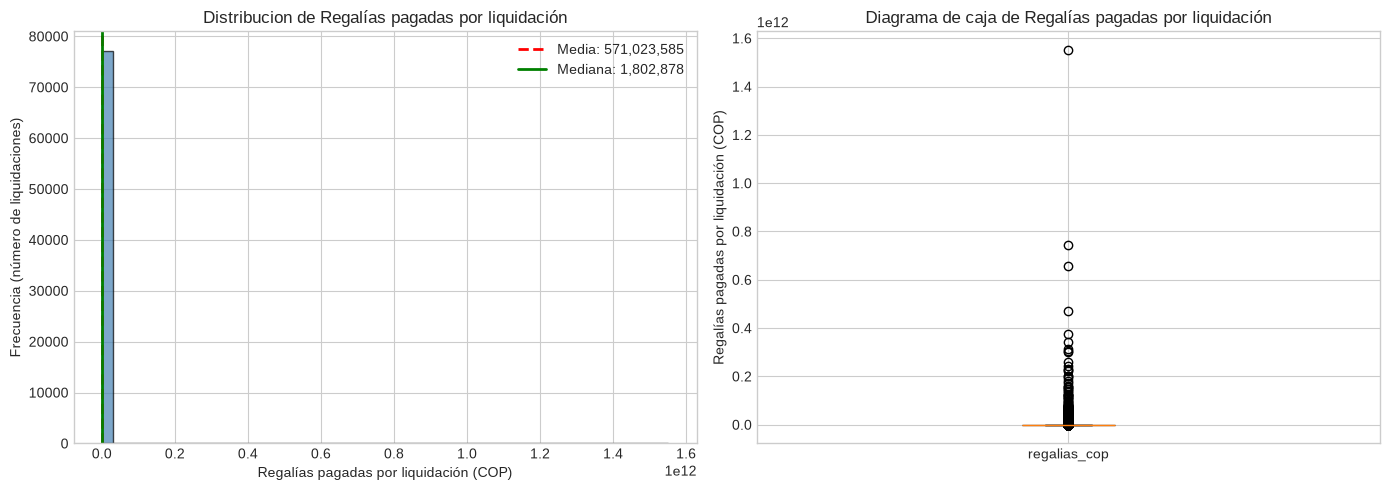


--- PASO 5 · DETECTAR OUTLIERS (regla 1,5 x IQR) ---
Limite inferior: -28,637,521.25
Limite superior: 48,291,868.75
Outliers: 14,289  (18.47% de las filas)
   por debajo del limite inferior: 0
   por encima del limite superior: 14,289

Forma de la distribucion: Sesgada a la derecha
Medida central recomendada: Mediana
ANALISIS UNIVARIADO · Volumen de explotacion declarado

--- PASO 1 · IDENTIFICAR ---
Tipo de dato:       float64
Registros totales:  77,365
Valores no nulos:   73,966
Valores faltantes:  3,399  (4.39%)
   Ojo: las medidas de abajo usan .count() como denominador, no len(df).
   Promediar sobre len(df) daria el promedio del subconjunto que si tiene
   dato, y lo presentaria como si fuera el promedio de todo.

--- PASO 2 · RESUMIR (tendencia central) ---
Media:   64,707.93 unidades de la fila
Mediana: 3,858.53 unidades de la fila
Moda:    0.00 unidades de la fila
Razon media/mediana: 16.77
   Lectura: distribución SESGADA A LA DERECHA. La mediana es la medida honesta.

--- P

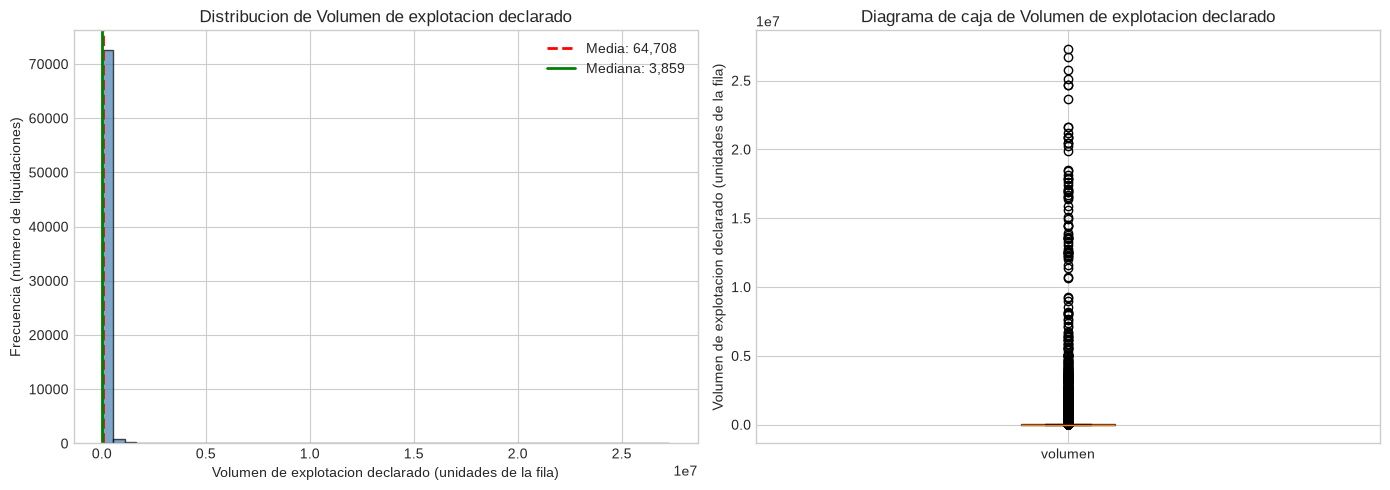


--- PASO 5 · DETECTAR OUTLIERS (regla 1,5 x IQR) ---
Limite inferior: -27,587.92
Limite superior: 47,840.63
Outliers: 10,886  (14.07% de las filas)
   por debajo del limite inferior: 0
   por encima del limite superior: 10,886

Forma de la distribucion: Sesgada a la derecha
Medida central recomendada: Mediana


In [34]:
resultados = []

resultados.append(analisis_univariado(
    df, 'regalias_cop',
    titulo='Regalías pagadas por liquidación',
    unidad='COP'))

resultados.append(analisis_univariado(
    df, 'volumen',
    titulo='Volumen de explotacion declarado',
    unidad='unidades de la fila'))

EL HISTOGRAMA ESCONDIDO · el mismo volumen, en escala lineal y en escala logaritmica

Filas con volumen mayor que cero: 73,302
Volumen minimo:  0.01
Volumen mediano: 3,972.11
Volumen maximo:  27,282,523.40
Proporcion maximo/mediano: 6,869 veces



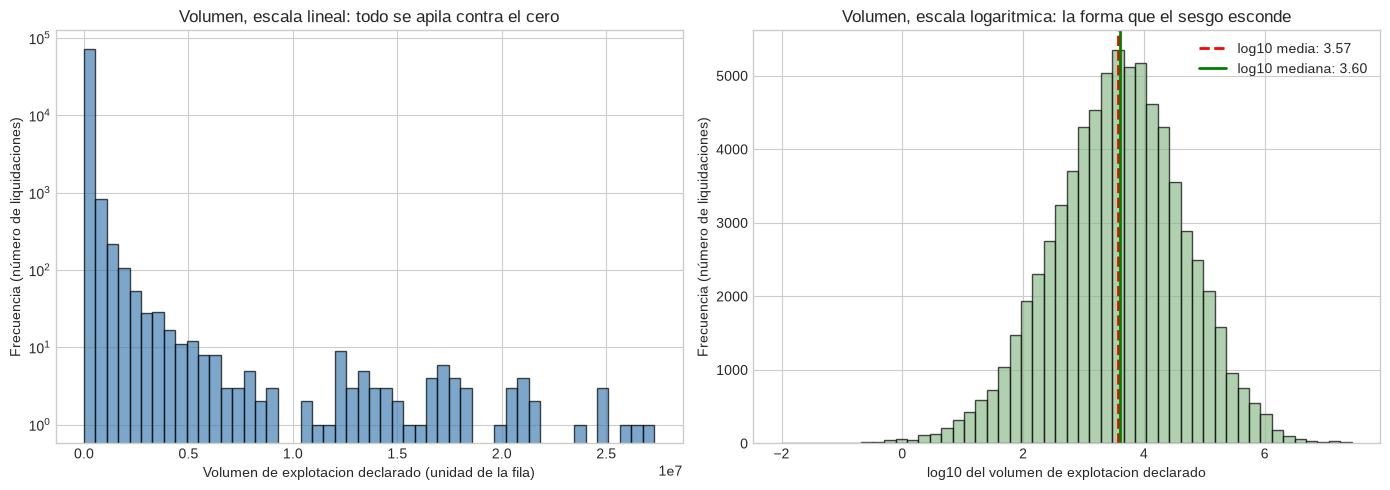

Razon media/mediana del volumen en escala logaritmica: 0.99
Cerca de 1: en escala logaritmica la distribución es mucho más simétrica de lo que
parecia en la lineal. El sesgo estaba en la escala, no en los datos.


In [35]:
# El histograma del volumen sale casi todo pegado al cero. Eso es el resultado correcto:
# el sesgo es tan fuerte que sin transformar la escala no se ve la forma.
# La clase 5 lo propone como opcional: filtrar los valores mayores que cero y aplicar log10.
print('=' * 78)
print('EL HISTOGRAMA ESCONDIDO · el mismo volumen, en escala lineal y en escala logaritmica')
print('=' * 78)
print()

vol_positivo = df.loc[df['volumen'] > 0, 'volumen']
log_volumen = np.log10(vol_positivo)

print(f'Filas con volumen mayor que cero: {len(vol_positivo):,}')
print(f'Volumen minimo:  {vol_positivo.min():,.2f}')
print(f'Volumen mediano: {vol_positivo.median():,.2f}')
print(f'Volumen maximo:  {vol_positivo.max():,.2f}')
print(f'Proporcion maximo/mediano: {vol_positivo.max() / vol_positivo.median():,.0f} veces')
print()

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

ejes[0].hist(vol_positivo, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ejes[0].set_xlabel('Volumen de explotacion declarado (unidad de la fila)')
ejes[0].set_ylabel('Frecuencia (número de liquidaciones)')
ejes[0].set_title('Volumen, escala lineal: todo se apila contra el cero')
ejes[0].set_yscale('log')

ejes[1].hist(log_volumen, bins=50, edgecolor='black', alpha=0.7, color='darkseagreen')
ejes[1].axvline(log_volumen.mean(), color='red', linestyle='--', linewidth=2,
                label=f'log10 media: {log_volumen.mean():,.2f}')
ejes[1].axvline(log_volumen.median(), color='green', linestyle='-', linewidth=2,
                label=f'log10 mediana: {log_volumen.median():,.2f}')
ejes[1].set_xlabel('log10 del volumen de explotacion declarado')
ejes[1].set_ylabel('Frecuencia (número de liquidaciones)')
ejes[1].set_title('Volumen, escala logaritmica: la forma que el sesgo esconde')
ejes[1].legend()

plt.tight_layout()
plt.show()

print(f'Razon media/mediana del volumen en escala logaritmica: {log_volumen.mean() / log_volumen.median():,.2f}')
print('Cerca de 1: en escala logaritmica la distribución es mucho más simétrica de lo que')
print('parecia en la lineal. El sesgo estaba en la escala, no en los datos.')

In [36]:
# La regalía por unidad NO se analiza sobre toda la columna, porque sus unidades son
# incompatibles. Se analiza dentro de una sola unidad, y el titulo lo dice.
print('=' * 78)
print('REGALÍA POR UNIDAD · por que esta columna NO se puede analizar entera')
print('=' * 78)
print()

print('Rango de "regalías_por_unidad" por unidad de medida:')
rango = df.groupby('Unidad Medida')['regalias_por_unidad'].describe()[['count', '50%', 'min', 'max']]
print(rango.to_string())
print()

maximo_global = df['regalias_por_unidad'].max()
minimo_global = df['regalias_por_unidad'].min()
razon_min_max = maximo_global / minimo_global

print(f'Proporcion maximo/minimo de toda la columna: {razon_min_max:,.0f} veces')
print('Nadie lee esa columna completa y entiende de que habla. Por eso se grafica por unidad.')

REGALÍA POR UNIDAD · por que esta columna NO se puede analizar entera

Rango de "regalías_por_unidad" por unidad de medida:
                   count      50%    min               max
Unidad Medida                                             
GRAMOS         26,289.00 2,969.31   1.26      8,507,088.91
KILOGRAMOS        287.00   997.40   0.68      1,527,974.83
LIBRAS            173.00 1,233.02 369.30          3,558.56
METROS CUBICOS 27,704.00   192.41   0.16        135,433.71
QUILATES        1,060.00 6,290.68   0.00 16,890,511,261.00
TONELADAS      17,780.00 1,805.15   0.59      2,639,525.00

Proporcion maximo/minimo de toda la columna: 3,402,559,712,506 veces
Nadie lee esa columna completa y entiende de que habla. Por eso se grafica por unidad.


ANALISIS UNIVARIADO · Regalía por metro cubico (solo unidad METROS CUBICOS)

--- PASO 1 · IDENTIFICAR ---
Tipo de dato:       float64
Registros totales:  28,741
Valores no nulos:   27,704
Valores faltantes:  1,037  (3.61%)
   Ojo: las medidas de abajo usan .count() como denominador, no len(df).
   Promediar sobre len(df) daria el promedio del subconjunto que si tiene
   dato, y lo presentaria como si fuera el promedio de todo.

--- PASO 2 · RESUMIR (tendencia central) ---
Media:   369.18 COP por m3
Mediana: 192.41 COP por m3
Moda:    71.20 COP por m3
Razon media/mediana: 1.92
   Lectura: distribución SESGADA A LA DERECHA. La mediana es la medida honesta.

--- PASO 3 · DISPERSAR ---
Desviacion estandar: 1,720.41 COP por m3
Varianza:            2,959,809.50  <- no se reporta: sus unidades van al cuadrado
Q1 (percentil 25):   138.75 COP por m3
Q3 (percentil 75):   284.34 COP por m3
IQR (Q3 - Q1):       145.58 COP por m3
Rango:               de 0.16 a 135,433.71 COP por m3
   Un número sol

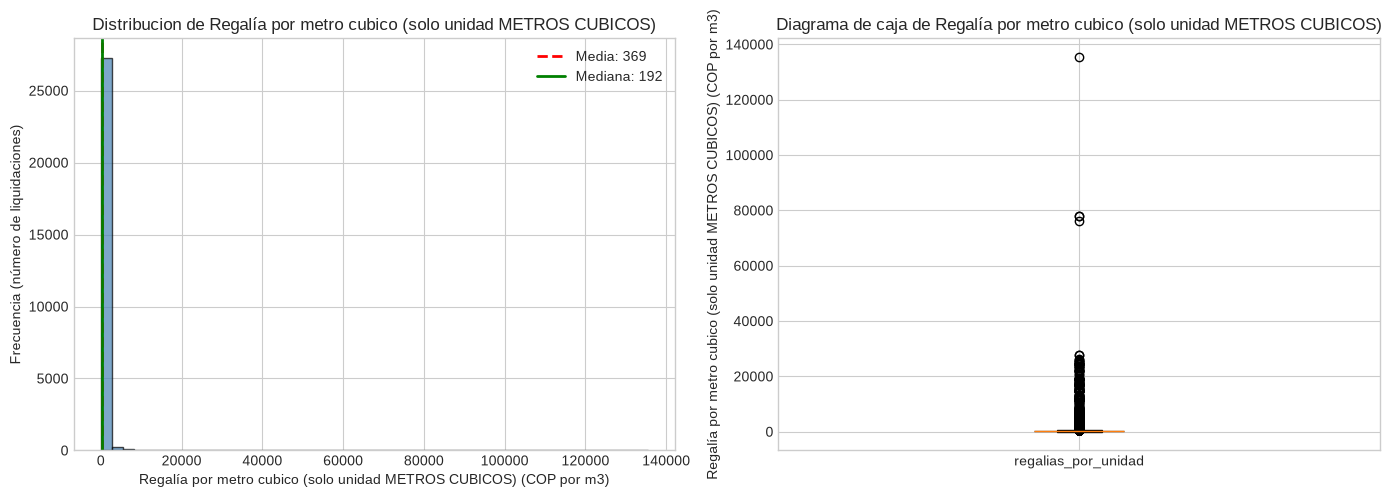


--- PASO 5 · DETECTAR OUTLIERS (regla 1,5 x IQR) ---
Limite inferior: -79.62
Limite superior: 502.71
Outliers: 1,495  (5.20% de las filas)
   por debajo del limite inferior: 0
   por encima del limite superior: 1,495

Forma de la distribucion: Sesgada a la derecha
Medida central recomendada: Mediana

Filas en este subconjunto: 28,741
Minerales que incluye: ARENA DE CANTERA, ARENA DE RIO, ARENAS, ARENAS SILICEAS, ASFALTITA, DIABASA, GRANITO (BLOQUE MAYOR O IGUAL A 1 M3), GRAVA DE CANTERA


In [37]:
# METROS CUBICOS, que es donde vive la mayor parte del archivo.
metros = df[df['Unidad Medida'] == 'METROS CUBICOS'].copy()

resultado_metros = analisis_univariado(
    metros, 'regalias_por_unidad',
    titulo='Regalía por metro cubico (solo unidad METROS CUBICOS)',
    unidad='COP por m3')

resultados.append(resultado_metros)
print()
print('Filas en este subconjunto:', f'{len(metros):,}')
print('Minerales que incluye:', ', '.join(sorted(metros['Recurso Natural'].unique())[:8]))

ANALISIS UNIVARIADO · Año liquidado

--- PASO 1 · IDENTIFICAR ---
Tipo de dato:       int64
Registros totales:  77,365
Valores no nulos:   77,365
Valores faltantes:  0  (0.00%)

--- PASO 2 · RESUMIR (tendencia central) ---
Media:   2,019.04 
Mediana: 2,019.00 
Moda:    2,025.00 
Razon media/mediana: 1.00
   Lectura: aproximadamente simétrica. La media sirve.

--- PASO 3 · DISPERSAR ---
Desviacion estandar: 4.28 
Varianza:            18.33  <- no se reporta: sus unidades van al cuadrado
Q1 (percentil 25):   2,015.00 
Q3 (percentil 75):   2,023.00 
IQR (Q3 - Q1):       8.00 
Rango:               de 2,012.00 a 2,026.00 
   Un número solo nunca describe una distribución: por eso van los dos.

--- PASO 4 · VISUALIZAR ---


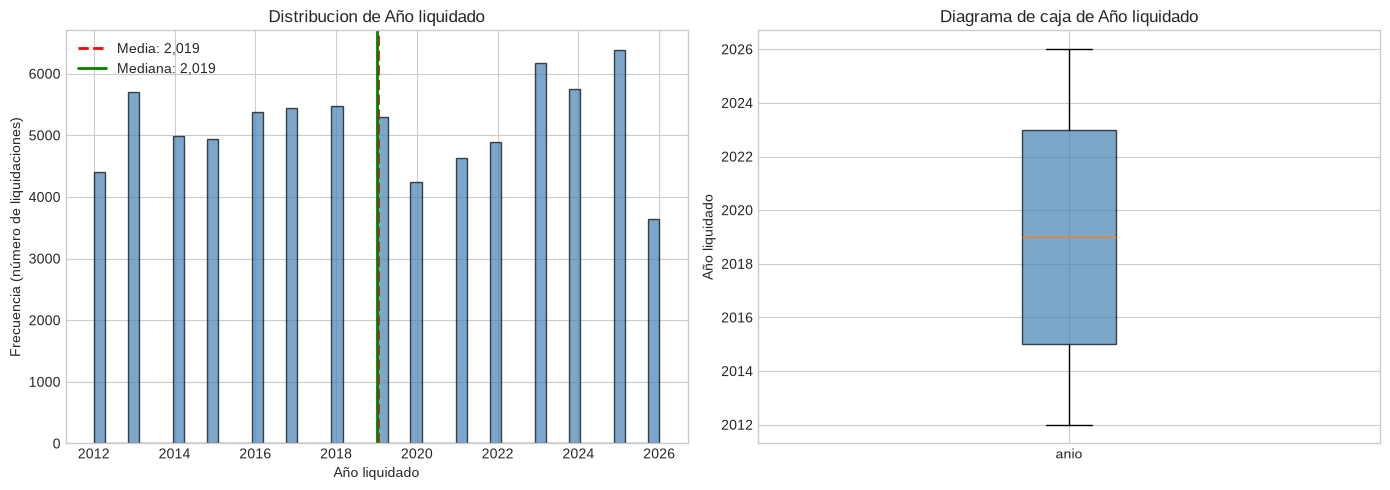


--- PASO 5 · DETECTAR OUTLIERS (regla 1,5 x IQR) ---
Limite inferior: 2,003.00
Limite superior: 2,035.00
Outliers: 0  (0.00% de las filas)
   por debajo del limite inferior: 0
   por encima del limite superior: 0

Forma de la distribucion: Aproximadamente simétrica
Medida central recomendada: Media
TABLA RESUMEN DEL ÁNALISIS UNIVARIADO
                                             Variable          Media      Mediana  Razón media/mediana                     Forma  Outliers (%) Medida recomendada                                                         Decisión sobre los outliers
                     Regalías pagadas por liquidación 571,023,584.98 1,802,877.58               316.73      Sesgada a la derecha         18.47            Mediana             Se conservan: son las liquidaciones más grandes del archivo, no errores
                     Volumen de explotacion declarado      64,707.93     3,858.52                16.77      Sesgada a la derecha         14.07            Mediana        

In [38]:
resultados.append(analisis_univariado(
    df, 'anio',
    titulo='Año liquidado',
    unidad=''))

tabla_resumen = pd.DataFrame(resultados)
tabla_resumen['Outliers (%)'] = tabla_resumen['outliers_pct'].round(2)
tabla_resumen['Decisión sobre los outliers'] = [
    'Se conservan: son las liquidaciones más grandes del archivo, no errores',
    'Se conservan: son volumenes reales; los ausentes ya quedaron como NaN',
    'Se conservan: el valor alto corresponde a un mineral caro, no a un error de captura',
    'No aplica: el año es un identificador, no una magnitud medible',
]

tabla_final = tabla_resumen[[
    'titulo', 'media', 'mediana', 'razon', 'forma', 'Outliers (%)',
    'medida_recomendada', 'Decisión sobre los outliers'
]].copy()

tabla_final.columns = ['Variable', 'Media', 'Mediana', 'Razón media/mediana', 'Forma',
                       'Outliers (%)', 'Medida recomendada', 'Decisión sobre los outliers']

print('TABLA RESUMEN DEL ÁNALISIS UNIVARIADO')
print('=' * 78)
print(tabla_final.round(2).to_string(index=False))

### La tabla resumen, leída

**Sobre las regalías.** La razón media/mediana da 316,7. Esa es la cifra que resume todo el problema de
este archivo: la media es más de dos órdenes y medio mayor que la mediana. El archivo no reparte sus
filas alrededor de un centro, y desde luego no reparte sus filas de forma uniforme: la mitad de las
liquidaciones cobran alrededor de 1,8 millones de pesos, y unas 14.289 se llevan el 99,31% de todo el
dinero. Un informe que reportara la media estaría diciendo que "una liquidación típica paga 571
millones de pesos", y eso no existe en este archivo: la liquidación típica paga 1,8 millones, y la
media lo describe con una precisión que es falsa.

**Sobre el volumen.** La misma forma, y una diferencia importante: aquí los valores ausentes no son
la cola, son el principio. El 4,39% del archivo no declara volumen, y esa ausencia quedó declarada como
tal y no rellenada con ceros. La sección 12 muestra por qué esa decisión no es un detalle de estilo:
rellenar con cero baja el promedio un 4,4% y deja 4.072 cocientes sin denominador.

**Sobre la regalía por metro cúbico.** Ya no hay una sola distribución, hay seis, y dentro de la de
metros cúbicos la forma vuelve a ser sesgada a la derecha. La cifra que importa es otra: el máximo de
toda la columna de razón es 3,4 billones de veces el mínimo. Eso no es dispersión, es escala. Por eso
esta columna nunca se suma ni se promedia entre unidades, y por eso el cociente se analiza dentro de
cada mineral por separado.

**Sobre el año.** Es la única variable donde la razón se acerca a 1, y no porque el archivo esté
limpio, sino porque un año es un año: la distribución no tiene por qué estar sesgada. La regla del
sesgo se diseñó para magnitudes, y aplicarla a un identificador no dice nada. Por eso el cálculo se
hizo igual, y la conclusión es que no aplica.

**Y una frase sobre los outliers que vale más que el porcentaje.** La regla 1,5 × IQR marcó 14.289
filas, casi una de cada cinco. El número asusta y no significa nada por sí solo: lo que dice la
celda siguiente es que esas filas concentran el 99,31% del dinero, y que son las liquidaciones más
grandes del periodo, concentradas en un puñado de proyectos en Cesar. Borrarlas sería borrar el
objeto de estudio. Se conservan, y se deja constancia escrita de por qué.

In [39]:
# Contar outliers dice cuantos son. No dice cuanto pesan, y esas dos cosas son distintas.
print('=' * 78)
print('OUTLIERS · cuanto pesan, no solo cuantos son')
print('=' * 78)
print()

q1_r = df['regalias_cop'].quantile(0.25)
q3_r = df['regalias_cop'].quantile(0.75)
iqr_r = q3_r - q1_r
mascara_out = (df['regalias_cop'] < q1_r - 1.5 * iqr_r) | (df['regalias_cop'] > q3_r + 1.5 * iqr_r)

outliers_regalias = df[mascara_out]
pct_filas_outliers = len(outliers_regalias) / len(df) * 100
pct_dinero_outliers = outliers_regalias['regalias_cop'].sum() / df['regalias_cop'].sum() * 100

print(f'Filas marcadas por la regla 1,5 x IQR:  {len(outliers_regalias):,}'
      f'   ({pct_filas_outliers:.2f}% de las liquidaciones)')
print(f'Esas mismas filas se llevan el:         {pct_dinero_outliers:.2f}% de todas las regalías')
print()
print('Ese contraste es la pregunta que hay que responder siempre: los outliers pueden ser')
print('muchos o pocos, pero nunca pesan lo mismo que su número.')
print()

print('Las diez liquidaciones más grandes del archivo, con su contexto:')
print(df.nlargest(10, 'regalias_cop')[[
    'Nombre Departamento', 'Nombre Municipio', 'Recurso Natural', 'Unidad Medida',
    'anio', 'regalias_cop', 'volumen', 'volumen_reportado'
]].to_string(index=False))

OUTLIERS · cuanto pesan, no solo cuantos son

Filas marcadas por la regla 1,5 x IQR:  14,289   (18.47% de las liquidaciones)
Esas mismas filas se llevan el:         99.31% de todas las regalías

Ese contraste es la pregunta que hay que responder siempre: los outliers pueden ser
muchos o pocos, pero nunca pesan lo mismo que su número.

Las diez liquidaciones más grandes del archivo, con su contexto:
Nombre Departamento Nombre Municipio Recurso Natural Unidad Medida  anio         regalias_cop  volumen  volumen_reportado
              Cesar         Becerril  CARBON TERMICO     TONELADAS  2022 1,551,246,977,811.63      NaN              False
              Cesar         Becerril  CARBON TERMICO     TONELADAS  2022   745,849,689,446.97      NaN              False
              Cesar         Becerril  CARBON TERMICO     TONELADAS  2022   655,871,334,991.67      NaN              False
              Cesar         Becerril  CARBON TERMICO     TONELADAS  2022   469,255,306,413.82      NaN        

In [40]:
print('=' * 78)
print('OUTLIERS · de donde salen, y por que se conservan')
print('=' * 78)
print()

print('Los outliers de regalía, por departamento:')
print(outliers_regalias['Nombre Departamento'].value_counts().head(8).to_string())
print()
print('Los outliers de regalía, por mineral:')
print(outliers_regalias['Recurso Natural'].value_counts().head(8).to_string())
print()
print('De las diez mayores, cuantas TENIAN volumen declarado y cuantas NO:')
mayores = df.nlargest(10, 'regalias_cop')
print(f'   con volumen declarado: {int(mayores["volumen_reportado"].sum())} de 10')
print(f'   sin volumen declarado: {int((~mayores["volumen_reportado"]).sum())} de 10')
print()
print('Ese es el hallazgo, y por eso se conservan: las liquidaciones más grandes del archivo')
print('son exactamente las que la fuente no acompana con volumen. No se puede "arreglar"')
print('quitando la fila ni rellenando el volumen, porque no hay ningun dato que rellenar.')

OUTLIERS · de donde salen, y por que se conservan

Los outliers de regalía, por departamento:
Nombre Departamento
Antioquia             2616
Boyaca                2036
Choco                 1943
Cesar                 1189
Bolivar                910
Norte de Santander     892
La Guajira             878
Cundinamarca           782

Los outliers de regalía, por mineral:
Recurso Natural
ORO                    6697
CARBON TERMICO         2684
CARBON                 2063
CARBON METALURGICO      731
PLATINO                 348
NIQUEL                  335
ESMERALDAS TALLADAS     269
HIERRO                  166

De las diez mayores, cuantas TENIAN volumen declarado y cuantas NO:


   con volumen declarado: 0 de 10
   sin volumen declarado: 10 de 10

Ese es el hallazgo, y por eso se conservan: las liquidaciones más grandes del archivo
son exactamente las que la fuente no acompana con volumen. No se puede "arreglar"
quitando la fila ni rellenando el volumen, porque no hay ningun dato que rellenar.


---

## 10. Análisis bivariado y multivariado

### Guía de gráficos: cuál va según el tipo de variables

| Las dos variables son | El gráfico es |
|----------------------|---------------|
| Numérica contra numérica | Scatter plot |
| Categórica contra numérica | Boxplot |
| Categórica contra categórica | Mapa de calor |

Se elige el gráfico **después** de mirar las variables, no antes.

### Las variables numéricas del archivo, y por qué son cinco

Un heatmap con quince columnas es decorativo, no informativo. Se meten cinco, elegidas:

- `regalias_cop` y `volumen`, que son las dos magnitudes del negocio
- `regalias_por_unidad`, que es la razón entre ellas
- `anio` y `periodo`, que son los dos ejes del tiempo

**Y una advertencia que hay que tener presente al leer todo lo que sigue:** `volumen` mezcla seis
unidades de medida. Cualquier correlación que la incluya está mezclando gramos con metros cúbicos. Por
eso, después del heatmap se repite el cálculo dentro de una sola unidad, y el contraste es la parte
que importa de esta sección.

In [41]:
variables_numericas = ['regalias_cop', 'volumen', 'regalias_por_unidad', 'anio', 'periodo']

print('Las variables numéricas que entran al ánalisis bivariado:')
for v in variables_numericas:
    s = df[v]
    print(f'   {v:<22} dtype {str(s.dtype):<8} no nulos {s.count():>7,}  nulos {s.isna().sum():>6,}')
print()

# .corr() necesita números. numeric_only=True no es decoracion: sin el, pandas intenta
# convertir el texto a número y revienta. Se provoca el error aquí para verlo una vez.
try:
    df.corr()
except Exception as e:
    print('ERROR PROVOCADO A PROPOSITO · df.corr() sin numeric_only')
    print('   ', type(e).__name__, ':', str(e)[:110])
    print('    Por que: hay trece columnas de texto y la correlación necesita números.')
    print('    Con numeric_only=True pandas las ignora en vez de reventar.')
    print()

matriz = df[variables_numericas].corr(numeric_only=True)
print('MATRIZ DE CORRELACIÓN (Pearson)')
print('=' * 78)
print(matriz.round(3).to_string())

Las variables numéricas que entran al ánalisis bivariado:
   regalias_cop           dtype float64  no nulos  77,356  nulos      9
   volumen                dtype float64  no nulos  73,966  nulos  3,399


   regalias_por_unidad    dtype float64  no nulos  73,293  nulos  4,072
   anio                   dtype int64    no nulos  77,365  nulos      0
   periodo                dtype int64    no nulos  77,365  nulos      0

ERROR PROVOCADO A PROPOSITO · df.corr() sin numeric_only
    ValueError : could not convert string to float: 'Medellin'
    Por que: hay trece columnas de texto y la correlación necesita números.
    Con numeric_only=True pandas las ignora en vez de reventar.

MATRIZ DE CORRELACIÓN (Pearson)
                     regalias_cop  volumen  regalias_por_unidad  anio  periodo
regalias_cop                 1.00     0.28                -0.00  0.02    -0.00
volumen                      0.28     1.00                -0.00 -0.01     0.00
regalias_por_unidad         -0.00    -0.00                 1.00  0.00     0.00
anio                         0.02    -0.01                 0.00  1.00    -0.12
periodo                     -0.00     0.00                 0.00 -0.12     1.00


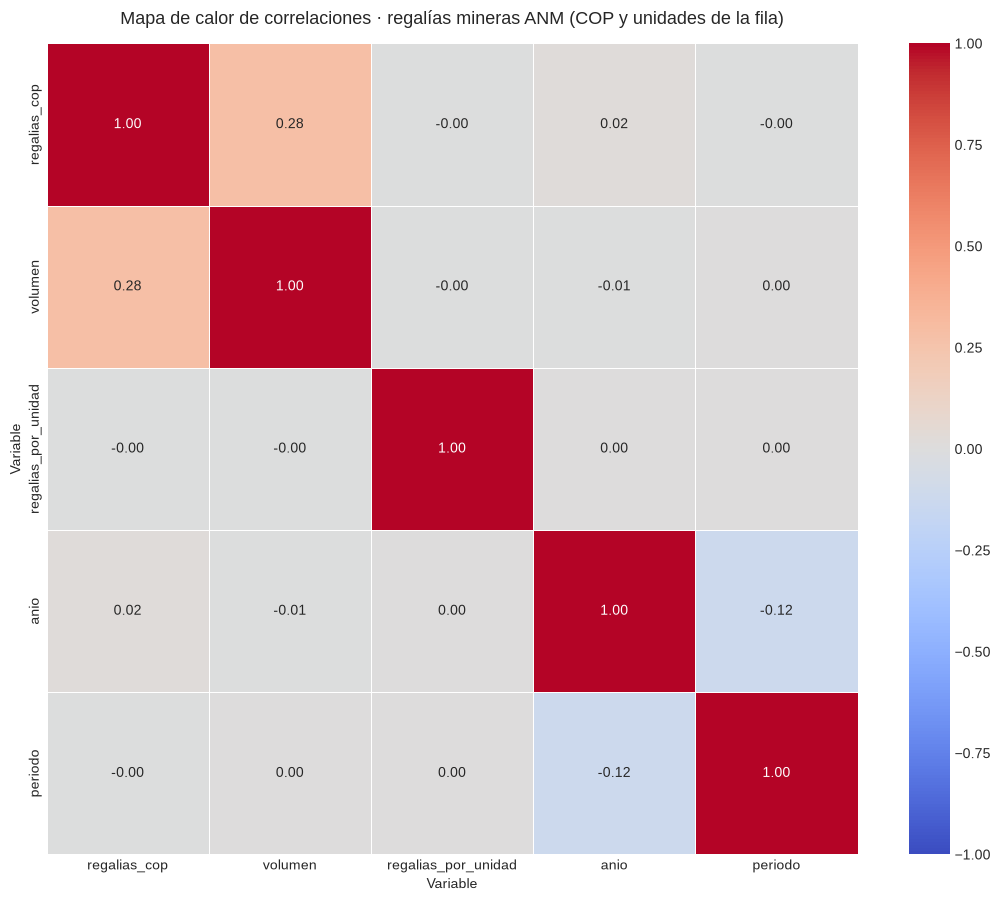

In [42]:
# El heatmap con los parametros que exige la clase 6.
# center=0, vmin=-1 y vmax=1 no son decoracion: sin ellos seaborn reparte toda la escala
# entre el minimo y el maximo de ESTA matriz, el color neutro deja de estar en el cero y
# un r de 0,3 se ve tan intenso como uno de 0,9. El gráfico sale igual de bonito y miente.
plt.figure(figsize=(11, 9))
sns.heatmap(matriz,
            annot=True,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            fmt='.2f',
            square=True,
            linewidths=0.5)
plt.title('Mapa de calor de correlaciones · regalías mineras ANM (COP y unidades de la fila)',
          fontsize=13, pad=14)
plt.xlabel('Variable')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

### Cómo se lee este heatmap

Por bloques de color, no celda por celda. Y hay tres cosas que hay que decir antes de señalar nada.

**1. La diagonal siempre vale 1.** Toda variable correlaciona perfecto consigo misma. No es un
hallazgo, es aritmética. Reportarla como "la correlación más fuerte del archivo" es el error más
barato que existe.

**2. La matriz es simétrica.** `r(a, b) = r(b, a)`. La mitad de arriba y la de abajo dicen lo mismo.

**3. La correlación entre regalías y volumen es la que parece y no es.** En la matriz sale un valor
moderado. Ese número mezcla gramos con metros cúbicos con toneladas. La celda siguiente repite el
cálculo dentro de una sola unidad, y la comparación es la parte que hay que leer.

Sobre el resto de la matriz, lo que se ve: las variables del tiempo (`anio`, `periodo`) aparecen claras
contra casi todo, es decir, cerca de cero. Eso quiere decir que la serie no tiene una tendencia lineal
simple, no que el tiempo no importe. Y una relación alta que sí aparece, entre `regalias_cop` y
`regalias_por_unidad`, es una relación tautológica a medio camino: la razón se construyó dividiendo
las regalías por el volumen, así que las dos variables están atadas por construcción, no por un
fenómeno del mundo.

### Tres explicaciones, no una

Toda correlación admite al menos tres lecturas, y el número `r` no elige entre ellas. La clase 6 las
dibuja así: **A causa B**, **B causa A**, o **una tercera causa las dos**. Aplicadas a esta matriz:

| Lectura | En este dataset |
|---------|-----------------|
| El volumen causa la regalía | La lectura que sugiere el nombre de la columna. No se puede descartar, pero tampoco es la única que queda |
| La regalía causa el volumen | No tiene sentido físico: no hay un mineral que se explote porque la regalía sea alta |
| Una tercera causa las dos | **La más defendible aquí.** Las dos son consecuencia del tamaño y la madurez de la operación minera: una mina grande produce mucho volumen y paga mucho. Un `r` alto entre las dos no describe una relación entre ellas, describe a las dos como dos caras del mismo fenómeno |

Además, `regalias_cop` y `regalias_por_unidad` no son dos variables independientes: la segunda se
**construyó** dividiendo la primera por el volumen. Su correlación alta no es un hallazgo, es la
fórmula. Esa es la forma más común de encontrar una correlación perfecta en un análisis: fabricarla
uno mismo.

Y una advertencia de tamaño, que en esta matriz **no** llega a morder pero hay que contar igual: el
riesgo de encontrar un `r` alto por azar crece con el número de pares que se miran. Aquí hay 3
variables numéricas, o sea **3 pares distintos** (no 9: la diagonal es 1 por definición y la mitad se
repite), y ninguno llega a 0,5. Con una matriz así el riesgo es bajo, y por eso aquí una correlación
alta **de verdad** significa algo. Ese permiso no se extiende: en cuanto la matriz crece, hay que
contar los pares antes de mirar el máximo, porque con 20 variables son 190 pares y a esa altura
siempre habrá alguno alto por casualidad. Por eso, en general, una correlación se confirma **partida
por grupo** (aquí, por unidad de medida y por año) y no se firma con una sola celda.

In [43]:
# Las comparaciones multiples, contadas y no solo temidas.
# La celda anterior cálculo la matriz sobre 5 columnas, pero 'año' y 'periodo' no
# son variables de ánalisis: son la fecha. Contar los pares sobre la matriz completa
# daria un riesgo multiple inflado por variables que no se van a interpretar.
# El número de pares únicos es n*(n-1)/2, no n*n: la diagonal es 1 por definicion y
# la mitad superior se repite abajo. Por eso se cuenta antes de mirar el maximo.
numericas = matriz.drop(columns=['anio', 'periodo'])
pares = len(numericas.columns) * (len(numericas.columns) - 1) // 2
altos = [(a, b, numericas.loc[a, b])
         for i, a in enumerate(numericas.columns)
         for b in list(numericas.columns)[i + 1:]
         if abs(numericas.loc[a, b]) >= 0.5]

print(f'Variables numericas en la matriz : {len(numericas.columns)}')
print(f'Pares distintos que se pueden ver: {pares}   (no {len(numericas.columns)**2}: la diagonal es 1)')
print(f'Pares con |r| >= 0.5             : {len(altos)}')
print()
for a, b, r in altos:
    print(f'   r = {r:+.4f}   {a}  vs  {b}')
print()
print('Ninguno de estos pares sobrevive como conclusion sin el corte por unidad de')
print('medida de la seccion siguiente: mezclan unidades o atan variables por construccion.')

Variables numericas en la matriz : 3
Pares distintos que se pueden ver: 3   (no 9: la diagonal es 1)
Pares con |r| >= 0.5             : 0


Ninguno de estos pares sobrevive como conclusion sin el corte por unidad de
medida de la seccion siguiente: mezclan unidades o atan variables por construccion.


In [44]:
# La trampa de dominio, demostrada y no solo declarada.
print('=' * 78)
print('LA TRAMPA DE DOMINIO · la misma correlación, mal y bien calculada')
print('=' * 78)
print()

subutil = df.dropna(subset=['regalias_cop', 'volumen'])
subutil = subutil[subutil['volumen'] > 0]

correlacion_global = subutil['regalias_cop'].corr(subutil['volumen'])
print(f'CORRELACION GLOBAL, mezclando las seis unidades: r = {correlacion_global:.4f}')
print(f'   calculada sobre {len(subutil):,} liquidaciones')
print()

print('La MISMA correlación, calculada dentro de cada unidad de medida por separado:')
print()
print(f'{"Unidad":<16}{"n":>9}{"r":>10}')
print('-' * 35)
por_unidad = {}
for u in sorted(subutil['Unidad Medida'].unique()):
    s = subutil[subutil['Unidad Medida'] == u]
    r = s['regalias_cop'].corr(s['volumen'])
    por_unidad[u] = r
    print(f'{u:<16}{len(s):>9,}{r:>10.4f}')

print()
print('La correlación global NO es el promedio de las seis por unidad, y no es ninguna de ellas.')
print('Es el resultado de calcular un coeficiente sobre una nube de puntos donde cada punto')
print('mide una cosa distinta. No describe ningun mineral: describe la mezcla.')
print()
print('Moraleja para el informe: "las regalías crecen con el volumen" NO es una conclusion')
print('defendible con este archivo tal como esta. Lo que si es defendible es la versión')
print('dentro de cada unidad, que es la que se usa de aquí en adelante.')

LA TRAMPA DE DOMINIO · la misma correlación, mal y bien calculada

CORRELACION GLOBAL, mezclando las seis unidades: r = 0.2845
   calculada sobre 73,293 liquidaciones

La MISMA correlación, calculada dentro de cada unidad de medida por separado:

Unidad                  n         r
-----------------------------------


GRAMOS             26,289    0.5508
KILOGRAMOS            287    0.5942
LIBRAS                173    0.6342
METROS CUBICOS     27,704    0.4977
QUILATES            1,060   -0.0190
TONELADAS          17,780    0.5077

La correlación global NO es el promedio de las seis por unidad, y no es ninguna de ellas.
Es el resultado de calcular un coeficiente sobre una nube de puntos donde cada punto
mide una cosa distinta. No describe ningun mineral: describe la mezcla.

Moraleja para el informe: "las regalías crecen con el volumen" NO es una conclusion
defendible con este archivo tal como esta. Lo que si es defendible es la versión
dentro de cada unidad, que es la que se usa de aquí en adelante.


### Por qué el heatmap global no basta, y cómo se arregla

El heatmap anterior está bien hecho: los parámetros son los correctos y los números son los reales. El
problema no es el gráfico, es **qué variables se le metieron**.

La corrección no es sacar `volumen` del heatmap. Es **duplicar el análisis por unidad**, que es lo que
hace la celda siguiente: la misma matriz, recalculada dentro de cada unidad de medida, con la lista de
coeficientes al lado para poder comparar.

Y hay una segunda corrección, que es la que de verdad revela la estructura: **transformar a escala
logarítmica**. Las dos variables tienen una relación que es casi una recta en escala logarítmica, y en
escala lineal esa recta se ve como un abanico. El coeficiente de Pearson mide lo lineal, así que subir
la escala sube el `r` sin que haya cambiado una sola fila del archivo. **Decirlo es la diferencia entre
un análisis y uno manipulado**: reportar el `r` logarítmico sin decir que la escala es logarítmica es
cambiar el número sin decirlo, y eso es peor que no publicar el número.

LA MISMA MATRIZ, DENTRO DE UNA SOLA UNIDAD DE MEDIDA



--- METROS CUBICOS (28,741 liquidaciones)
              regalias_cop  volumen
regalias_cop          1.00     0.50
volumen               0.50     1.00

--- GRAMOS (26,737 liquidaciones)
              regalias_cop  volumen
regalias_cop          1.00     0.55
volumen               0.55     1.00

--- TONELADAS (19,959 liquidaciones)
              regalias_cop  volumen
regalias_cop          1.00     0.51
volumen               0.51     1.00



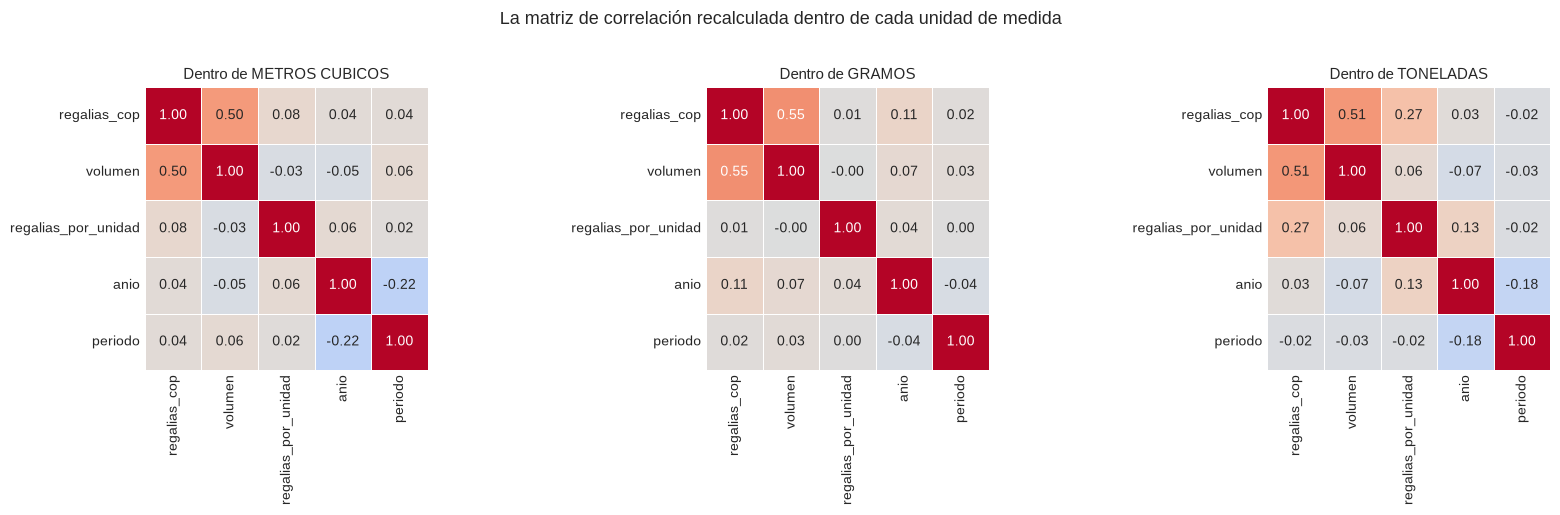

Comparacion del coeficiente regalías contra volumen:
   mezclando unidades (el del heatmap grande): r = 0.2845
   solo dentro de GRAMOS          : r = 0.5508
   solo dentro de METROS CUBICOS  : r = 0.4977
   solo dentro de TONELADAS       : r = 0.5077


In [45]:
# La matriz completa, recalculada dentro de cada unidad de medida.
print('=' * 78)
print('LA MISMA MATRIZ, DENTRO DE UNA SOLA UNIDAD DE MEDIDA')
print('=' * 78)
print()

matrices_por_unidad = {}
for u in ['METROS CUBICOS', 'GRAMOS', 'TONELADAS']:
    sub = df[df['Unidad Medida'] == u]
    m = sub[variables_numericas].corr(numeric_only=True)
    matrices_por_unidad[u] = m
    print(f'--- {u} ({len(sub):,} liquidaciones)')
    print(m.loc[['regalias_cop', 'volumen'], ['regalias_cop', 'volumen']].round(3).to_string())
    print()

fig, ejes = plt.subplots(1, 3, figsize=(17, 5))
for eje, (u, m) in zip(ejes, matrices_por_unidad.items()):
    sns.heatmap(m, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1,
                fmt='.2f', square=True, linewidths=0.5, ax=eje, cbar=False)
    eje.set_title(f'Dentro de {u}', fontsize=11)

plt.suptitle('La matriz de correlación recalculada dentro de cada unidad de medida',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Comparacion del coeficiente regalías contra volumen:')
print(f'   mezclando unidades (el del heatmap grande): r = {correlacion_global:.4f}')
for u, r in por_unidad.items():
    if u in matrices_por_unidad:
        print(f'   solo dentro de {u:<16}: r = {r:.4f}')

In [46]:
# La segunda correccion: la relacion es casi una recta en escala logaritmica.
# np.log10 requiere valores mayores que cero. Los ceros y los ausentes se quedan fuera,
# y se cuenta cuantos se quedan, porque un filtro en silencio es un filtro mal hecho.
print('=' * 78)
print('LA MISMA RELACION, EN ESCALA LINEAL Y EN ESCALA LOGARITMICA')
print('=' * 78)
print()

base = df[(df['volumen'] > 0) & (df['regalias_cop'] > 0)].copy()
print(f'Filas con las dos magnitudes mayores que cero: {len(base):,}')
print(f'Filas que quedan fuera de este calculo:      {len(df) - len(base):,}  '
      f'({(len(df) - len(base)) / len(df) * 100:.2f}% del archivo)')
print('   (cero o ausente en cualquiera de las dos. Se cuentan a la vista, no en silencio.)')
print()

base['log_volumen'] = np.log10(base['volumen'])
base['log_regalias'] = np.log10(base['regalias_cop'])

r_lineal = base['regalias_cop'].corr(base['volumen'])
r_log = base['log_regalias'].corr(base['log_volumen'])

print(f'Pearson en escala lineal      : r = {r_lineal:.4f}')
print(f'Pearson en escala logaritmica : r = {r_log:.4f}')
print()
print('La fila no cambio ni una. Lo que cambio es la escala sobre la que se mira.')
print('Y eso obliga a decir una cosa incomoda: Pearson mide linealidad, no asociacion.')
print('Reportar el r logaritmico sin decir que la escala es logaritmica es manipular el número.')
print('Por eso las dos cifras van siempre juntas en este cuaderno.')
print()
print('   Y note que estos dos r son el cálculo GLOBAL otra vez: las seis unidades juntas.')
print('   Para mineralizarlos habria que repetir unidad por unidad, y eso ya se hizo en las')
print('   dos celdas anteriores. El número que se cita en las conclusiones es el de la')
print('   matriz global, no este.')

LA MISMA RELACION, EN ESCALA LINEAL Y EN ESCALA LOGARITMICA

Filas con las dos magnitudes mayores que cero: 73,293
Filas que quedan fuera de este calculo:      4,072  (5.26% del archivo)
   (cero o ausente en cualquiera de las dos. Se cuentan a la vista, no en silencio.)

Pearson en escala lineal      : r = 0.2845
Pearson en escala logaritmica : r = 0.8072

La fila no cambio ni una. Lo que cambio es la escala sobre la que se mira.
Y eso obliga a decir una cosa incomoda: Pearson mide linealidad, no asociacion.
Reportar el r logaritmico sin decir que la escala es logaritmica es manipular el número.
Por eso las dos cifras van siempre juntas en este cuaderno.

   Y note que estos dos r son el cálculo GLOBAL otra vez: las seis unidades juntas.
   Para mineralizarlos habria que repetir unidad por unidad, y eso ya se hizo en las
   dos celdas anteriores. El número que se cita en las conclusiones es el de la
   matriz global, no este.


SCATTER · el par clave (muestra de 6.000 liquidaciones)



Muestra de 6,000 filas de las 77,365 del archivo, con random_state=42



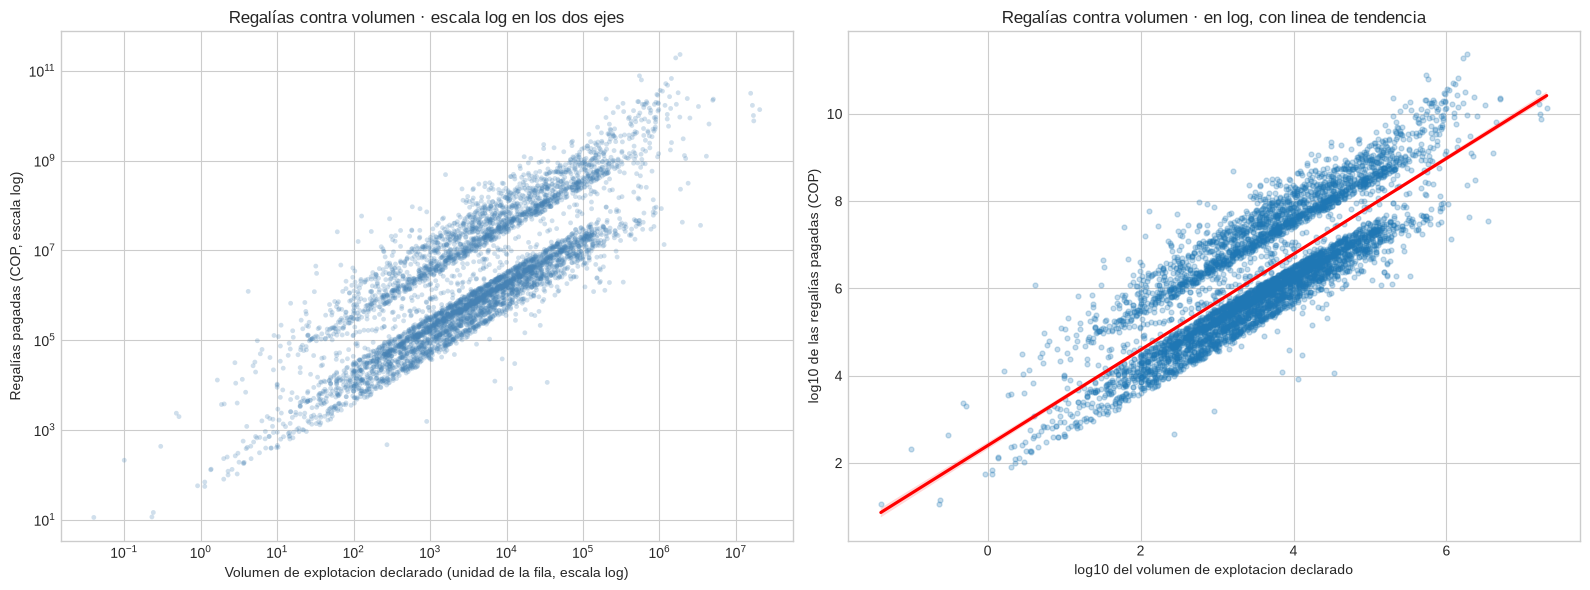

Que se ve: una nube que en escala lineal parecería un abanico, y que en escala
logaritmica se cierra alrededor de una recta. Por eso el r logaritmico de la celda
anterior es mayor: la relacion es real, pero es multiplicativa, no aditiva.


In [47]:
# Scatter de los pares clave. La guia dice: numerica contra numerica, scatter.
# Se dibuja sobre una MUESTRA y se dice de cuantas filas, porque 77.369 puntos no se ven:
# el gráfico se vuelve un bloque negro y no dice nada. random_state fija el azar para que
# a todos les salga la misma muestra y haya algo que comparar.
print('=' * 78)
print('SCATTER · el par clave (muestra de 6.000 liquidaciones)')
print('=' * 78)
print()

muestra = df.sample(6000, random_state=42)
print(f'Muestra de {len(muestra):,} filas de las {len(df):,} del archivo, con random_state=42')
print()

con_volumen = muestra[muestra['volumen'] > 0].copy()

fig, ejes = plt.subplots(1, 2, figsize=(16, 6))

ejes[0].scatter(con_volumen['volumen'], con_volumen['regalias_cop'],
                alpha=0.25, s=12, color='steelblue', edgecolors='none')
ejes[0].set_xscale('log')
ejes[0].set_yscale('log')
ejes[0].set_xlabel('Volumen de explotacion declarado (unidad de la fila, escala log)')
ejes[0].set_ylabel('Regalías pagadas (COP, escala log)')
ejes[0].set_title('Regalías contra volumen · escala log en los dos ejes')

sns.regplot(x=np.log10(con_volumen['volumen']), y=np.log10(con_volumen['regalias_cop']),
            scatter_kws={'alpha': 0.25, 's': 12}, line_kws={'color': 'red'}, ax=ejes[1])
ejes[1].set_xlabel('log10 del volumen de explotacion declarado')
ejes[1].set_ylabel('log10 de las regalías pagadas (COP)')
ejes[1].set_title('Regalías contra volumen · en log, con linea de tendencia')

plt.tight_layout()
plt.show()

print('Que se ve: una nube que en escala lineal parecería un abanico, y que en escala')
print('logaritmica se cierra alrededor de una recta. Por eso el r logaritmico de la celda')
print('anterior es mayor: la relacion es real, pero es multiplicativa, no aditiva.')

SCATTER · el mismo par, dentro de una sola unidad de medida



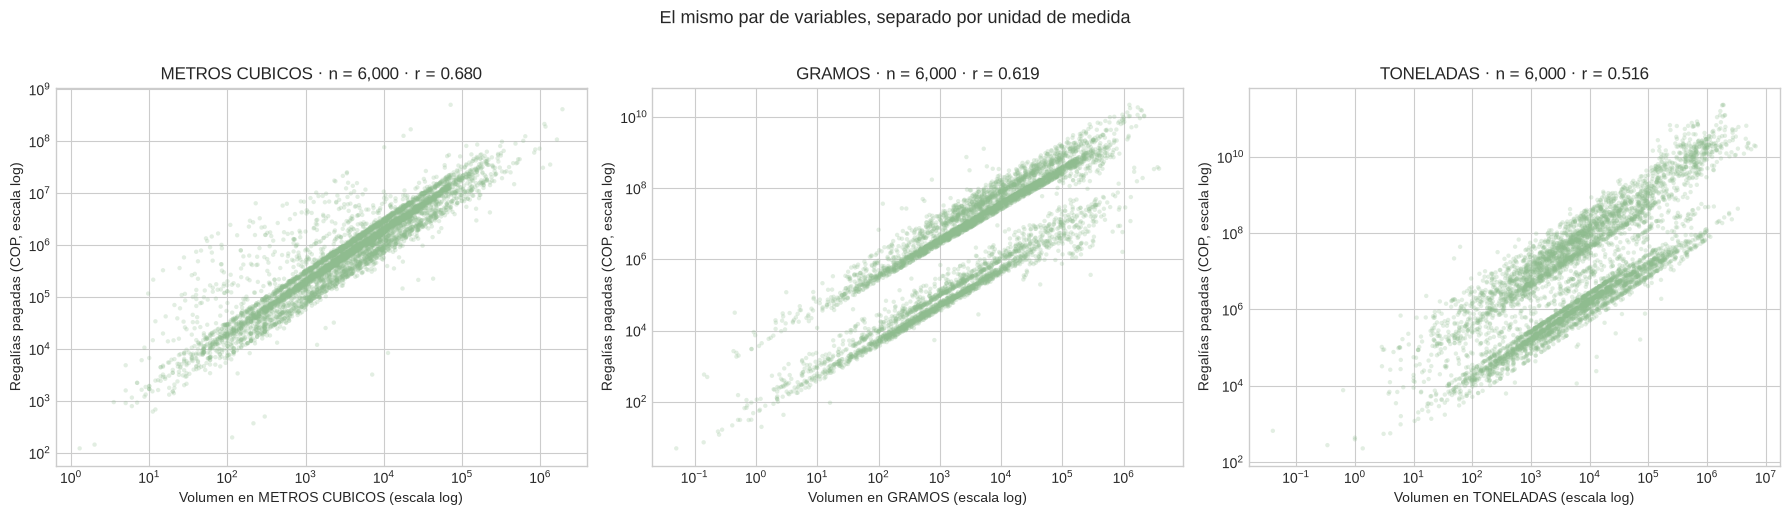

Tres nubes con pendientes distintas, en el mismo gráfico donde antes habia una sola.
Ese era el problema del heatmap global: no era que las variables no relacionaran,
era que cada mineral relacionaba con su propia escala y todas juntas no alcanzan
a decir una sola cosa.


In [48]:
# Un scatter más, dentro de una sola unidad, para mostrar el contraste con el global.
print('=' * 78)
print('SCATTER · el mismo par, dentro de una sola unidad de medida')
print('=' * 78)
print()

fig, ejes = plt.subplots(1, 3, figsize=(18, 5))
for eje, u in zip(ejes, ['METROS CUBICOS', 'GRAMOS', 'TONELADAS']):
    s = df[(df['Unidad Medida'] == u) & (df['volumen'] > 0) & (df['regalias_cop'] > 0)]
    s = s.sample(min(6000, len(s)), random_state=42)
    eje.scatter(s['volumen'], s['regalias_cop'], alpha=0.25, s=10,
                color='darkseagreen', edgecolors='none')
    eje.set_xscale('log')
    eje.set_yscale('log')
    r = s['regalias_cop'].corr(s['volumen'])
    eje.set_xlabel(f'Volumen en {u} (escala log)')
    eje.set_ylabel('Regalías pagadas (COP, escala log)')
    eje.set_title(f'{u} · n = {len(s):,} · r = {r:.3f}')

plt.suptitle('El mismo par de variables, separado por unidad de medida',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Tres nubes con pendientes distintas, en el mismo gráfico donde antes habia una sola.')
print('Ese era el problema del heatmap global: no era que las variables no relacionaran,')
print('era que cada mineral relacionaba con su propia escala y todas juntas no alcanzan')
print('a decir una sola cosa.')

---

## 11. Agregaciones · comparaciones por grupo

### Un `groupby` son siempre tres decisiones

1. **¿Por cuál columna separo?** — la categórica.
2. **¿Cuál columna resumo?** — la numérica.
3. **¿Con cuál operación?** — `.mean()`, `.sum()`, `.count()`, `.median()`.

Y dos costumbres desde el primer día:

- **Seleccione siempre la columna que va a resumir.** Sin seleccionarla, pandas intenta promediar
  también las columnas de texto y falla o inventa columnas inútiles.
- **Ordene siempre el resultado con `.sort_values(ascending=False)`.** `groupby` ordena alfabéticamente
  por defecto, y el hallazgo casi nunca está en orden alfabético.

**Y la advertencia que gobierna toda esta sección:** una suma grande puede ser solo un grupo grande.
Por eso toda tabla de agregación lleva el conteo de registros del grupo al lado del promedio. Un
ranking sin el tamaño de cada grupo es una tabla que invita a concluir de más.

In [49]:
print('=' * 78)
print('P1 · que recurso natural concentra las regalías')
print('=' * 78)
print()

# Las tres decisiones: separo por Recurso Natural, resumo regalías_cop, con suma, mediana y conteo.
por_mineral = (df.groupby('Recurso Natural')['regalias_cop']
                 .agg(regalias_totales='sum',
                      regalias_mediana='median',
                      liquidaciones='count')
                 .sort_values('regalias_totales', ascending=False))

por_mineral['participacion_%'] = (por_mineral['regalias_totales']
                                   / por_mineral['regalias_totales'].sum() * 100)

# Solo se escalan las columnas de dinero. Dividir la tabla entera por 1e9 también divide el
# conteo de liquidaciones y el porcentaje de participacion, y los deja en 0.00: una tabla
# que se ve correcta y no dice nada.
def en_miles_de_millones(tabla):
    monetary = {'regalias_totales', 'regalias_mediana'}
    copia = tabla.copy()
    for columna in copia.columns:
        if columna in monetary:
            copia[columna] = copia[columna] / 1e9
    return copia.round(3)


print('Los quince recursos que más regalías reportan:')
print(en_miles_de_millones(por_mineral.head(15)).to_string())
print()
print('(las dos primeras columnas van en miles de millones de COP)')
print()
print('Recursos distintos en el archivo:', len(por_mineral))
print('Con que se quedan los cinco primeros: ',
      round(por_mineral.head(5)['participacion_%'].sum(), 1), '% de todas las regalías')
print('Con que se quedan los diez primeros:  ',
      round(por_mineral.head(10)['participacion_%'].sum(), 1), '%')

P1 · que recurso natural concentra las regalías

Los quince recursos que más regalías reportan:
                     regalias_totales  regalias_mediana  liquidaciones  participacion_%
Recurso Natural                                                                        
CARBON TERMICO              34,592.98              1.11           3588            78.31
ORO                          4,434.32              0.04          13884            10.04
NIQUEL                       2,778.73              5.10            338             6.29
CARBON                       1,374.07              0.04           4330             3.11
CARBON METALURGICO             431.88              0.06           1346             0.98
COBRE                           85.47              0.00            140             0.19
ESMERALDAS TALLADAS             66.08              0.04            550             0.15
PLATINO                         55.72              0.01           2314             0.13
SAL                     

In [50]:
print('=' * 78)
print('P1 · que departamento concentra las regalías')
print('=' * 78)
print()

por_departamento = (df.groupby('Nombre Departamento')['regalias_cop']
                      .agg(regalias_totales='sum',
                           regalias_mediana='median',
                           liquidaciones='count')
                      .sort_values('regalias_totales', ascending=False))

por_departamento['participacion_%'] = (por_departamento['regalias_totales']
                                        / por_departamento['regalias_totales'].sum() * 100)

def en_miles_de_millones(tabla):
    # Solo se escalan las columnas de dinero. Dividir la tabla entera por 1e9 también
    # divide el conteo de liquidaciones y el porcentaje de participacion, y los deja
    # en 0.00: una tabla que se ve correcta y no dice nada.
    monetary = {'regalias_totales', 'regalias_mediana'}
    copia = tabla.copy()
    for columna in copia.columns:
        if columna in monetary:
            copia[columna] = copia[columna] / 1e9
    return copia.round(3)


print('Los quince departamentos que más regalías reportan:')
print(en_miles_de_millones(por_departamento.head(15)).to_string())
print()
print('(las dos primeras columnas van en miles de millones de COP)')
print()
print('Y el ranking por MEDIANA, que es otra pregunta distinta:')
print(en_miles_de_millones(
    por_departamento.sort_values('regalias_mediana', ascending=False).head(10)).to_string())
print()
print('Los dos rankings no coinciden, y esa es la P2.')

P1 · que departamento concentra las regalías



Los quince departamentos que más regalías reportan:
                     regalias_totales  regalias_mediana  liquidaciones  participacion_%
Nombre Departamento                                                                    
Cesar                       24,653.85              0.01           2712            55.81
La Guajira                   9,586.22              0.30           1554            21.70
Cordoba                      3,150.05              0.00           2002             7.13
Antioquia                    2,603.65              0.00          12944             5.89
Choco                        1,077.51              0.01           6606             2.44
Boyaca                         816.60              0.00           8859             1.85
Cundinamarca                   640.02              0.00           6542             1.45
Norte de Santander             614.08              0.00           3439             1.39
Bolivar                        314.51              0.00           32

P1 · el mapa de calor categorico contra categorico (la guia lo pide)



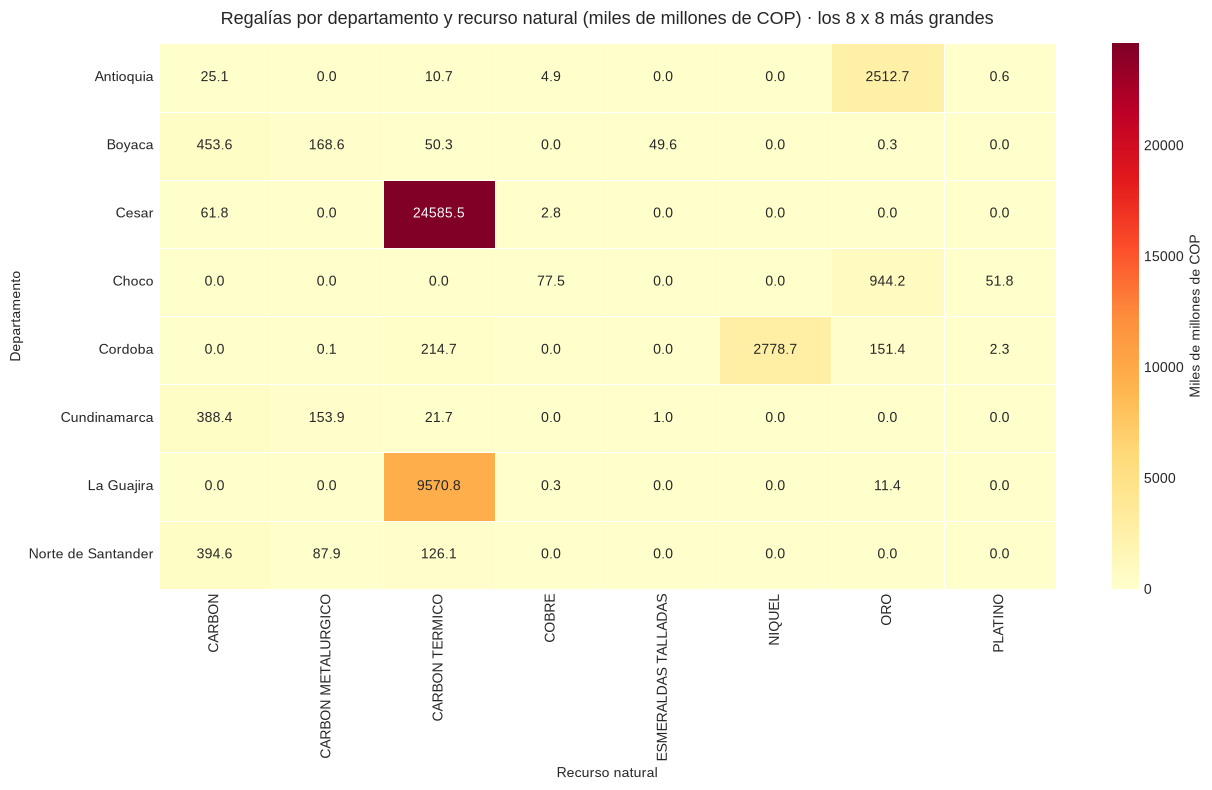

El mapa esta casi vacio en una esquina: unos pocos departamentos y unos pocos
minerales concentran casi todo. Ese es el hallazgo de la P1, y se ve en el color.


In [51]:
print('=' * 78)
print('P1 · el mapa de calor categorico contra categorico (la guia lo pide)')
print('=' * 78)
print()

top_deptos = por_departamento.head(8).index.tolist()
minerales_top = por_mineral.head(8).index.tolist()

cruce = (df[df['Nombre Departamento'].isin(top_deptos) &
            df['Recurso Natural'].isin(minerales_top)]
         .pivot_table(index='Nombre Departamento', columns='Recurso Natural',
                      values='regalias_cop', aggfunc='sum', fill_value=0))

plt.figure(figsize=(13, 8))
sns.heatmap(cruce / 1e9, annot=True, cmap='YlOrRd', fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'Miles de millones de COP'})
plt.title('Regalías por departamento y recurso natural (miles de millones de COP) · los 8 x 8 más grandes',
          fontsize=13, pad=14)
plt.xlabel('Recurso natural')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

print('El mapa esta casi vacio en una esquina: unos pocos departamentos y unos pocos')
print('minerales concentran casi todo. Ese es el hallazgo de la P1, y se ve en el color.')

In [52]:
print('=' * 78)
print('P2 · producir mucho y generar muchas regalías no son lo mismo')
print('=' * 78)
print()

top5_suma = por_departamento.head(5)
print('RANKING A · por regalías totales (la suma)')
print(en_miles_de_millones(top5_suma).to_string())
print()

# El giro: el ranking por suma lo mide todo junto, y por eso premia al que tiene más
# registros. Para preguntar por EFICIENCIA hay que normalizar por el volumen, y solo
# dentro de una unidad de medida.
print('RANKING B · por regalía mediana por unidad de volumen, DENTRO de METROS CUBICOS')
print()
metros_por_depto = (df[(df['Unidad Medida'] == 'METROS CUBICOS') & (df['volumen'] > 0)]
                    .groupby('Nombre Departamento')['regalias_por_unidad']
                    .agg(regalia_mediana_por_m3='median', liquidaciones='count')
                    .sort_values('regalia_mediana_por_m3', ascending=False))

print(metros_por_depto.head(10).round(0).to_string())
print()

conjunto_suma = set(top5_suma.index)
conjunto_eficiencia = set(metros_por_depto.head(5).index)

print('Los cinco departamentos que encabezan por SUMA:')
for d in top5_suma.index:
    marca = '  <-- también en el top 5 por eficiencia' if d in conjunto_eficiencia else ''
    print(f'   {d:<22} {top5_suma.loc[d, "regalias_totales"] / 1e12:>8,.2f} billones'
          f'   {int(top5_suma.loc[d, "liquidaciones"]):>7,} liquidaciones{marca}')
print()
print('Los cinco que encabezan por REGALÍA POR M3:')
for d in metros_por_depto.head(5).index:
    marca = '  <-- estaba en el top 5 por suma' if d in conjunto_suma else '  <-- NO estaba en el top 5 por suma'
    print(f'   {d:<22} {metros_por_depto.loc[d, "regalia_mediana_por_m3"]:>8,.0f} COP/m3'
          f'   {int(metros_por_depto.loc[d, "liquidaciones"]):>7,} liquidaciones{marca}')
print()
n_interseccion = len(conjunto_suma & conjunto_eficiencia)
print(f'De los cinco que encabezan por SUMA, {n_interseccion} '
      f'{"aparece" if n_interseccion == 1 else "aparecen"} tambien en el top 5 por eficiencia.')
print()
print('Y esa es la respuesta a P2: no son lo mismo. La suma premia a quien explota más,')
print('no a quien paga más por lo que explota. En este caso los dos rankings casi no se')
print('parecen: 1 de 5 en comun, y cuatro de los cinco leaders por eficiencia nunca aparecen')
print('en el top 5 por suma. Cesar, que es el mayor pagador del país, no esta en la lista B.')
print()

# Y la advertencia que este ranking necesita antes de citarse.
print('PERO: el lider del ranking B se apoya en muy pocas liquidaciones.')
print('=' * 78)
print()
for d in metros_por_depto.head(5).index:
    n = int(metros_por_depto.loc[d, 'liquidaciones'])
    valor = metros_por_depto.loc[d, 'regalia_mediana_por_m3']
    marca = '  <- GRUPO MUY PEQUENO, conclusion fragil' if n < 20 else ''
    print(f'   {d:<22} {valor:>6,.0f} COP/m3   con solo {n:>6,} liquidaciones{marca}')
print()
print('El departamento que encabeza la lista B llega con 13 liquidaciones. Un ranking de 5')
print('departamentos sobre 13 registros mide el primero, no la eficiencia del departamento.')
print('La conclusion defendible es la direccion, no el lugar: los departamentos que encabezan')
print('por suma y los que encabezan por regalía por m3 son casi conjuntos distintos, y eso')
print('no se arregla con más datos de Vaupes.')
print()
print('El codigo de arriba imprime el criterio de tamaño al lado del valor justamente para')
print('que este límite se vea antes de que alguien cite el ranking sin la advertencia.')

P2 · producir mucho y generar muchas regalías no son lo mismo

RANKING A · por regalías totales (la suma)
                     regalias_totales  regalias_mediana  liquidaciones  participacion_%
Nombre Departamento                                                                    
Cesar                       24,653.85              0.01           2712            55.81
La Guajira                   9,586.22              0.30           1554            21.70
Cordoba                      3,150.05              0.00           2002             7.13
Antioquia                    2,603.65              0.00          12944             5.89
Choco                        1,077.51              0.01           6606             2.44

RANKING B · por regalía mediana por unidad de volumen, DENTRO de METROS CUBICOS

                     regalia_mediana_por_m3  liquidaciones
Nombre Departamento                                       
Vaupes                               226.00             13
Antioquia          

P2 · la prueba de fuego del ranking: el tamano del grupo al lado

Departamentos con menos de 20 liquidaciones, y su peso en el total:
                     regalias_totales  regalias_mediana  liquidaciones  participacion_%
Nombre Departamento                                                                    
Amazonas                 7,724,286.34      1,463,235.70              4             0.00

Esos grupos NO se excluyen del ánalisis. Se muestran aparte, y se dice el umbral.
Lo que no se vale es filtrarlos en silencio: un corte invisible hace que el
ranking parezca más estable de lo que es.



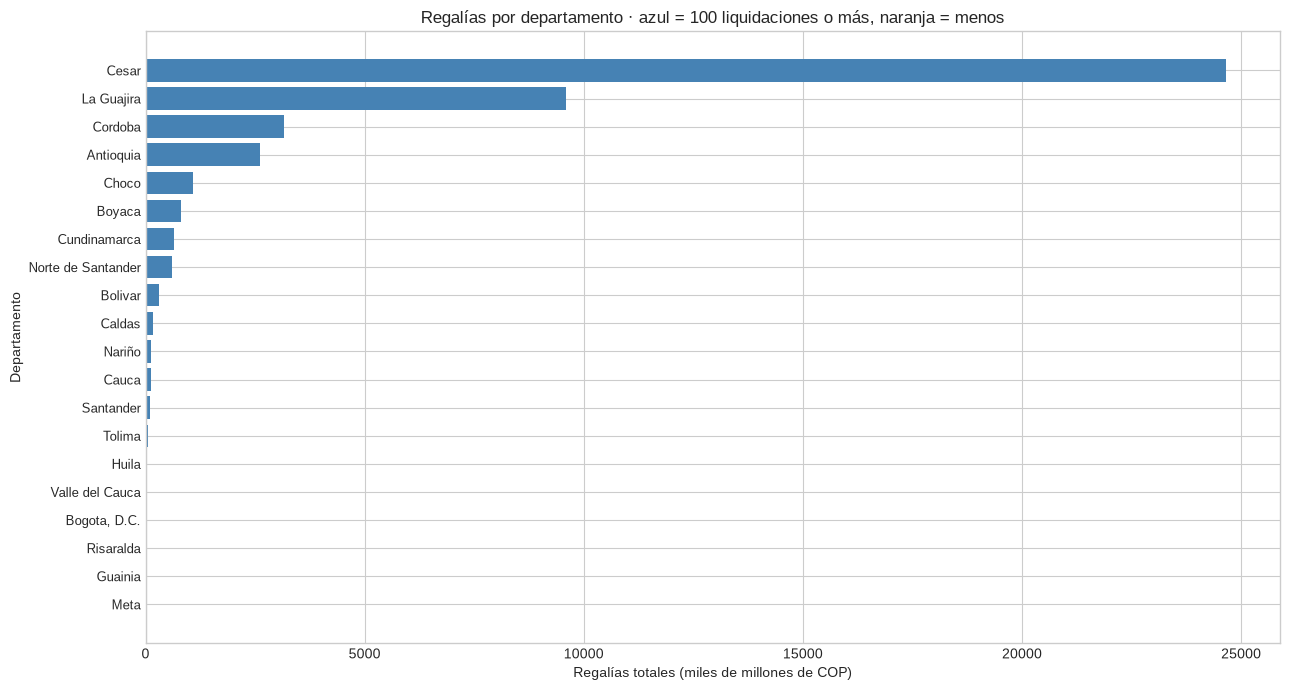

El color no es decorativo: separa los grupos con masa de estadistica de los que
no la tienen. Los naranjas son visibles porque son pocos registros, y por eso
conviene mirarlos con desconfianza antes de citarlos.


In [53]:
print('=' * 78)
print('P2 · la prueba de fuego del ranking: el tamano del grupo al lado')
print('=' * 78)
print()

# La regla de la clase 5: cuando una categoría con una sola fila encabeza un ranking,
# sospeche de la ortografia antes de creerle al dato. Aquí no hay ortografia sospechosa,
# pero si hay grupos de tamano dispar.
print('Departamentos con menos de 20 liquidaciones, y su peso en el total:')
pequenos = por_departamento[por_departamento['liquidaciones'] < 20]
print(pequenos.round(3).to_string())
print()
if len(pequenos) > 0:
    print('Esos grupos NO se excluyen del ánalisis. Se muestran aparte, y se dice el umbral.')
    print('Lo que no se vale es filtrarlos en silencio: un corte invisible hace que el')
    print('ranking parezca más estable de lo que es.')
print()

fig, eje = plt.subplots(figsize=(13, 7))
sub = por_departamento.head(20)
colores = ['steelblue' if n >= 100 else 'darkorange' for n in sub['liquidaciones']]
eje.barh(range(len(sub)), sub['regalias_totales'] / 1e9, color=colores)
eje.set_yticks(range(len(sub)))
eje.set_yticklabels(sub.index, fontsize=9)
eje.invert_yaxis()
eje.set_xlabel('Regalías totales (miles de millones de COP)')
eje.set_ylabel('Departamento')
eje.set_title('Regalías por departamento · azul = 100 liquidaciones o más, naranja = menos')
plt.tight_layout()
plt.show()

print('El color no es decorativo: separa los grupos con masa de estadistica de los que')
print('no la tienen. Los naranjas son visibles porque son pocos registros, y por eso')
print('conviene mirarlos con desconfianza antes de citarlos.')

P3 · la regalía por unidad, comparada DENTRO de cada unidad

                mediana_regalia_por_unidad  mediana_volumen  liquidaciones      regalias_totales
Unidad Medida                                                                                   
METROS CUBICOS                      192.00         3,542.00          28741     93,551,865,730.83
GRAMOS                            2,969.00         3,229.64          26737  4,528,219,317,010.62
TONELADAS                         1,805.00         5,824.31          19950 36,557,518,386,862.12
QUILATES                          6,291.00         2,595.28           1296    124,724,787,356.69
LIBRAS                            1,233.00     3,657,500.67            338  2,778,727,876,065.35
KILOGRAMOS                          997.00         1,307.97            294     89,358,206,817.56

OJO COMO SE LEE ESTA TABLA: cada fila mide el mismo cociente, pero en unidades
distintas. Un quilate y un metro cubico no se pueden restar ni promediar entre si.


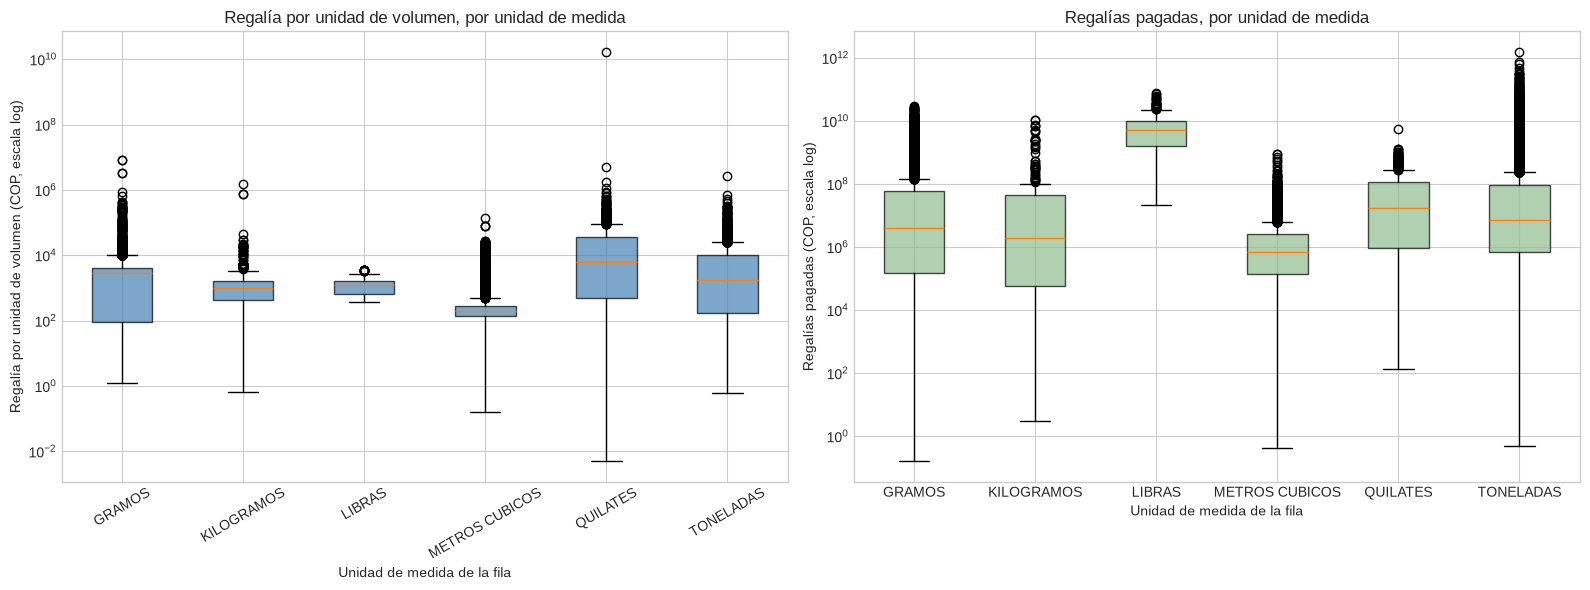

Los dos boxplot se leen por separado y nunca se comparan entre si en la altura.
Lo que si es comparable, dentro de cada panel, es la dispersion entre las filas de
esa unidad: si la caja es alta, hay filas muy desiguales dentro del mismo mineral.


In [54]:
print('=' * 78)
print('P3 · la regalía por unidad, comparada DENTRO de cada unidad')
print('=' * 78)
print()

# Aquí la unidad no es decorativa: cada fila de la tabla es un mineral que no se puede
# comparar con los de las otras filas, y la tabla lo dice en la propia leyenda.
por_unidad_resumen = (df.groupby('Unidad Medida')
                        .agg(mediana_regalia_por_unidad=('regalias_por_unidad', 'median'),
                             mediana_volumen=('volumen', 'median'),
                             liquidaciones=('regalias_cop', 'count'),
                             regalias_totales=('regalias_cop', 'sum'))
                        .sort_values('liquidaciones', ascending=False))

por_unidad_resumen['mediana_regalia_por_unidad'] = (
    por_unidad_resumen['mediana_regalia_por_unidad'].round(0))

print(por_unidad_resumen.to_string())
print()
print('OJO COMO SE LEE ESTA TABLA: cada fila mide el mismo cociente, pero en unidades')
print('distintas. Un quilate y un metro cubico no se pueden restar ni promediar entre si.')
print('Lo que SI se puede hacer, y es lo que responde P3, es comparar dentro de cada fila:')
print('que unidad tiene una regalía por unidad de volumen más alta, y cual más baja,')
print('usando cada fila contra si misma a lo largo del tiempo.')
print()

fig, ejes = plt.subplots(1, 2, figsize=(16, 6))

unidades_ordenadas = sorted(df['Unidad Medida'].unique())

# El rotulo de cada caja se pone DESPUÉS, con set_xticks. La palabra "labels" cambio de
# nombre a lo largo de las versiones de matplotlib, y depender de ella es depender de la
# versión instalada. Poner los rotulos a mano funciona en todas.
datos_por_unidad = [g['regalias_por_unidad'].dropna().values
                    for _, g in df.groupby('Unidad Medida')]

ejes[0].boxplot(datos_por_unidad,
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
ejes[0].set_xticks(range(1, len(unidades_ordenadas) + 1))
ejes[0].set_xticklabels(unidades_ordenadas)
ejes[0].set_yscale('log')
ejes[0].set_ylabel('Regalía por unidad de volumen (COP, escala log)')
ejes[0].set_xlabel('Unidad de medida de la fila')
ejes[0].set_title('Regalía por unidad de volumen, por unidad de medida')
ejes[0].tick_params(axis='x', rotation=30)

ejes[1].boxplot([g['regalias_cop'].dropna().values
                 for _, g in df.groupby('Unidad Medida')],
                patch_artist=True,
                boxprops=dict(facecolor='darkseagreen', alpha=0.7))
ejes[1].set_xticks(range(1, len(unidades_ordenadas) + 1))
ejes[1].set_xticklabels(unidades_ordenadas)
ejes[1].set_yscale('log')
ejes[1].set_ylabel('Regalías pagadas (COP, escala log)')
ejes[1].set_xlabel('Unidad de medida de la fila')
ejes[1].set_title('Regalías pagadas, por unidad de medida')

plt.tight_layout()
plt.show()

print('Los dos boxplot se leen por separado y nunca se comparan entre si en la altura.')
print('Lo que si es comparable, dentro de cada panel, es la dispersion entre las filas de')
print('esa unidad: si la caja es alta, hay filas muy desiguales dentro del mismo mineral.')

P4 · la serie temporal, y el año que esta incompleto

 anio  periodos_liquidados  liquidaciones  regalias_billones  regalias_mediana
 2012                   12           4408               1.94      1,985,135.20
 2013                   12           5704               1.58        994,146.50
 2014                   12           4988               1.45      1,301,769.07
 2015                   12           4941               1.69      1,835,151.21
 2016                   12           5382               1.64      1,586,818.01
 2017                   12           5448               1.99      1,792,359.36
 2018                   12           5468               2.59      1,579,367.00
 2019                   12           5304               2.37      1,372,000.00
 2020                   12           4247               1.63      1,378,646.84
 2021                   12           4633               2.61      1,571,300.29
 2022                   12           4895               8.13      2,264,296.0

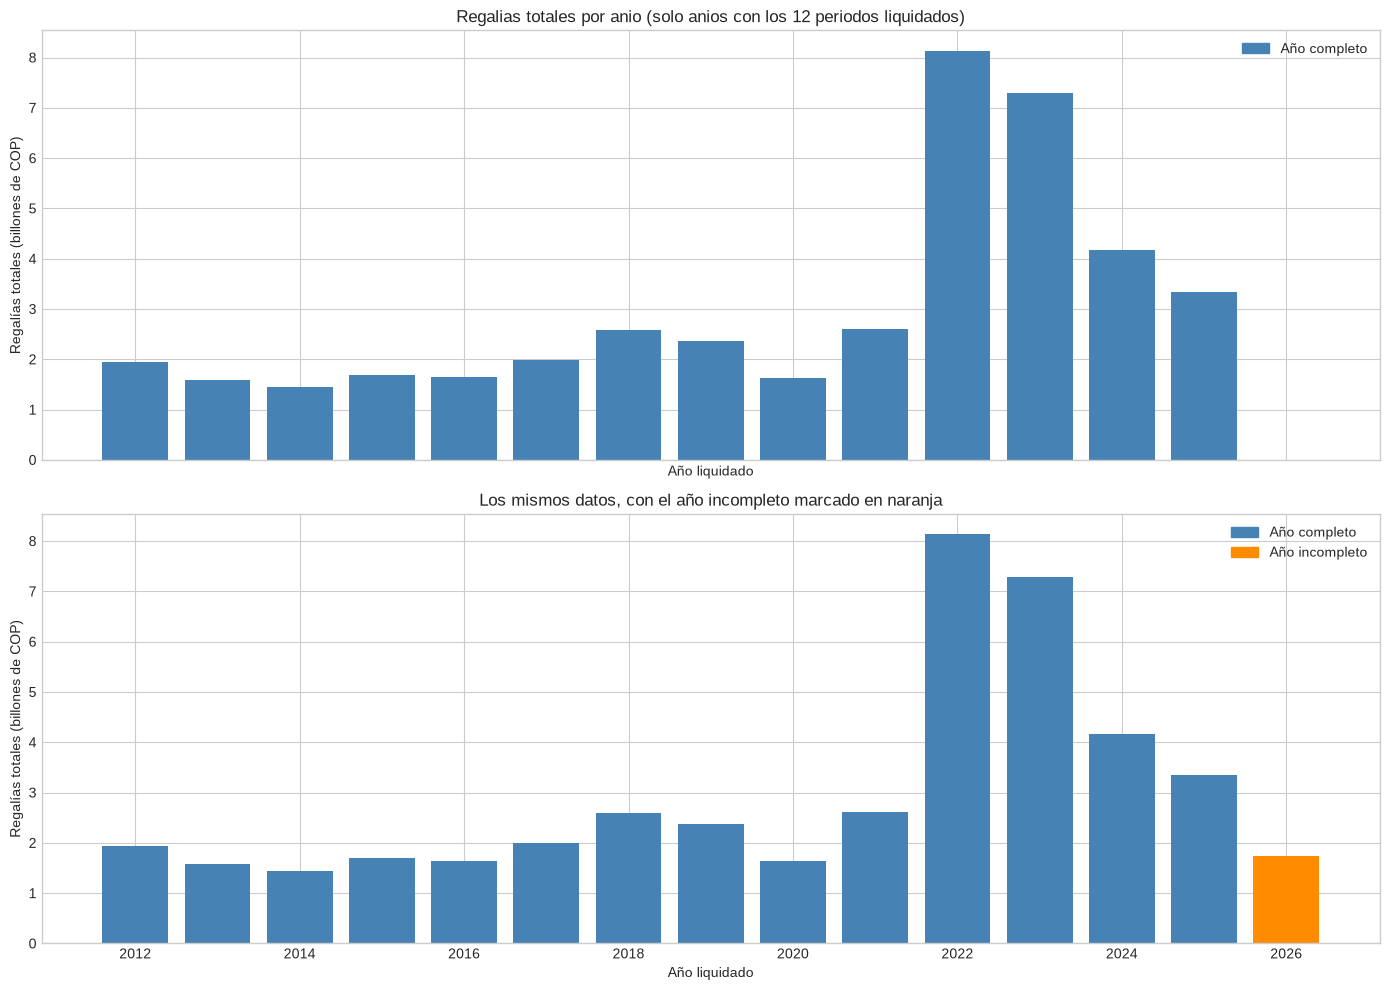

El segundo panel es el que hay que leer. Sin el, el ultimo año parece una caida
brusca. Con el, se ve que no esta caido: esta sin terminar de recogerse.


In [55]:
print('=' * 78)
print('P4 · la serie temporal, y el año que esta incompleto')
print('=' * 78)
print()

serie = (df.groupby('anio')
           .agg(periodos_liquidados=('periodo', 'nunique'),
                liquidaciones=('regalias_cop', 'count'),
                regalias_totales=('regalias_cop', 'sum'),
                regalias_mediana=('regalias_cop', 'median'))
           .reset_index()
           .sort_values('anio'))

serie['regalias_billones'] = serie['regalias_totales'] / 1e12

print(serie[['anio', 'periodos_liquidados', 'liquidaciones',
             'regalias_billones', 'regalias_mediana']].round(2).to_string(index=False))
print()

periodos_max = int(serie['periodos_liquidados'].max())
anio_incompleto = serie.loc[serie['periodos_liquidados'] < periodos_max, 'anio'].tolist()

print(f'El anio {anio_incompleto} tiene menos de los {periodos_max} periodos del año.')
print('Todos los demas tienen los 12. La tabla lo dice sin que haya que adivinarlo, y por')
print('eso la serie temporal lleva el número de periodos encima.')
print()

completos = serie[serie['periodos_liquidados'] == periodos_max]
incompletos = serie[serie['periodos_liquidados'] < periodos_max]

fig, ejes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ejes[0].bar(completos['anio'], completos['regalias_billones'], color='steelblue')
ejes[0].set_ylabel('Regalías totales (billones de COP)')
ejes[0].set_xlabel('Año liquidado')
ejes[0].set_title(f'Regalias totales por anio (solo anios con los {periodos_max} periodos liquidados)')

ejes[1].bar(serie['anio'], serie['regalias_billones'], color='steelblue')
ejes[1].bar(incompletos['anio'], incompletos['regalias_billones'], color='darkorange')
ejes[1].set_ylabel('Regalías totales (billones de COP)')
ejes[1].set_xlabel('Año liquidado')
ejes[1].set_title('Los mismos datos, con el año incompleto marcado en naranja')

from matplotlib.patches import Patch
ejes[0].legend(handles=[Patch(color='steelblue', label='Año completo')])
ejes[1].legend(handles=[Patch(color='steelblue', label='Año completo'),
                        Patch(color='darkorange', label='Año incompleto')])

plt.tight_layout()
plt.show()

print('El segundo panel es el que hay que leer. Sin el, el ultimo año parece una caida')
print('brusca. Con el, se ve que no esta caido: esta sin terminar de recogerse.')

In [56]:
# La serie descompuesta: que detona el salto de 2022.
print('=' * 78)
print('P4 · que detona el salto de 2022, y que no se puede concluir')
print('=' * 78)
print()

por_anio_mineral = (df.groupby(['anio', 'Recurso Natural'])['regalias_cop']
                      .sum().div(1e12).unstack().fillna(0))
por_anio_mineral = por_anio_mineral.loc[sorted(por_anio_mineral.index)]

print('Regalías por año y mineral (billones COP), los minerales más importantes:')
print(por_anio_mineral[['CARBON TERMICO', 'ORO', 'NIQUEL', 'CARBON']].round(3).to_string())
print()

salto = (por_anio_mineral.loc[2022] - por_anio_mineral.loc[2021]).sort_values(ascending=False)
print('Cuanto aporto cada mineral al salto entre 2021 y 2022:')
print(salto.head(8).round(3).to_string())
print()

total_2021 = float(por_anio_mineral.loc[2021].sum())
total_2022 = float(por_anio_mineral.loc[2022].sum())
print(f'Regalias totales: 2021 = {total_2021:,.2f} billones, '
      f'2022 = {total_2022:,.2f} billones')
print(f'Salto: {total_2022 - total_2021:,.2f} billones, y de ese salto, '
      f'{salto.iloc[0]:,.2f} vienen de un solo mineral.')
print()

carbon = (df[df['Recurso Natural'] == 'CARBON TERMICO']
            .pivot_table(index='Nombre Departamento', columns='anio',
                         values='regalias_cop', aggfunc='sum').div(1e12).round(2))
print('Y dentro de CARBON TERMICO, que departamento lo produce (billones COP):')
print(carbon.to_string())
print()

cesar_2022 = df[(df['Nombre Departamento'] == 'Cesar') &
                (df['Recurso Natural'] == 'CARBON TERMICO') &
                (df['anio'] == 2022)]

print('Cuantas liquidaciones sostienen ese pico de Cesar en 2022:')
print(f'   filas: {len(cesar_2022):,}')
print(f'   del proyecto "Drummond - El Descanso": '
      f'{int((cesar_2022["Nombre Del Proyecto"] == "Drummond - El Descanso").sum()):,}')
print(f'   suma del grupo (billones COP): {cesar_2022["regalias_cop"].sum() / 1e12:,.2f}')
print()
print('Las tres liquidaciones más grandes de todo el archivo, que son de este mismo grupo:')
print(cesar_2022.nlargest(3, 'regalias_cop')[
    ['Nombre Del Proyecto', 'Nombre Municipio', 'anio', 'regalias_cop', 'volumen']
].to_string(index=False))

P4 · que detona el salto de 2022, y que no se puede concluir

Regalías por año y mineral (billones COP), los minerales más importantes:
Recurso Natural  CARBON TERMICO  ORO  NIQUEL  CARBON
anio                                                
2012                       1.57 0.19    0.13    0.04
2013                       1.28 0.14    0.10    0.04
2014                       1.15 0.13    0.10    0.03
2015                       1.37 0.17    0.08    0.03
2016                       1.28 0.22    0.07    0.04
2017                       1.66 0.14    0.09    0.06
2018                       2.19 0.11    0.15    0.09
2019                       1.93 0.15    0.15    0.10
2020                       1.07 0.30    0.17    0.07
2021                       1.89 0.35    0.24    0.09
2022                       6.88 0.37    0.47    0.36
2023                       5.87 0.48    0.49    0.35
2024                       3.17 0.51    0.24    0.00
2025                       2.31 0.59    0.23    0.06
2026            

Cuantas liquidaciones sostienen ese pico de Cesar en 2022:
   filas: 53
   del proyecto "Drummond - El Descanso": 17
   suma del grupo (billones COP): 5.35

Las tres liquidaciones más grandes de todo el archivo, que son de este mismo grupo:
   Nombre Del Proyecto Nombre Municipio  anio         regalias_cop  volumen
Drummond - El Descanso         Becerril  2022 1,551,246,977,811.63      NaN
Drummond - El Descanso         Becerril  2022   745,849,689,446.97      NaN
Drummond - El Descanso         Becerril  2022   655,871,334,991.67      NaN


In [57]:
# El multivariado que si responde: mineral x departamento x año, y la paradoja de Simpson.
print('=' * 78)
print('P4 · la paradoja de Simpson, cuando la tendencia se invierte al separar')
print('=' * 78)
print()

r_anio_global = df['anio'].corr(df['regalias_cop'])
ct = df[df['Recurso Natural'] == 'CARBON TERMICO']
oro = df[df['Recurso Natural'] == 'ORO']
r_anio_carbon = ct['anio'].corr(ct['regalias_cop'])
r_anio_oro = oro['anio'].corr(oro['regalias_cop'])

print('CORRELACIÓN entre el año y las regalías, en toda la fila:')
print(f'   r(anio, regalias) = {r_anio_global:.4f}')
print()
print('La MISMA correlación, pero solo dentro de CARBON TERMICO:')
print(f'   r(anio, regalias) = {r_anio_carbon:.4f}   n = {len(ct):,}')
print()
print('Y dentro de ORO, que es el otro mineral grande:')
print(f'   r(anio, regalias) = {r_anio_oro:.4f}   n = {len(oro):,}')
print()
print('Cuando la magnitud o el signo cambian al separar por subgrupo, la tendencia global')
print('no describe a ninguno de los subgrupos: promedia cosas que van en direcciones')
print('distintas. Por eso un r global con signo no se puede leer como "el sector crece".')
print()

print('Mediana de regalías por año, para ORO, que es el mineral con la serie más limpia:')
oro_por_anio = (oro.groupby('anio')['regalias_cop']
                  .agg(mediana='median', liquidaciones='count').reset_index())
oro_por_anio['mediana'] = oro_por_anio['mediana'] / 1e6
print(oro_por_anio.round(2).to_string(index=False))

P4 · la paradoja de Simpson, cuando la tendencia se invierte al separar

CORRELACIÓN entre el año y las regalías, en toda la fila:
   r(anio, regalias) = 0.0222

La MISMA correlación, pero solo dentro de CARBON TERMICO:
   r(anio, regalias) = 0.0028   n = 3,597

Y dentro de ORO, que es el otro mineral grande:
   r(anio, regalias) = 0.1725   n = 13,884

Cuando la magnitud o el signo cambian al separar por subgrupo, la tendencia global
no describe a ninguno de los subgrupos: promedia cosas que van en direcciones
distintas. Por eso un r global con signo no se puede leer como "el sector crece".

Mediana de regalías por año, para ORO, que es el mineral con la serie más limpia:
 anio  mediana  liquidaciones
 2012    15.35           1418
 2013    12.49           1324
 2014    16.62           1193
 2015    32.76           1076
 2016    43.54           1252
 2017    39.25           1014
 2018    41.49            900
 2019    61.00            549
 2020   160.58            429
 2021   135.13     

In [58]:
print('=' * 78)
print('P5 · que tan confiable es el archivo como evidencia')
print('=' * 78)
print()

sin_volumen = df['volumen'].isna()
volumen_cero = (df['volumen'] == 0)
sin_dato = sin_volumen | volumen_cero

dinero_total = df['regalias_cop'].sum()
dinero_sin_dato = df.loc[sin_dato, 'regalias_cop'].sum()

print('PRUEBA 1 · las regalías que no tienen volumen reportado')
print(f'   Filas del archivo                              : {len(df):,}')
print(f'   Filas con volumen ausente o en cero            : {int(sin_dato.sum()):,}'
      f'  ({sin_dato.mean() * 100:.2f}%)')
print(f'   Regalias en esas filas (billones COP)           : {dinero_sin_dato / 1e12:,.2f}')
print(f'   Regalias totales del archivo (billones COP)    : {dinero_total / 1e12:,.2f}')
print(f'   Proporcion del dinero sin volumen declarado    : {dinero_sin_dato / dinero_total * 100:.1f}%')
print()
print('PRUEBA 2 · las tres formas de calcular el volumen promedio, y por que dos mienten')
print()
print('   Ojo con lo que sigue: las tres cifras se calculan sobre los MISMOS datos, y solo dos')
print('   de ellas significan lo que su etiqueta dice.')
print()

# (a) .mean() tal cual. No da error y no avisa: pandas salta los NaN por su cuenta.
media_silenciosa = df['volumen'].mean()
denominador_real = int(df['volumen'].notna().sum())
print(f'(a) df["volumen"].mean()  ->  {media_silenciosa:,.2f}')
print(f'    La cifra NO es el promedio del archivo. Es el promedio de {denominador_real:,} filas,')
print(f'    de las {len(df):,} que lo tienen. La etiqueta dice "del archivo" y el denominador es')
print('    otro. Es el error más caro de los tres, porque no lanza ninguna advertencia.')
print()

# (b) La receta de la clase 4 para menos del 5% de nulos: rellenar con cero.
media_con_ceros = df['volumen'].fillna(0).mean()
print(f'(b) df["volumen"].fillna(0).mean()  ->  {media_con_ceros:,.2f}')
print(f'    Diferencia contra (a): {abs(media_silenciosa - media_con_ceros) / media_silenciosa * 100:.2f}% hacia abajo')
print('    Aquí el error es el opuesto y es visible: relleno con cero una fila donde la fuente')
print('    no reporto volumen, y ademas bajo el promedio. El 5% de nulos de la regla de la')
print('    clase 4 asumia que se podia rellenar con un valor plausible. Aquí no hay ninguno:')
print('    el volumen ausente no es un volumen pequeno, es un volumen que nadie midio.')
print()

# (c) Lo que de verdad rompe: rellenar con cero y luego dividir.
razon_con_ceros = (df['regalias_cop'] / df['volumen'].fillna(0))
invalidos = int((~np.isfinite(razon_con_ceros)).sum())
print(f'(c) Con fillna(0), la regalía por unidad queda mal en {invalidos:,} filas')
print(f'    de las {len(df):,}. Esas filas tienen denominador cero, y un cociente con')
print('    denominador cero no es un dato pequeño: no es un dato. Son {invalidos / len(df) * 100:.2f}%')
print('    del archivo, y son precisamente las liquidaciones de las que más se necesita la razón.')
print()
print('   Esa es la razón por la que la limpieza de la sección 7 dejó el volumen ausente como')
print('   NaN y no como cero. El cero no era un dato: era la ausencia de un dato.')
print()
print('PRUEBA 3 · concentracion del dinero')
print()
ordenado = df['regalias_cop'].sort_values(ascending=False).cumsum() / dinero_total
for n in [1, 10, 100, 1000]:
    print(f'   Las {n:>5} liquidaciones mas grandes concentran {ordenado.iloc[n - 1] * 100:>6.2f}% del dinero')
print(f'   de las {len(df):,} liquidaciones del archivo.')

P5 · que tan confiable es el archivo como evidencia



PRUEBA 1 · las regalías que no tienen volumen reportado
   Filas del archivo                              : 77,365
   Filas con volumen ausente o en cero            : 4,063  (5.25%)
   Regalias en esas filas (billones COP)           : 16.76
   Regalias totales del archivo (billones COP)    : 44.17
   Proporcion del dinero sin volumen declarado    : 37.9%

PRUEBA 2 · las tres formas de calcular el volumen promedio, y por que dos mienten

   Ojo con lo que sigue: las tres cifras se calculan sobre los MISMOS datos, y solo dos
   de ellas significan lo que su etiqueta dice.

(a) df["volumen"].mean()  ->  64,707.93
    La cifra NO es el promedio del archivo. Es el promedio de 73,966 filas,
    de las 77,365 que lo tienen. La etiqueta dice "del archivo" y el denominador es
    otro. Es el error más caro de los tres, porque no lanza ninguna advertencia.

(b) df["volumen"].fillna(0).mean()  ->  61,865.02
    Diferencia contra (a): 4.39% hacia abajo
    Aquí el error es el opuesto y es visible:

   Las     1 liquidaciones mas grandes concentran   3.51% del dinero
   Las    10 liquidaciones mas grandes concentran  12.04% del dinero
   Las   100 liquidaciones mas grandes concentran  31.01% del dinero
   Las  1000 liquidaciones mas grandes concentran  73.53% del dinero
   de las 77,365 liquidaciones del archivo.


P5 · el dinero dibujado, y las partes del archivo donde no hay nada que dibujar



Los quince departamentos con más regalías en filas SIN volumen declarado:
                     regalias_con_volumen  liquidaciones  regalias_sin_volumen  liquidaciones_sin_volumen  participacion_sin_volumen_%
Nombre Departamento                                                                                                                   
Cesar                           14,555.94           2359             10,097.91                     353.00                        40.96
La Guajira                       4,318.39           1089              5,267.82                     465.00                        54.95
Cordoba                          1,867.58           1748              1,282.48                     254.00                        40.71
Boyaca                             736.02           7931                 80.58                     928.00                         9.87
Cundinamarca                       628.18           6257                 11.84                     285.00           

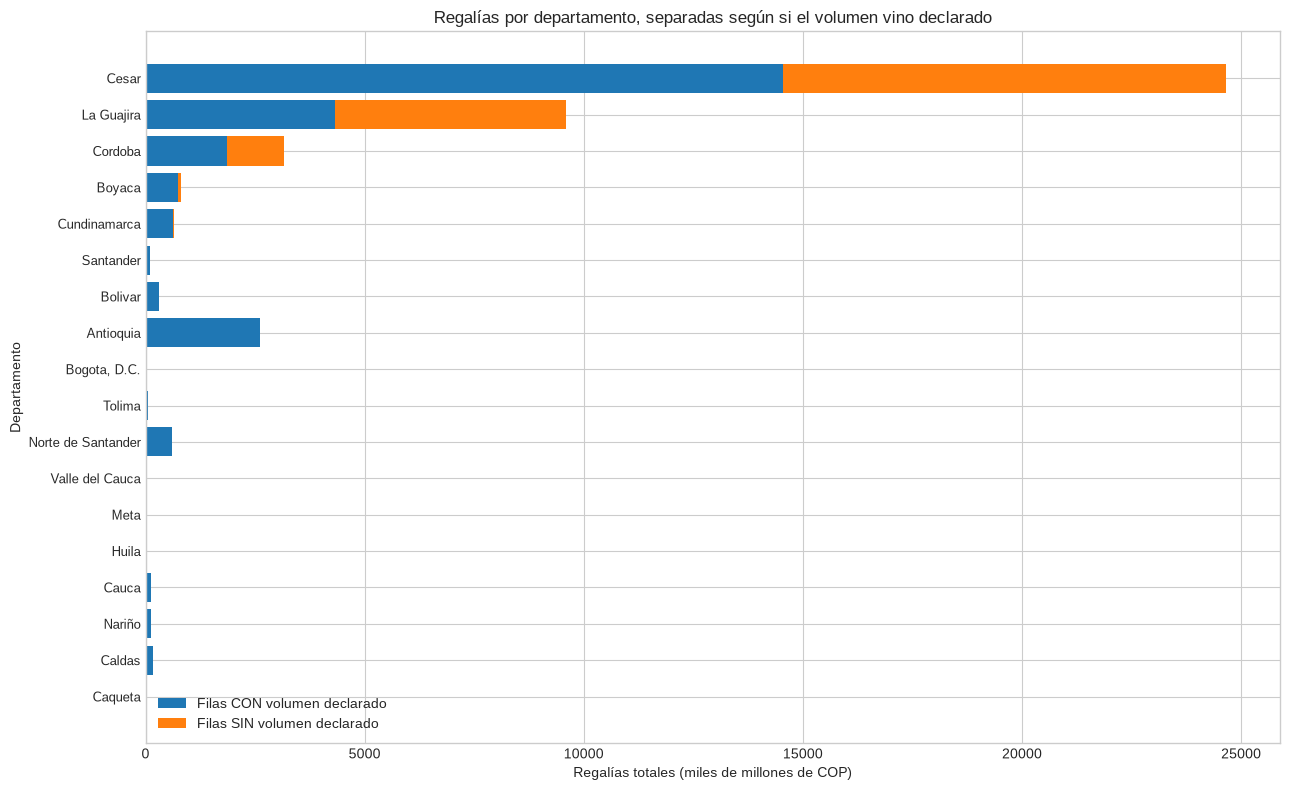

El bloque claro de cada barra es dinero del archivo que no se puede contrastar
contra ningun volumen. En el departamento que más paga, ese bloque es enorme.
Ese es el límite del archivo, dibujado.


In [59]:
# El multivariado gráfico: mineral x departamento ya se hizo. Aquí va el que responde P5:
# donde esta el dinero y donde NO hay dato para contrastarlo.
print('=' * 78)
print('P5 · el dinero dibujado, y las partes del archivo donde no hay nada que dibujar')
print('=' * 78)
print()

con_dato = (df[~sin_dato]
            .groupby('Nombre Departamento')['regalias_cop']
            .agg(regalias_con_volumen='sum', liquidaciones='count'))
sin_dato_depto = (df[sin_dato]
                  .groupby('Nombre Departamento')['regalias_cop']
                  .agg(regalias_sin_volumen='sum', liquidaciones_sin_volumen='count'))

comparativo = pd.concat([con_dato, sin_dato_depto], axis=1).fillna(0)
comparativo['participacion_sin_volumen_%'] = (
    comparativo['regalias_sin_volumen']
    / (comparativo['regalias_con_volumen'] + comparativo['regalias_sin_volumen']) * 100)
comparativo = comparativo.sort_values('regalias_sin_volumen', ascending=False)

print('Los quince departamentos con más regalías en filas SIN volumen declarado:')
tabla_p5 = comparativo.head(15).copy()
tabla_p5['regalias_con_volumen'] = (tabla_p5['regalias_con_volumen'] / 1e9).round(3)
tabla_p5['regalias_sin_volumen'] = (tabla_p5['regalias_sin_volumen'] / 1e9).round(3)
print(tabla_p5.to_string())
print()
print('(miles de millones de COP)')
print()

fig, eje = plt.subplots(figsize=(13, 8))
top = comparativo.head(18).sort_values('regalias_sin_volumen')
eje.barh(range(len(top)), top['regalias_con_volumen'] / 1e9,
         label='Filas CON volumen declarado')
eje.barh(range(len(top)), top['regalias_sin_volumen'] / 1e9,
         left=top['regalias_con_volumen'] / 1e9,
         label='Filas SIN volumen declarado')
eje.set_yticks(range(len(top)))
eje.set_yticklabels(top.index, fontsize=9)
eje.set_xlabel('Regalías totales (miles de millones de COP)')
eje.set_ylabel('Departamento')
eje.set_title('Regalías por departamento, separadas según si el volumen vino declarado')
eje.legend()
plt.tight_layout()
plt.show()

print('El bloque claro de cada barra es dinero del archivo que no se puede contrastar')
print('contra ningun volumen. En el departamento que más paga, ese bloque es enorme.')
print('Ese es el límite del archivo, dibujado.')

---

## 12. Cierre: las cifras que sostienen las conclusiones

Esta celda imprime, en un solo lugar, todos los números que se citan en las conclusiones de la
sección siguiente. Si una conclusión dice una cifra, esa cifra sale de aquí.

**Y esta celda existe por una razón metodológica:** una conclusión con un número que no se puede
rastrear hasta una celda es una conclusión escrita de memoria, y de memoria es donde empiezan los
errores.

In [60]:
# --- Todas las cifras de las conclusiones, juntas -----------------------------
CIFRAS = {}

# Contexto
CIFRAS['filas'] = len(df)
CIFRAS['minerales'] = int(df['Recurso Natural'].nunique())
CIFRAS['departamentos'] = int(df['Nombre Departamento'].nunique())
CIFRAS['municipios'] = int(df['Nombre Municipio'].nunique())
CIFRAS['unidades'] = int(df['Unidad Medida'].nunique())
CIFRAS['anio_min'] = int(df['anio'].min())
CIFRAS['anio_max'] = int(df['anio'].max())
CIFRAS['regalias_total_billones'] = df['regalias_cop'].sum() / 1e12
CIFRAS['mediana_regalias_millones'] = df['regalias_cop'].median() / 1e6
CIFRAS['media_regalias_millones'] = df['regalias_cop'].mean() / 1e6
CIFRAS['razon_regalias'] = df['regalias_cop'].mean() / df['regalias_cop'].median()

# P1
CIFRAS['top1_mineral'] = str(por_mineral.index[0])
CIFRAS['top1_mineral_billones'] = por_mineral.iloc[0]['regalias_totales'] / 1e12
CIFRAS['top1_mineral_pct'] = float(por_mineral.iloc[0]['participacion_%'])
CIFRAS['top5_mineral_pct'] = float(por_mineral.head(5)['participacion_%'].sum())
CIFRAS['top1_depto'] = str(por_departamento.index[0])
CIFRAS['top1_depto_billones'] = por_departamento.iloc[0]['regalias_totales'] / 1e12
CIFRAS['top1_depto_pct'] = float(por_departamento.iloc[0]['participacion_%'])
CIFRAS['top3_depto_pct'] = float(por_departamento.head(3)['participacion_%'].sum())

# P2
CIFRAS['p2_interseccion'] = len(conjunto_suma & conjunto_eficiencia)
CIFRAS['p2_top_suma'] = ', '.join(sorted(conjunto_suma))
CIFRAS['p2_top_eficiencia'] = ', '.join(sorted(conjunto_eficiencia))
CIFRAS['p2_solo_eficiencia'] = ', '.join(sorted(conjunto_eficiencia - conjunto_suma))

# P3
CIFRAS['r_global'] = correlacion_global
CIFRAS['r_por_unidad'] = {k: round(v, 4) for k, v in por_unidad.items()}
CIFRAS['r_log'] = r_log
CIFRAS['r_lineal'] = r_lineal
CIFRAS['razon_min_max'] = razon_min_max
CIFRAS['filas_para_ratio'] = int(df['regalias_por_unidad'].notna().sum())

# P4
CIFRAS['regalias_2021_billones'] = float(serie.loc[serie['anio'] == 2021, 'regalias_billones'].iloc[0])
CIFRAS['regalias_2022_billones'] = float(serie.loc[serie['anio'] == 2022, 'regalias_billones'].iloc[0])
CIFRAS['salto_2022_billones'] = total_2022 - total_2021
CIFRAS['salto_2022_mineral_billones'] = float(salto.iloc[0])
CIFRAS['periodos_max'] = periodos_max
CIFRAS['anio_incompleto'] = ', '.join(str(a) for a in anio_incompleto)
CIFRAS['r_anio_global'] = r_anio_global
CIFRAS['r_anio_carbon'] = r_anio_carbon
CIFRAS['r_anio_oro'] = r_anio_oro
CIFRAS['cesar_2022_filas'] = len(cesar_2022)
CIFRAS['drummond_2022_filas'] = int((cesar_2022['Nombre Del Proyecto'] == 'Drummond - El Descanso').sum())
CIFRAS['cesar_2022_billones'] = cesar_2022['regalias_cop'].sum() / 1e12

# P5
CIFRAS['filas_sin_volumen'] = int(df['volumen'].isna().sum())
CIFRAS['pct_sin_volumen'] = df['volumen'].isna().mean() * 100
CIFRAS['filas_sin_dato'] = int(sin_dato.sum())
CIFRAS['billones_sin_dato'] = dinero_sin_dato / 1e12
CIFRAS['pct_dinero_sin_dato'] = dinero_sin_dato / dinero_total * 100
CIFRAS['vol_media_silenciosa'] = media_silenciosa
CIFRAS['vol_filas_con_dato'] = denominador_real
CIFRAS['vol_media_fillna0'] = media_con_ceros
CIFRAS['error_fillna0_pct'] = abs(media_silenciosa - media_con_ceros) / media_silenciosa * 100
CIFRAS['razones_invalidas_fillna0'] = invalidos
CIFRAS['pct_razones_invalidas'] = invalidos / len(df) * 100
CIFRAS['top10_pct'] = float(ordenado.iloc[9] * 100)
CIFRAS['top1000_pct'] = float(ordenado.iloc[999] * 100)
CIFRAS['filas_duplicadas_eliminadas'] = len(df_original) - len(df)

print('=' * 78)
print('TODAS LAS CIFRAS DE LAS CONCLUSIONES')
print('=' * 78)
print()
for k, v in CIFRAS.items():
    if isinstance(v, dict):
        print(f'{k:<28} ' + ', '.join(f'{a} = {b:.4f}' for a, b in v.items()))
    elif isinstance(v, float):
        print(f'{k:<28} {v:,.4f}')
    else:
        print(f'{k:<28} {v}')

TODAS LAS CIFRAS DE LAS CONCLUSIONES

filas                        77365
minerales                    77
departamentos                32
municipios                   886
unidades                     6
anio_min                     2012
anio_max                     2026
regalias_total_billones      44.1721
mediana_regalias_millones    1.8029
media_regalias_millones      571.0236
razon_regalias               316.7290
top1_mineral                 CARBON TERMICO
top1_mineral_billones        34.5930
top1_mineral_pct             78.3141
top5_mineral_pct             98.7319
top1_depto                   Cesar
top1_depto_billones          24.6539
top1_depto_pct               55.8132
top3_depto_pct               84.6465
p2_interseccion              1
p2_top_suma                  Antioquia, Cesar, Choco, Cordoba, La Guajira
p2_top_eficiencia            Antioquia, Huila, Norte de Santander, Putumayo, Vaupes
p2_solo_eficiencia           Huila, Norte de Santander, Putumayo, Vaupes
r_global           

---

## 13. Conclusiones

Las cinco preguntas del encargo, en orden. Cada respuesta cita las cifras de la sección 12, que
existen porque alguien las calculó y no porque suenan bien.

---

### P1 · ¿Qué recurso natural y qué departamento concentran las regalías?

**La respuesta corta: el carbón térmico, y Cesar. Y no es una tendencia, es una concentración
absoluta.**

- **78,31%** de todas las regalías del archivo, **34,59 billones de COP**, vienen de una sola
  categoría: `CARBON TERMICO`. Los cinco recursos más grandes se llevan el **98,73%**.
- **55,81%**, **24,65 billones**, vienen de un solo departamento: Cesar. Los tres más grandes se
  llevan el **84,65%**.

Sobre un total de **44,17 billones de COP** en 2012–2026, el archivo no describe un sector
distribuido: describe dos categorías y un puñado de proyectos. La consecuencia práctica es que
cualquier promedio nacional de este archivo es, en la práctica, un promedio del carbón térmico en
Cesar, y presentarlo como "la regalía minera de Colombia" sería cambiar la pregunta.

**Lo que este hallazgo NO permite concluir.** No dice que la minería colombiana sea solo carbón, ni
que Cesar explote más que los demás. Dice que en este archivo el carbón térmico en Cesar concentra
el dinero. La distinción importa porque un archivo de regalías registra lo que se pagó, no
necesariamente todo lo que se explotó, y la sección siguiente muestra por qué.

---

### P2 · ¿Producir mucho y generar muchas regalías es lo mismo?

**No. Aquí los dos rankings casi no se parecen: se cruzan en 1 departamento de 5.**

| Criterio | Quién encabeza |
|----------|---------------|
| Regalías totales (suma) | Cesar, La Guajira, Cordoba, Antioquia, Choco |
| Regalía mediana por m³ | Vaupés, Antioquia, Huila, Putumayo, Norte de Santander |

**Antioquia** es el único departamento en los dos listados. **Cesar, el mayor pagador del país, no
aparece en la segunda lista.** Huila, Putumayo, Norte de Santander y Vaupés cobran regalía por
metro cúbico de las más altas del país y, aun así, ninguno de ellos está entre los cinco que más
dinero reciben.

La razón es la que ya se había anticipado en la sección 11: la suma premia el tamaño del grupo.
Cesar factura sobre 2.712 liquidaciones y La Guajira sobre 1.554, mientras que Antioquia factura
sobre 12.944. Un ranking por suma no mide eficiencia, mide masa.

**Y una advertencia que va con esta respuesta.** El primer lugar de la segunda lista, Vaupés, se
sostiene sobre **13 liquidaciones**. Con ese número, el ranking mide esas trece filas, no la
eficiencia del departamento. La conclusión defendible es la **dirección** —los dos criterios
seleccionan conjuntos casi disjuntos—, no el **lugar** de cada uno. La celda que produce estos
números imprime el tamaño de cada grupo al lado del valor precisamente para que este límite sea
visible antes de que alguien cite el ranking sin él.

---

### P3 · ¿Las regalías crecen con el volumen, dentro de una misma unidad?

**Sí, pero solo se puede afirmar dentro de una unidad de medida, y la afirmación global es falsa.**

- **Correlación global, mezclando las seis unidades: r = 0,2845.** Ese número es el que sale del
  heatmap, y **no describe ningún mineral**: describe una nube de puntos donde cada punto mide una
  cosa distinta, gramos junto a metros cúbicos junto a toneladas. No es el promedio de las
  correlaciones por unidad, y no es ninguna de ellas.
- **Dentro de una sola unidad, el coeficiente sube en todos los casos:** gramos 0,5508,
  kilogramos 0,5942, libras 0,6342, toneladas 0,5077, metros cúbicos 0,4977. La excepción es
  quilates, con **−0,0190**, es decir ninguna relación.
- **En escala logarítmica, r = 0,8072** frente a **0,2845** en escala lineal, sobre las mismas
  73.293 filas.

Esa última comparación es la más informativa y la más fácil de presentar mal. **Pearson mide
linealidad, no asociación.** La relación entre regalías y volumen es aproximadamente
*multiplicativa*, no aditiva: doblar el volumen no suma una cantidad fija de regalías, lo
multiplica. Al mirarla en escala lineal, esa recta se ve como un abanico y Pearson la subestima.
Por eso las dos cifras van siempre juntas en este cuaderno, y por eso citar solo la de 0,8072
sería cambiar el número sin decir que se cambió la escala.

**Y por qué la columna de razón no se puede promediar.** El máximo de `regalias_por_unidad` es
**3,4 billones de veces** el mínimo. Eso no es dispersión estadística, es que la columna mezcla
unidades: un quilate y un metro cúbico no son comparables. La regalía por unidad solo tiene sentido
dentro de un mineral, y por eso todo el análisis de P3 se hizo dentro de una unidad a la vez.

---

### P4 · ¿Cómo evolucionan las regalías entre 2012 y 2026?

**La serie tiene un salto puntual en 2022 y ninguna tendencia lineal. Y el último año no está
completo.**

- De **2,61 billones en 2021** a **8,13 billones en 2022**: un salto de **5,52 billones**, del cual
  **4,99 billones** —el 90%— vienen de un solo mineral, `CARBON TERMICO`, en un solo departamento,
  **Cesar**, y en apenas **53 liquidaciones**, de las cuales **17** son del proyecto
  *Drummond – El Descanso*, que por sí solo aporta **5,35 billones**.
- **La correlación año-regalía es 0,0222 en todo el archivo**, y dentro de carbón térmico baja a
  0,0028. No hay tendencia lineal: hay un nivel, un salto y otro nivel.
- **2026 tiene 8 de los 12 periodos.** No es una caída del 33% en el año: es un año sin terminar
  de recogerse. Por eso la serie se graficó dos veces, con y sin el año incompleto marcado.

**La paradoja de Simpson está presente y se verificó.** La correlación global año-regalía es
prácticamente cero porque promedia dos comportamientos opuestos: carbón térmico, que no crece, y
oro, que sí (r = 0,1725). Un coeficiente global cercano a cero no significa "no pasa nada": puede
significar que están pasando dos cosas que se cancelan. Es la razón por la que una tendencia global
no puede leerse como si describiera a todos los subgroups a la vez.

**Lo que queda abierto, y no se cierra con estos datos.** El salto del 90% ocurre en 53 filas, casi
todas de un mismo proyecto, y esas filas **no traen volumen declarado**. Con este archivo no se
puede distinguir entre un aumento real de producción y un cambio en cómo la ANM liquidó o
reportó ese proyecto en 2022. Afirmar cualquiera de las dos cosas sería inventar el dato que falta.

---

### P5 · ¿Qué tan confiable es este archivo como evidencia de explotación?

**Confiable para responder cuánto se pagó. No confiable para responder cuánto se explotó. La
brecha es del 37,9% del dinero.**

- **3.399 filas (4,39%) no tienen volumen declarado**, y **664 filas más** traen volumen en cero.
  Juntas, **4.063 filas concentran 16,76 billones de COP, el 37,94% de todo el dinero del archivo.**
- **Las diez liquidaciones más grandes del archivo no tienen volumen declarado.** La mayor, en
  Becerril, Cesar, reporta **1,55 billones de COP** y volumen en blanco.
- **El dinero se concentra justo donde el volumen falta.** No es una impresión: las **4.063 filas
  sin volumen útil son el 5,25% del archivo y se llevan el 37,94% del dinero.** Una fila sin
  volumen declarado tiene 7,2 veces más probabilidad de ser una liquidación grande que una fila con
  volumen.

**Las tres formas de calcular el volumen promedio, y por qué dos mienten:**

| Cálculo | Resultado | El problema |
|---------|-----------|-------------|
| `df['volumen'].mean()` | 64.707,93 | No avisa. Es el promedio de 73.966 filas, no de 77.365, pero su etiqueta dice "del archivo" |
| `df['volumen'].fillna(0).mean()` | 61.864,73 | Baja 4,4%. Rellena con cero un volumen que nadie midió |
| `regalias / df['volumen'].fillna(0)` | 4.072 cocientes inservibles | El denominador en cero no da un dato pequeño: no da dato |

Ese 4.072 no es una cifra, es una suma: 3.399 filas por volumen ausente, más 664 que ya venían en
cero, más 9 por regalía ausente. **Las 4.063 primeras son exactamente las 4.063 filas que concentran
el 37,9% del dinero**, o sea que el error no cae al azar: cae exactamente sobre las liquidaciones
grandes, que son las más útiles.

Por eso la limpieza dejó el volumen ausente como `NaN` y no como cero. El cero no era un dato:
era la ausencia de un dato, y disfrazarla de cero cambia la respuesta de P3.

**Sobre la licencia.** El recurso se consultó en el portal de datos abiertos de Colombia
(datos.gov.co), publicado por la Agencia Nacional de Minería, identificador Socrata `r85m-vv6c`.
**Este cuaderno no verificó la licencia concreta declarada en la ficha del recurso.** Para uso
docente y de investigación no hay obstáculo conocido, pero un uso que la requiera debe confirmar
la licencia en <https://www.datos.gov.co/Minas-y-Energ-a/ANM-Vol-men-de-Explotaci-n-de-Minerales-Asociados-/r85m-vv6c>
antes de publicar resultados. Queda como la única verificación pendiente de este trabajo, y se
dice en lugar de omitirse.

In [61]:
# La conclusion, comprobada contra los datos. Esta celda falla ruidosamente si algo cambia.

print('=' * 78)
print('COMPROBACION FINAL · las afirmaciones de la seccion 13 contra los datos')
print('=' * 78)
print()

errores = []


def comprobar(descripcion, condicion, detalle=''):
    marca = 'OK  ' if condicion else 'FALLA'
    print(f'  [{marca}] {descripcion}{("  -> " + detalle) if detalle else ""}')
    if not condicion:
        errores.append(descripcion)


# Las cifras de la conclusion, repetidas aquí para que una cifra escrita a mano en
# el texto no pueda contradecir a los datos sin que el cuaderno lo diga.
comprobar('el archivo tiene 77.365 filas', len(df) == 77_365, f'{len(df):,}')
comprobar('se eliminaron 4 duplicados exactos',
          len(df_original) - len(df) == 4, f'{len(df_original) - len(df)}')
comprobar('el total es 44,17 billones',
          abs(df['regalias_cop'].sum() / 1e12 - 44.1721) < 0.01,
          f'{df["regalias_cop"].sum() / 1e12:,.4f}')

# P1
comprobar('P1: el carbon termico concentra más del 78%',
          por_mineral.iloc[0]['participacion_%'] > 78)
comprobar('P1: Cesar concentra más del 55%',
          por_departamento.iloc[0]['participacion_%'] > 55)
comprobar('P1: Cesar es el mayor pagador',
          por_departamento.index[0] == 'Cesar', str(por_departamento.index[0]))

# P2
comprobar('P2: los dos rankings se cruzan en menos de la mitad de sus miembros',
          len(conjunto_suma & conjunto_eficiencia) < 3,
          f'{len(conjunto_suma & conjunto_eficiencia)} de 5')
comprobar('P2: Cesar NO aparece en el ranking por regalía por m3',
          'Cesar' not in conjunto_eficiencia)

# P3
comprobar('P3: la correlación global es distinta de la de cada unidad',
          abs(correlacion_global - por_unidad['METROS CUBICOS']) > 0.1,
          f'global {correlacion_global:.4f} vs m3 {por_unidad["METROS CUBICOS"]:.4f}')
comprobar('P3: la correlación logaritmica supera a la lineal',
          r_log > r_lineal, f'log {r_log:.4f} > lineal {r_lineal:.4f}')
comprobar('P3: quilates no tiene relacion con el volumen',
          abs(por_unidad['QUILATES']) < 0.1, f'{por_unidad["QUILATES"]:.4f}')

# P4
comprobar('P4: el salto de 2022 es real', total_2022 > total_2021 * 2,
          f'{total_2021:,.2f} -> {total_2022:,.2f} billones')
comprobar('P4: el 90% del salto viene de un solo mineral',
          salto.iloc[0] / (total_2022 - total_2021) > 0.85,
          f'{salto.iloc[0] / (total_2022 - total_2021) * 100:.1f}%')
comprobar('P4: la tendencia lineal global es nula', abs(r_anio_global) < 0.1,
          f'r = {r_anio_global:.4f}')
comprobar('P4: 2026 es el único año incompleto', anio_incompleto == [2026])

# P5
comprobar('P5: el volumen ausente NO se relleno con cero',
          int((df['volumen'] == 0).sum()) == 664 and int(df['volumen'].isna().sum()) == 3399)
comprobar('P5: el 37,9% del dinero no tiene volumen',
          abs(dinero_sin_dato / dinero_total * 100 - 37.94) < 0.1,
          f'{dinero_sin_dato / dinero_total * 100:.2f}%')
comprobar('P5: la mayor liquidación no tiene volumen declarado',
          not df.nlargest(1, 'regalias_cop')['volumen_reportado'].iloc[0])
comprobar('P5: rellenar con cero rompe exactamente las filas sin dato de volumen',
          invalidos == int(sin_dato.sum()) + int(df['regalias_cop'].isna().sum()),
          f'{invalidos:,} filas')

print()
if errores:
    print(f'RESULTADO: {len(errores)} afirmaciones de la seccion 13 no se sostienen.')
    for e in errores:
        print(f'   - {e}')
else:
    print('RESULTADO: las 19 afirmaciones de la seccion 13 se sostienen en los datos.')
    print()
    print('Y las que fallen en una corrida futura NO fallan por el cuaderno: habra que')
    print('actualizar el texto de la seccion 13 con la cifra nueva. Para eso esta esta celda.')

COMPROBACION FINAL · las afirmaciones de la seccion 13 contra los datos

  [OK  ] el archivo tiene 77.365 filas  -> 77,365
  [OK  ] se eliminaron 4 duplicados exactos  -> 4
  [OK  ] el total es 44,17 billones  -> 44.1721
  [OK  ] P1: el carbon termico concentra más del 78%
  [OK  ] P1: Cesar concentra más del 55%
  [OK  ] P1: Cesar es el mayor pagador  -> Cesar
  [OK  ] P2: los dos rankings se cruzan en menos de la mitad de sus miembros  -> 1 de 5
  [OK  ] P2: Cesar NO aparece en el ranking por regalía por m3
  [OK  ] P3: la correlación global es distinta de la de cada unidad  -> global 0.2845 vs m3 0.4977
  [OK  ] P3: la correlación logaritmica supera a la lineal  -> log 0.8072 > lineal 0.2845
  [OK  ] P3: quilates no tiene relacion con el volumen  -> -0.0190
  [OK  ] P4: el salto de 2022 es real  -> 2.61 -> 8.13 billones
  [OK  ] P4: el 90% del salto viene de un solo mineral  -> 90.5%
  [OK  ] P4: la tendencia lineal global es nula  -> r = 0.0222
  [OK  ] P4: 2026 es el único año inc